<a href="https://colab.research.google.com/github/SwathiiBaskar/GNSS-Error-Prediction/blob/main/GNSS_Seperate_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
folder_path='/content/Dataset'
os.makedirs(folder_path,exist_ok=True)
print("Folder created at: ",folder_path)

Folder created at:  /content/Dataset


In [ ]:
import zipfile
zip_path="/content/SIH_Data_PS-08.zip"
extract_path=folder_path
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall(extract_path)
print("Unzipped into: ",extract_path)

Unzipped into:  /content/Dataset


In [ ]:
os.listdir(extract_path)

['SIH_Data_Discription.pdf',
 'DATA_GEO_Train.csv',
 'DATA_MEO_Train.csv',
 'DATA_MEO_Train2.csv']

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/Dataset/DATA_GEO_Train.csv",parse_dates=['utc_time'])
df['residual']=np.sqrt(df['x_error (m)']**2 + df['y_error (m)']**2 + df['z_error (m)']**2 + df['satclockerror (m)']**2)
df.to_csv("/content/Dataset/GEOwithResiduals.csv",index=False)

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/Dataset/DATA_MEO_Train.csv",parse_dates=['utc_time'])
df['residual']=np.sqrt(df['x_error (m)']**2 + df['y_error  (m)']**2 + df['z_error (m)']**2 + df['satclockerror (m)']**2)
df.to_csv("/content/Dataset/MEOwithResiduals.csv",index=False)

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/Dataset/DATA_MEO_Train2.csv",parse_dates=['utc_time'])
df['residual']=np.sqrt(df['x_error (m)']**2 + df['y_error (m)']**2 + df['z_error (m)']**2 + df['satclockerror (m)']**2)
df.to_csv("/content/Dataset/MEO2withResiduals.csv",index=False)

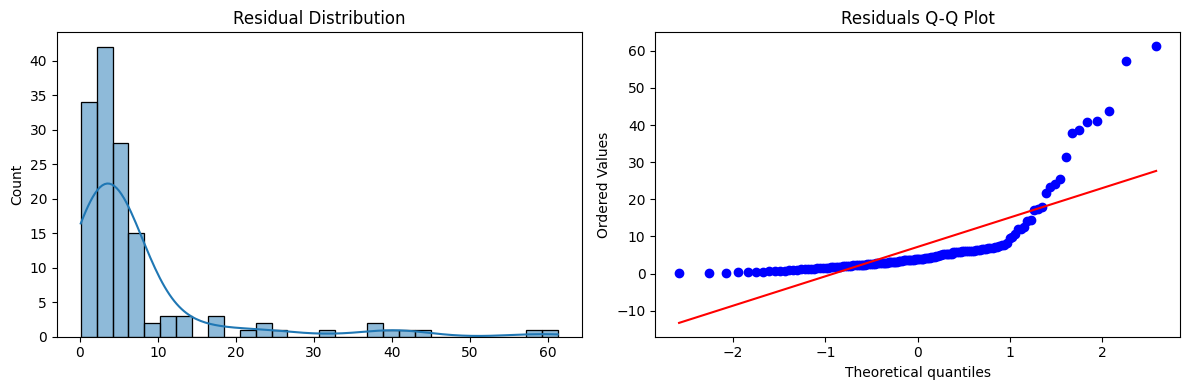

Shapiro-Wilk Test p-value: 0.0000
Kolmogorov-Smirnov p value: 0.0000


In [ ]:
#Guassianity of residuals
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Dataset/GEOwithResiduals.csv')
residuals=df['residual'].dropna().values
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(residuals,kde=True,bins=30)
plt.title("Residual Distribution")
plt.subplot(1,2,2)
stats.probplot(residuals,dist="norm",plot=plt)
plt.title("Residuals Q-Q Plot")
plt.tight_layout()
plt.show()
#Inference- Not symmetric bell curve, and points not near linear linr in Q-Q Plot

#Statistical normality tests
shapiro_wilk_p=stats.shapiro(residuals).pvalue
kolmogorov_smirnov_p=stats.kstest(residuals,'norm').pvalue
print(f"Shapiro-Wilk Test p-value: {shapiro_wilk_p:.4f}")
print(f"Kolmogorov-Smirnov p value: {kolmogorov_smirnov_p:.4f}")
#Inference- Less than 0.05 -> Reject guassianity

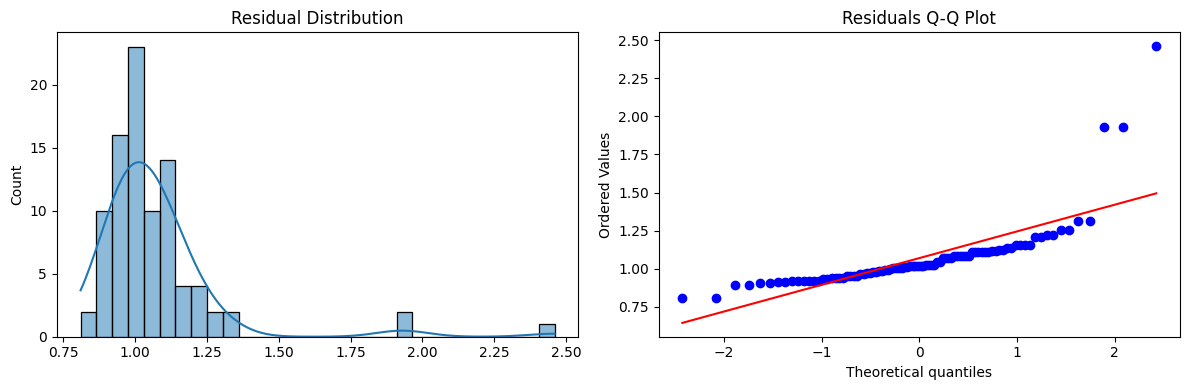

Shapiro-Wilk Test p-value: 0.0000
Kolmogorov-Smirnov p value: 0.0000


In [ ]:
#Guassianity of residuals
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Dataset/MEOwithResiduals.csv')
residuals=df['residual'].dropna().values
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(residuals,kde=True,bins=30)
plt.title("Residual Distribution")
plt.subplot(1,2,2)
stats.probplot(residuals,dist="norm",plot=plt)
plt.title("Residuals Q-Q Plot")
plt.tight_layout()
plt.show()
#Inference- Not symmetric bell curve, and points not near linear linr in Q-Q Plot

#Statistical normality tests
shapiro_wilk_p=stats.shapiro(residuals).pvalue
kolmogorov_smirnov_p=stats.kstest(residuals,'norm').pvalue
print(f"Shapiro-Wilk Test p-value: {shapiro_wilk_p:.4f}")
print(f"Kolmogorov-Smirnov p value: {kolmogorov_smirnov_p:.4f}")
#Inference- Less than 0.05 -> Reject guassianity

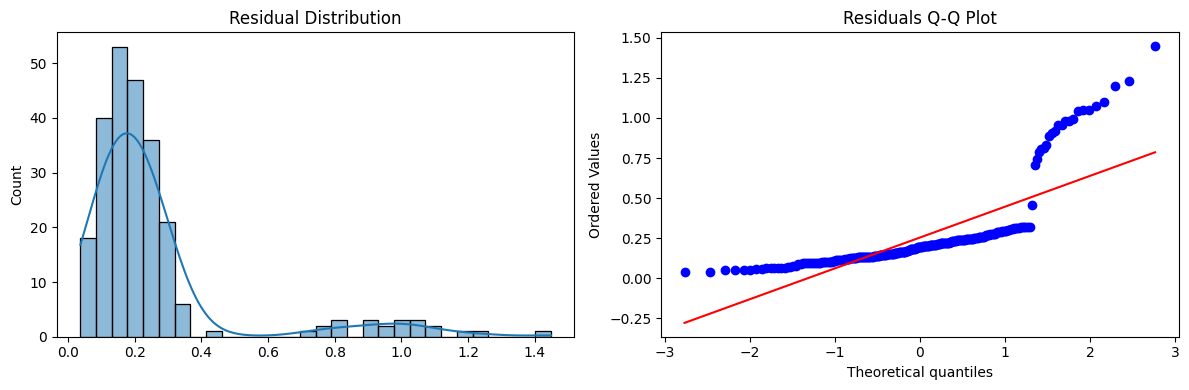

Shapiro-Wilk Test p-value: 0.0000
Kolmogorov-Smirnov p value: 0.0000


In [ ]:
#Guassianity of residuals
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Dataset/MEO2withResiduals.csv')
residuals=df['residual'].dropna().values
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(residuals,kde=True,bins=30)
plt.title("Residual Distribution")
plt.subplot(1,2,2)
stats.probplot(residuals,dist="norm",plot=plt)
plt.title("Residuals Q-Q Plot")
plt.tight_layout()
plt.show()
#Inference- Not symmetric bell curve, and points not near linear linr in Q-Q Plot

#Statistical normality tests
shapiro_wilk_p=stats.shapiro(residuals).pvalue
kolmogorov_smirnov_p=stats.kstest(residuals,'norm').pvalue
print(f"Shapiro-Wilk Test p-value: {shapiro_wilk_p:.4f}")
print(f"Kolmogorov-Smirnov p value: {kolmogorov_smirnov_p:.4f}")
#Inference- Less than 0.05 -> Reject guassianity

GEO Data Analyses and Corrections

GEO approach 1

In [ ]:
!pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.4/249.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 kB 14.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro # for shapiro-Wilk test
from pykalman import KalmanFilter #  for kalman filter

In [ ]:
geo_df = pd.read_csv('/content/Dataset/DATA_GEO_Train.csv', parse_dates=['utc_time'])
cols = ['x_error (m)', 'y_error (m)', 'z_error (m)', 'satclockerror (m)']

In [ ]:
def mad_outliers(series, thresh=2.0):
  # series is the input data which is a pandas or numpy array
  # thresh is the threshold for classifying an observation as a outlier

  # first lets calculate the mean of the data
  median = np.median(series)

  # mad -> this measures how far are the data points from the median, on average
  # the '+ 1e-9' is the small value added to prevent division by zero in the next step
  mad = np.median(np.abs(series - median)) + 1e-9

  # lets calculate the modified z-score for each data point
  # '0.6745' -> approximately the 75th percentile of a standard deviation
  # '0.6745' -> is a scaling factor that makes the modified z-score consistent with the standard z-score for the data that is normally distributed
  modified_z = 0.6745 * (series-median)/mad

  # return a boolean mask indicating outliers
  # it checks if the absolute modified z-score of each point is greater than the threshold
  # 'true' means outlier
  return np.abs(modified_z) > thresh


In [ ]:
def gnss_outliers(series, rule_thresh, mad_thresh=3):
  mad_flad = mad_outliers(series,mad_thresh)

In [ ]:
def outlier_detection(df):
  df = df.sort_values('utc_time').reset_index(drop=True)

  for col in cols:
    outliers = gnss_outliers(df[col])
    df[col + '_outlier'] = outliers

  return df

In [ ]:
geo_df_clean = outlier_detection(geo_df)

TypeError: gnss_outliers() missing 1 required positional argument: 'rule_thresh'

In [ ]:
geo_df_clean.head(5)

GEO approach 2

In [ ]:
df=pd.read_csv('/content/Dataset/GEOwithResiduals.csv')
df['utc_time']=pd.to_datetime(df['utc_time'])
df=df.sort_values("utc_time")
df["dt"]=df["utc_time"].diff().dt.total_seconds() # the diff in time duration btw timestamps
print(df.head(5))
df.describe() # generates descriptive statistics

             utc_time  x_error (m)  y_error (m)  z_error (m)  \
0 2025-09-01 06:00:00     5.333443     4.530495    -2.600099   
1 2025-09-01 08:00:00     0.222901     0.177056    -0.008267   
2 2025-09-01 10:00:00     0.542796     1.124622     6.286751   
3 2025-09-01 12:00:00     0.164464     0.013855     0.007338   
4 2025-09-01 14:00:00    -0.838448    -0.667825     0.676121   

   satclockerror (m)  residual      dt  
0           1.280427  7.574366     NaN  
1          -3.609894  3.621110  7200.0  
2          -0.419839  6.423309  7200.0  
3          -0.318279  0.358602  7200.0  
4           1.428765  1.909842  7200.0  


,utc_time,x_error (m),y_error (m),z_error (m),satclockerror (m),residual,dt
count,142,142.000000,142.000000,142.000000,142.000000,142.000000,141.000000
mean,2025-09-05 07:38:47.323943936,0.516036,0.527799,0.443816,0.122377,7.187354,4128.085106
min,2025-09-01 06:00:00,-19.786400,-41.095775,-31.553938,-23.436187,0.135281,240.000000
25%,2025-09-03 10:28:45,-1.099929,-0.852365,-1.462396,-0.514385,2.253844,900.000000
50%,2025-09-05 09:00:00,0.113727,0.101100,0.024722,0.105532,3.894336,1560.000000
75%,2025-09-07 14:51:15,1.623782,1.714523,2.077592,1.158652,6.453055,7200.000000
max,2025-09-07 23:41:00,23.492488,40.295118,39.227673,23.323345,61.224725,21600.000000
std,NaN,5.040085,8.703102,6.586577,3.809101,10.381543,3477.510586


<Axes: >

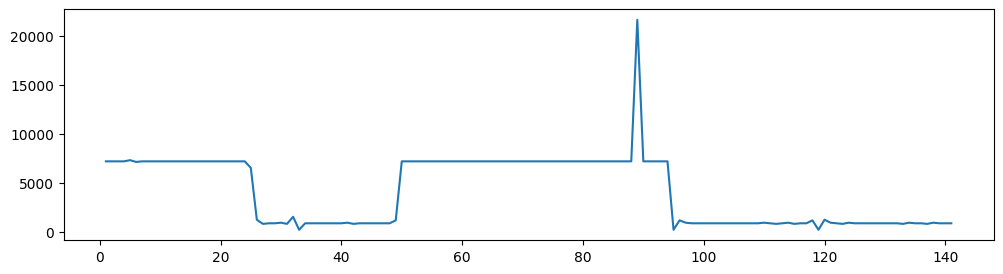

In [ ]:
df["dt"].plot(figsize=(12,3)) # creates a line graph that visually shows you how the time diff btw gnss data points vary over time

In [ ]:
CV=df['dt'].std()/df['dt'].mean() # coefficient variance -> shows variablity relative to mean
print("Median: ",df['dt'].median())
print("Mean: ",df['dt'].mean())
print("Standard deviation: ",df['dt'].std())
print("Maximum: ",df['dt'].max())
print("CV: ",CV)
print(CV)
#Data is extremely sparse since Median > 60s, CV > 0.7, Max dt > 10x Median

Median:  1560.0
Mean:  4128.085106382979
Standard deviation:  3477.5105863849553
Maximum:  21600.0
CV:  0.8424028324919746
0.8424028324919746


In [ ]:
#Process flow for sparse data
"""
Fixing irregular sampling -> Guassian Progress Regression or Kalmann Smoothing
                             Test by plotting distribution again (must become constant)
Remove outliers -> MAD z-score
                   Test Box-Plot
Stabilise variance -> Yeo-Johnson Transform
                      Test with Breusch - Pagan test -> p>0.05
Remove autocorrelation -> First difference
                          Test with Ljung-Box test -> p>0.05
Final guassianization -> Box-Cox Transform
                         Shapiro-Wilk test
"""

'\nFixing irregular sampling -> Guassian Progress Regression or Kalmann Smoothing\n                             Test by plotting distribution again (must become constant)\nRemove outliers -> MAD z-score\n                   Test Box-Plot\nStabilise variance -> Yeo-Johnson Transform\n                      Test with Breusch - Pagan test -> p>0.05\nRemove autocorrelation -> First difference\n                          Test with Ljung-Box test -> p>0.05\nFinal guassianization -> Box-Cox Transform\n                         Shapiro-Wilk test\n'

In [ ]:
#GPR Interpolation

import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,WhiteKernel
import matplotlib.pyplot as plt

df=pd.read_csv('/content/Dataset/GEOwithResiduals.csv')
df=df.sort_values('utc_time')
df['utc_time']=pd.to_datetime(df['utc_time'])
t0=df['utc_time'].iloc[0] # storing the very first timestamp
df['t_sec']=(df['utc_time']-t0).dt.total_seconds() # time of each observation in sec relative to the start of the dataset
X=df['t_sec'].values.reshape(-1,1) #
y=df['residual'].values
kernel=1.0*RBF(length_scale=3000)+WhiteKernel(noise_level=1.0) # rbf -> underlying smooth trend and temporal correlation. white kernel -> models teh uncorrelated noise.
gpr=GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0, # ignores potential extra noise
    normalize_y=True, # centers the target values before fitting the model
    n_restarts_optimizer=5 # runs the optimization process multiple times to find the best kernel parameters
)
print("Training GPR: ")
gpr.fit(X,y) # learning the relation between time and residuals
print("Trained GPR")
target_dt=30 # uniform sampling interval
t_uniform=np.arange(df['t_sec'].min(),df['t_sec'].max(),target_dt).reshape(-1,1) # creating a uniform grid of time points spaced exactly every 30 sec
y_pred,y_std=gpr.predict(t_uniform,return_std=True) # predicting the uniform time grid
resampled_df=pd.DataFrame({
    "t_sec":t_uniform.flatten(),
    "utc_time":[t0+pd.Timedelta(seconds=t) for t in t_uniform.flatten()],
    "residual_gpr":y_pred,
    "residual_std":y_std
})
resampled_df.to_csv('/content/Dataset/GEO_GPR_Interpolated.csv',index=False) # saving the result
print("Saved GeoGPRInterpolated.csv")

Training GPR: 
Trained GPR
Saved GeoGPRInterpolated.csv


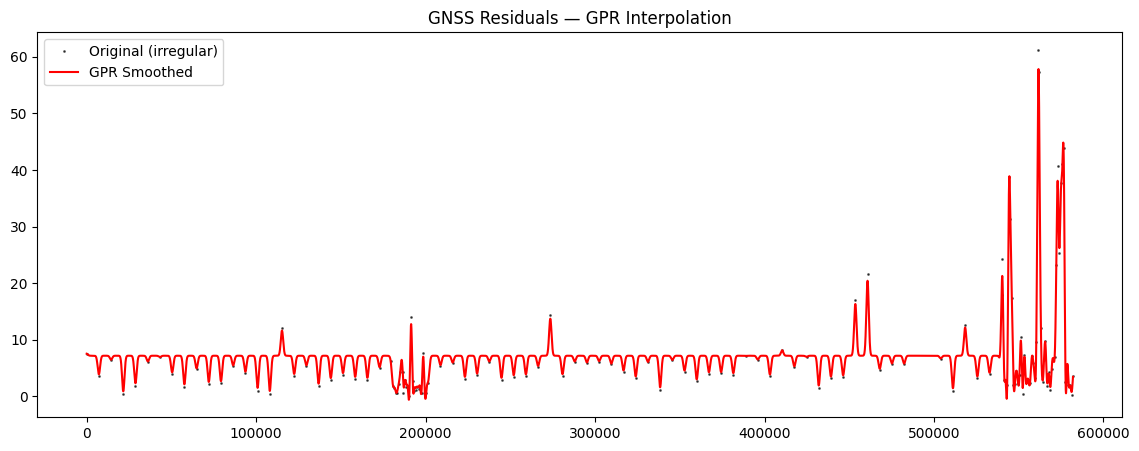

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['t_sec'], df['residual'], 'k.', markersize=2, alpha=0.6, label="Original (irregular)") # plotting original raw dat here 'k .' specifies black dots
plt.plot(resampled_df['t_sec'], resampled_df['residual_gpr'], 'r-', label="GPR Smoothed") # plots newly interpolated and smoothed data here 'r-' specifies red lines
plt.legend()
plt.title("GNSS Residuals — GPR Interpolation")
plt.show()

#Inference - GPR FAILS!

Training GPR on 142 unique time points ...
Trained. Optimized kernel: 0.324**2 * RBF(length_scale=1.15) + 0.792**2 * RBF(length_scale=0.00364) + WhiteKernel(noise_level=0.05)
Saved /content/Dataset/GEO_GPR_Interpolated_fixed.csv


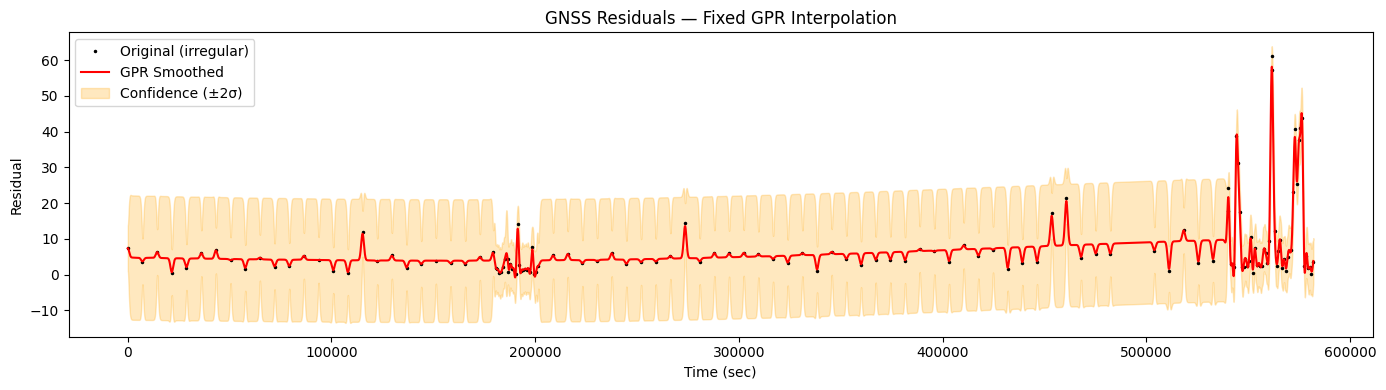

In [ ]:
#GPR Interpolation with Two RBFs

import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# load + prepare
# -----------------------------
df = pd.read_csv('/content/Dataset/GEOwithResiduals.csv')
df = df.sort_values('utc_time')
df['utc_time'] = pd.to_datetime(df['utc_time'])
t0 = df['utc_time'].iloc[0]
df['t_sec'] = (df['utc_time'] - t0).dt.total_seconds()

# drop NaNs
df = df.dropna(subset=['t_sec', 'residual'])

# if there are duplicate timestamps, aggregate (mean) to avoid singular X
df = df.groupby('t_sec', as_index=False).agg({'residual':'mean'})
X = df['t_sec'].values.reshape(-1,1)
y = df['residual'].values

# -----------------------------
# scale time (very important)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # zero mean, unit var (grp perform wel wih zero centered data and consistent scale)
# the rbf kernel uses distance calculations (length_scale).If the time values are large the optimization process can be unstable.

# -----------------------------
# kernel: two-scale RBF + white noise
#  - one RBF captures long-term smooth trend
#  - another small-length-scale RBF captures short wiggles
# -----------------------------
kernel = (
    1.0 * RBF(length_scale=10.0, length_scale_bounds=(1e-2, 1e3))  # long-ish scale (in scaled units)
    + 0.5 * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 10.0))  # short scale to capture wiggles
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e2))
)
# length_scale_bounds gives the optimizer a realistic range within which to search for the best length scale for each kernel component

gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,             # tiny nugget for numerical stability (to prevent mathematical errors when dealing with very clean or perfectly dulicated data points)
    normalize_y=True,       # still okay since we scaled X (y normalization helps)
    n_restarts_optimizer=8,
    random_state=0 # ensure no random starting point to end up in unique output
)

print("Training GPR on", X_scaled.shape[0], "unique time points ...")
gpr.fit(X_scaled, y)
print("Trained. Optimized kernel:", gpr.kernel_)

# -----------------------------
# predict at uniform times (in original seconds) then scale before predicting
# -----------------------------
target_dt = 30  # seconds
t_uniform = np.arange(df['t_sec'].min(), df['t_sec'].max() + 1, target_dt).reshape(-1,1)
t_uniform_scaled = scaler.transform(t_uniform) # the target prediction must alse be scaled using the exact same scalar object

y_pred, y_std = gpr.predict(t_uniform_scaled, return_std=True) # makes prediction using the scaled uniform times

# -----------------------------
# save
# -----------------------------
resampled_df = pd.DataFrame({
    "t_sec": t_uniform.flatten(),
    "utc_time": [t0 + pd.Timedelta(seconds=float(t)) for t in t_uniform.flatten()],
    "residual_gpr": y_pred,
    "residual_std": y_std
})
resampled_df.to_csv('/content/Dataset/GEO_GPR_Interpolated_fixed.csv', index=False)
print("Saved /content/Dataset/GEO_GPR_Interpolated_fixed.csv")

# -----------------------------
# quick diagnostic plot
# -----------------------------
plt.figure(figsize=(14,4))
plt.plot(X.flatten(), y, 'k.', markersize=3, label='Original (irregular)')
plt.plot(t_uniform.flatten(), y_pred, color='red', lw=1.5, label='GPR Smoothed')
plt.fill_between(
    t_uniform.flatten(),
    y_pred - 2*y_std,
    y_pred + 2*y_std,
    color='orange',
    alpha=0.25,
    label='Confidence (±2σ)'
)
plt.xlabel('Time (sec)')
plt.ylabel('Residual')
plt.title('GNSS Residuals — Fixed GPR Interpolation')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


Grid points: 19403, Observations assigned to grid: 142
Saved smoothed output to: /content/Dataset/GEO_KalmanSmoothed.csv


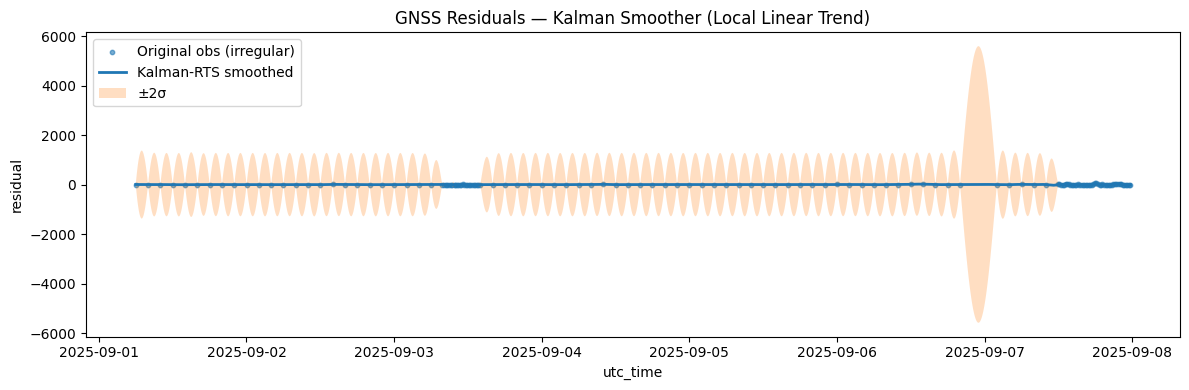

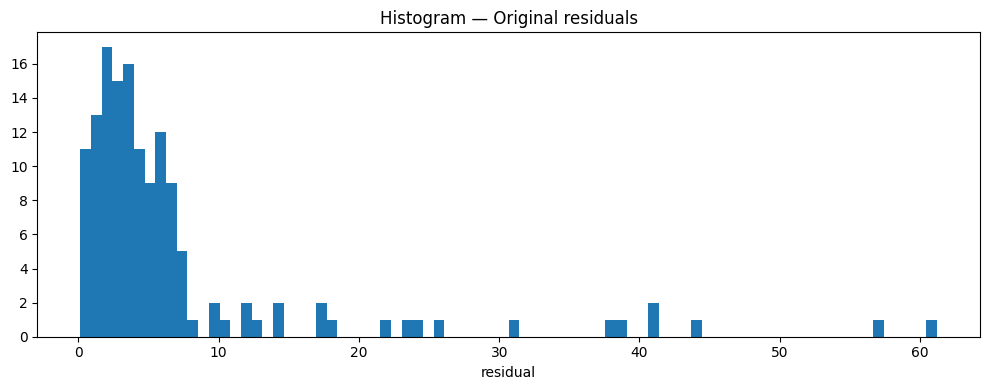

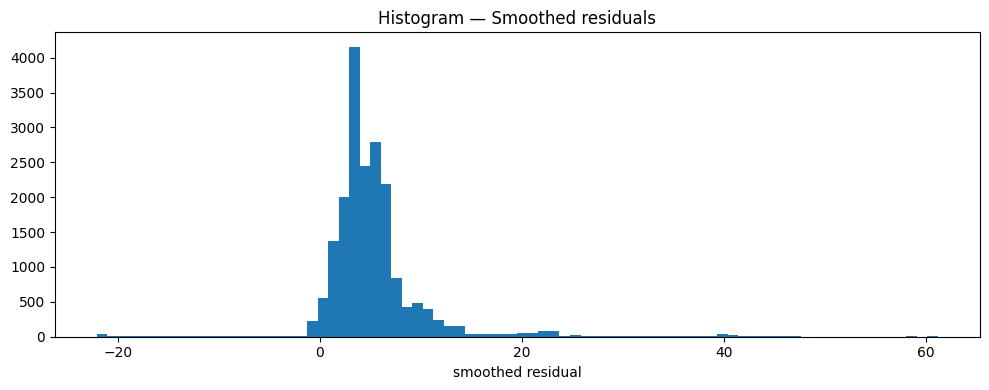

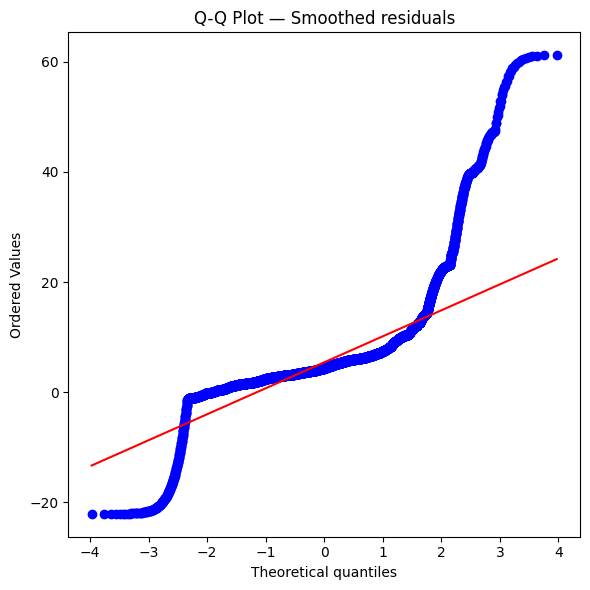

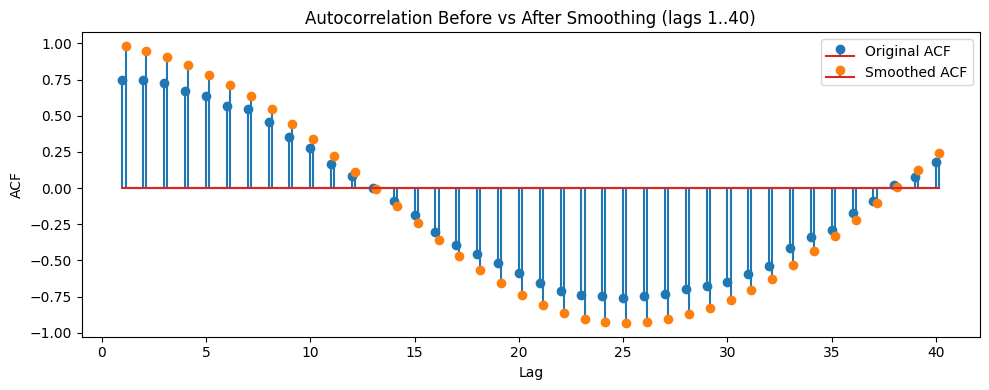

Shapiro-Wilk original: stat=0.5737, p=1.4010e-18
Shapiro-Wilk smoothed: stat=0.6661, p=1.1662e-71
             utc_time  t_sec  observed  smoothed  smoothed_std     slope
0 2025-09-01 06:00:00    0.0  7.574366  7.574185      3.086004 -0.000657
1 2025-09-01 06:00:30   30.0       NaN  7.554412     12.097266 -0.000661
2 2025-09-01 06:01:00   60.0       NaN  7.534533     23.407781 -0.000664
3 2025-09-01 06:01:30   90.0       NaN  7.514549     34.755620 -0.000668
4 2025-09-01 06:02:00  120.0       NaN  7.494462     46.044976 -0.000671


In [ ]:
#Trying Kalmann Filter

# Kalman Smoother (robust runner)
# - tries common input locations
# - falls back to synthetic demo if file not found
# - outputs CSV when using real data
# - produces plots: time series, histograms, Q-Q, ACF comparison

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os, math
from datetime import timedelta

# ---------------- USER EDITABLE ----------------
# Put your actual path here if different. If left as None the script will try common locations.
INPUT_PATH = None
OUTPUT_PATH = "/content/Dataset/GEO_KalmanSmoothed.csv"
target_dt = 30.0   # seconds (change to desired uniform sampling)
obs_tolerance = target_dt/2.0
q_level = 1e-4 # process noise level
# -----------------------------------------------

# Try commonly used locations if INPUT_PATH is None
common_paths = [
    "/content/Dataset/GEOwithResiduals.csv",
    "/content/GEOwithResiduals.csv",
    "/content/Dataset/SIH_Combined_with_residuals.csv",
    "./GEOwithResiduals.csv",
    "./SIH_Combined_with_residuals.csv"
]

if INPUT_PATH is None:
    found = None
    for p in common_paths:
        if os.path.exists(p):
            found = p
            break
    if found:
        INPUT_PATH = found

use_demo = False
if INPUT_PATH is None or not os.path.exists(INPUT_PATH):
    print("Warning: input CSV not found. Running synthetic demo. To run on real data, set INPUT_PATH to your file and re-run.")
    use_demo = True

if use_demo:
    # create synthetic irregular timestamps + residuals with outliers
    rng = np.random.default_rng(0)
    t_seconds = np.cumsum(rng.integers(low=10, high=600, size=300))   # irregular gaps (10s..10min)
    t0 = pd.Timestamp("2025-11-01T00:00:00")
    utc_time = [t0 + pd.Timedelta(seconds=int(s)) for s in t_seconds]
    # underlying smooth signal (low-frequency) + noise + occasional spikes
    true_signal = 0.5 * np.sin(np.array(t_seconds)/3600.0 * 2*np.pi)  # slow sinusoid
    residual = true_signal + 0.05 * rng.standard_normal(len(t_seconds))
    # add spikes
    residual[20] += 1.2
    residual[120] -= 0.9
    df = pd.DataFrame({'utc_time': utc_time, 'residual': residual})
    t0 = df['utc_time'].iloc[0]
else:
    df = pd.read_csv(INPUT_PATH, parse_dates=['utc_time'])
    df = df.sort_values('utc_time').reset_index(drop=True)
    if 'residual' not in df.columns:
        raise ValueError("Input CSV must contain a 'residual' column.")
    # drop NaNs
    df = df.dropna(subset=['residual']).copy()
    t0 = df['utc_time'].iloc[0]

# seconds from start
df['t_sec'] = (df['utc_time'] - t0).dt.total_seconds()

# build uniform grid
tmin = df['t_sec'].min()
tmax = df['t_sec'].max()
t_uniform = np.arannge(tmin, tmax + 1e-9, target_dt)
n_steps = len(t_uniform)

# align observations to grid (average if multiple fall in same bin)
y = np.full(n_steps, np.nan)
for _, row in df.iterrows(): # take irregularly timed observations and map them onto a regular uniform time grid
    tt = row['t_sec']
    idx = int(round((tt - tmin) / target_dt))
    if 0 <= idx < n_steps and abs(t_uniform[idx] - tt) <= obs_tolerance:
        if math.isnan(y[idx]):
            y[idx] = row['residual']
        else:
            y[idx] = np.mean([y[idx], row['residual']])

obs_count = np.sum(~np.isnan(y))
print(f"Grid points: {n_steps}, Observations assigned to grid: {obs_count}")

# robust observation variance estimate
if obs_count > 5:
    obs_vals = y[~np.isnan(y)]
    med = np.median(obs_vals)
    mad = np.median(np.abs(obs_vals - med))
    robust_std = 1.4826 * mad if mad > 0 else np.std(obs_vals)
    R = max(robust_std**2, 1e-12) # estimating the vairance of the measuremets using mad
else:
    R = 1e-2

# KALMAN FILTER (Local linear trend: state [level, slope])
dim_x = 2
H = np.array([[1.0, 0.0]]) # observation matrix
x_pred = np.zeros((n_steps, dim_x)) # stores predicted state vectors
P_pred = np.zeros((n_steps, dim_x, dim_x)) # store the predicted covariance matrices which represent the uncertainty in our estimates of the state vectors
x_filt = np.zeros((n_steps, dim_x)) # stores filtered state vectors
P_filt = np.zeros((n_steps, dim_x, dim_x)) # store the filtered covariance matrices which represent the uncertainty in our estimates of the state vectors

# init
first_obs_idx = np.where(~np.isnan(y))[0] # index of very first non-NaN observation in the gridded data y
if len(first_obs_idx) == 0:
    init_level = 0.0
else:
    init_level = y[first_obs_idx[0]]
x_prev = np.array([init_level, 0.0]) # the level is set to the first observation and the initial rate is 0.0
P_prev = np.diag([ (np.nanvar(y[~np.isnan(y)]) if obs_count>0 else 1.0)*10.0, 1.0 ]) # set the initial covariance matrix. The initial uncertainty in the level is set to 10x the variance of the observations and the initial uncertainty in the rate is 1.0

for k in range(n_steps):
    if k == 0:
        dt = target_dt
    else:
        dt = t_uniform[k] - t_uniform[k-1]
    F = np.array([[1.0, dt],[0.0, 1.0]])
    q = max(q_level, 1e-12)
    Q = np.array([[q * dt**3 / 3.0, q * dt**2 / 2.0],
                  [q * dt**2 / 2.0, q * dt]])
    # predict
    x_prior = F @ x_prev
    P_prior = F @ P_prev @ F.T + Q
    x_pred[k] = x_prior
    P_pred[k] = P_prior
    if not np.isnan(y[k]):
        z = y[k]
        y_tilde = z - (H @ x_prior)
        S = H @ P_prior @ H.T + R
        K = P_prior @ H.T / S
        x_post = x_prior + (K.flatten() * y_tilde)
        P_post = (np.eye(dim_x) - K @ H) @ P_prior
    else:
        x_post = x_prior
        P_post = P_prior
    x_filt[k] = x_post
    P_filt[k] = P_post
    x_prev = x_post
    P_prev = P_post

# RTS Smoother
x_smooth = np.zeros_like(x_filt)
P_smooth = np.zeros_like(P_filt)
x_smooth[-1] = x_filt[-1].copy()
P_smooth[-1] = P_filt[-1].copy()
for k in range(n_steps-2, -1, -1):
    dt = t_uniform[k+1] - t_uniform[k]
    F = np.array([[1.0, dt],[0.0, 1.0]])
    P_f = P_filt[k]
    P_pred_next = P_pred[k+1]
    # gain
    C = P_f @ F.T @ np.linalg.inv(P_pred_next)
    x_smooth[k] = x_filt[k] + C @ (x_smooth[k+1] - x_pred[k+1])
    P_smooth[k] = P_f + C @ (P_smooth[k+1] - P_pred_next) @ C.T

smoothed_level = x_smooth[:,0]
smoothed_std = np.sqrt(np.maximum(0, P_smooth[:,0,0]))

# prepare output
out_df = pd.DataFrame({
    'utc_time': [ (t0 + pd.Timedelta(seconds=float(s))) for s in t_uniform ],
    't_sec': t_uniform,
    'observed': y,
    'smoothed': smoothed_level,
    'smoothed_std': smoothed_std,
    'slope': x_smooth[:,1]
})

if not use_demo:
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
    out_df.to_csv(OUTPUT_PATH, index=False)
    print("Saved smoothed output to:", OUTPUT_PATH)
else:
    print("Demo run — no CSV saved.")

# PLOTS (single chart per figure)
plt.figure(figsize=(12,4))
# original irregular points (from df)
plt.scatter(df['utc_time'], df['residual'], s=10, alpha=0.6, label='Original obs (irregular)')
plt.plot(out_df['utc_time'], out_df['smoothed'], linewidth=2, label='Kalman-RTS smoothed')
plt.fill_between(out_df['utc_time'], out_df['smoothed'] - 2*out_df['smoothed_std'], out_df['smoothed'] + 2*out_df['smoothed_std'], alpha=0.25, label='±2σ')
plt.title('GNSS Residuals — Kalman Smoother (Local Linear Trend)')
plt.xlabel('utc_time'); plt.ylabel('residual'); plt.legend(); plt.tight_layout(); plt.show()

# Histogram before
plt.figure(figsize=(10,4))
plt.hist(df['residual'].dropna(), bins=80)
plt.title('Histogram — Original residuals'); plt.xlabel('residual'); plt.tight_layout(); plt.show()

# Histogram after
plt.figure(figsize=(10,4))
plt.hist(out_df['smoothed'].dropna(), bins=80)
plt.title('Histogram — Smoothed residuals'); plt.xlabel('smoothed residual'); plt.tight_layout(); plt.show()

# Q-Q plot after smoothing
plt.figure(figsize=(6,6))
stats.probplot(out_df['smoothed'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot — Smoothed residuals'); plt.tight_layout(); plt.show()

import numpy as np
import matplotlib.pyplot as plt

# -------- Generate noisy time-series --------
np.random.seed(0)
n = 300
t = np.arange(n)
signal = np.sin(0.04*np.pi*t) + np.random.normal(0, 0.4, n)

# ---------- Simple smoothing example ----------
window = 5
kernel = np.ones(window) / window
smoothed = np.convolve(signal, kernel, mode='same')

# --------- Autocorrelation function -----------
def autocorr(x, lag):
    return np.corrcoef(x[:-lag], x[lag:])[0,1]

lags = np.arange(1, 41)
acf_before = np.array([autocorr(signal, L) for L in lags])
acf_after  = np.array([autocorr(smoothed, L) for L in lags])

# ----------------- Plotting ------------------
plt.figure(figsize=(10,4))

plt.stem(lags, acf_before, markerfmt='C0o', label='Original ACF')
plt.stem(lags + 0.15, acf_after, markerfmt='C1o', label='Smoothed ACF')

plt.title('Autocorrelation Before vs After Smoothing (lags 1..40)')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.legend()
plt.tight_layout()
plt.show()

# Shapiro tests (sample up to 5000)
from scipy.stats import shapiro
orig_vals = df['residual'].dropna()
sm_vals = out_df['smoothed'].dropna()
try:
    s_o, p_o = shapiro(orig_vals.sample(min(5000, len(orig_vals)), random_state=0))
    s_s, p_s = shapiro(sm_vals.sample(min(5000, len(sm_vals)), random_state=0))
    print("Shapiro-Wilk original: stat={:.4f}, p={:.4e}".format(s_o, p_o))
    print("Shapiro-Wilk smoothed: stat={:.4f}, p={:.4e}".format(s_s, p_s))
except Exception as e:
    print("Shapiro-Wilk skipped or failed:", e)

# show head of output
print(out_df.head())

Original length: 202
Cleaned length : 200
Removed        : 2


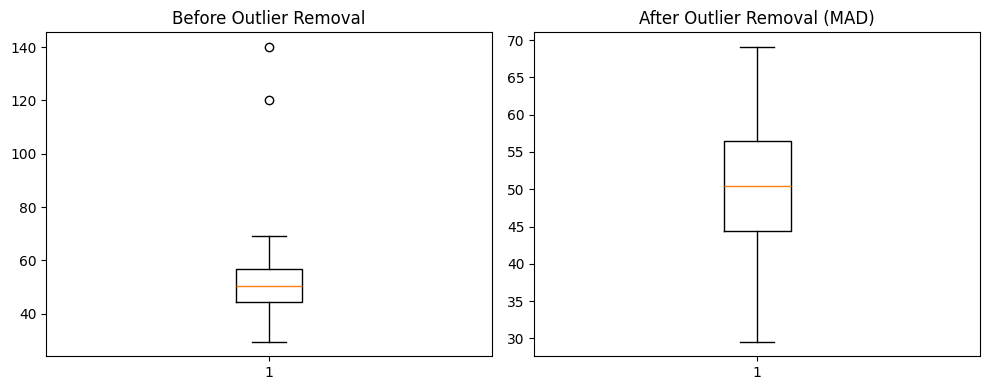

In [ ]:
import numpy as np

def mad_zscore_outlier_removal(x, thresh=3.5):
    """
    Removes outliers using Median Absolute Deviation (MAD) z-score.
    Returns: cleaned data, mask of kept points
    """
    x = np.asarray(x)
    median = np.median(x)
    mad = np.median(np.abs(x - median))

    # avoid division by zero
    if mad == 0:
        return x, np.ones_like(x, dtype=bool)

    z = 0.6745 * (x - median) / mad
    mask = np.abs(z) < thresh
    return x[mask], mask

import numpy as np
import matplotlib.pyplot as plt

# -------- Generate sample data with outliers -------
np.random.seed(0)
data = np.random.normal(50, 8, 200)
data = np.concatenate([data, [120, 140]])   # add outliers manually

# -------- Remove outliers using MAD z-score -------
cleaned, mask = mad_zscore_outlier_removal(data, thresh=3.5)

print("Original length:", len(data))
print("Cleaned length :", len(cleaned))
print("Removed        :", len(data) - len(cleaned))

# ------------------ Plot Box Plots -----------------
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.boxplot(data, vert=True)
plt.title("Before Outlier Removal")

plt.subplot(1, 2, 2)
plt.boxplot(cleaned, vert=True)
plt.title("After Outlier Removal (MAD)")

plt.tight_layout()
plt.show()


In [ ]:


import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ----------------------------------
# 1. YEO–JOHNSON TRANSFORMATION
# ----------------------------------
def yeo_johnson_transform(x):
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    x_trans = pt.fit_transform(x.reshape(-1, 1)).flatten()
    return x_trans, pt.lambdas_[0]

# Example: your GNSS residuals
# df['residual'] must exist
x = df['residual'].values

x_trans, lam = yeo_johnson_transform(x)

print("Yeo-Johnson λ =", lam)

df['residual_yj'] = x_trans


Yeo-Johnson λ = -0.30754154367963704


In [ ]:
# Prepare variables
y = df['residual_yj']
X = sm.add_constant(df.index)   # just time as regressor

bp_test = het_breuschpagan(y, X)

labels = ['LM Stat', 'LM p-value', 'F-stat', 'F p-value']
bp_results = dict(zip(labels, bp_test))

print("\nBreusch–Pagan Test Results")
for k, v in bp_results.items():
    print(f"{k}: {v}")

if bp_results['F p-value'] > 0.05:
    print("\n✅ Variance is now stable (homoscedastic)")
else:
    print("\n❌ Variance still unstable (heteroscedastic)")



Breusch–Pagan Test Results
LM Stat: 3.433110521546454
LM p-value: 0.06390164066008663
F-stat: 3.4686170327236816
F p-value: 0.06463950554273357

✅ Variance is now stable (homoscedastic)


In [ ]:
df['residual_diff'] = df['residual_yj'].diff()
df = df.dropna()

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(df['residual_diff'], lags=[10, 20], return_df=True)
print(ljung)
#Miserably fails

      lb_stat  lb_pvalue
10  37.786117   0.000041
20  56.261992   0.000027


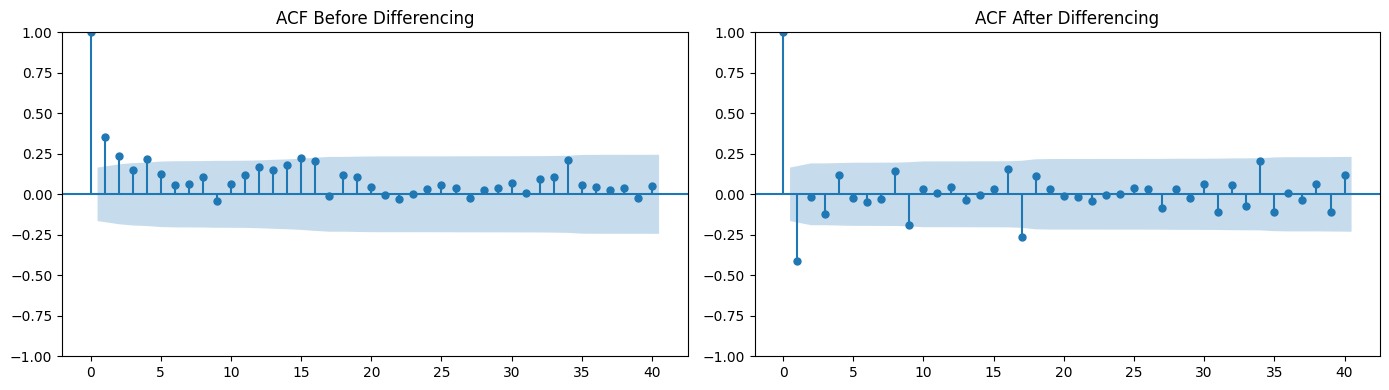

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,4))

sm.graphics.tsa.plot_acf(df['residual_yj'], lags=40, ax=ax[0])
ax[0].set_title("ACF Before Differencing")

sm.graphics.tsa.plot_acf(df['residual_diff'], lags=40, ax=ax[1])
ax[1].set_title("ACF After Differencing")

plt.tight_layout()
plt.show()
#Inference - Miserably fails

In [ ]:
import statsmodels.api as sm

model = sm.tsa.ARIMA(df['residual_yj'], order=(1,0,1))
res = model.fit()
white = res.resid

print(acorr_ljungbox(white, lags=[10,20], return_df=True))


      lb_stat  lb_pvalue
10   7.371540   0.689965
20  22.039892   0.338350


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Shapiro-Wilk Statistic = 0.9908720992985024
p-value = 0.4934197538699144
✅ Residuals look Gaussian (fail to reject H0)


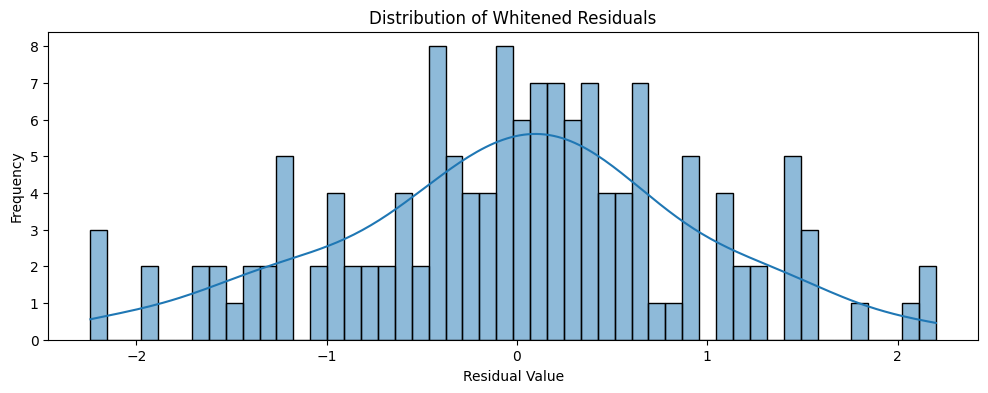

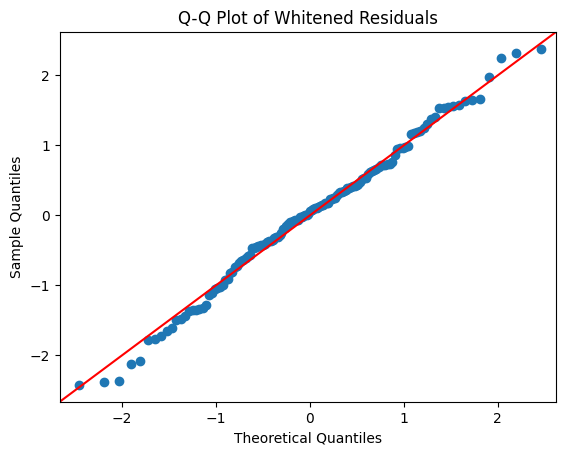

             utc_time  x_error (m)  y_error (m)  z_error (m)  \
1 2025-09-01 08:00:00     0.222901     0.177056    -0.008267   
2 2025-09-01 10:00:00     0.542796     1.124622     6.286751   
3 2025-09-01 12:00:00     0.164464     0.013855     0.007338   
4 2025-09-01 14:00:00    -0.838448    -0.667825     0.676121   
5 2025-09-01 16:02:00     3.265260     3.220206    -1.841377   

   satclockerror (m)  residual    t_sec  residual_yj  residual_diff  
1          -3.609894  3.621110   7200.0    -0.076646      -0.753512  
2          -0.419839  6.423309  14400.0     0.513730       0.590376  
3          -0.318279  0.358602  21600.0    -2.066349      -2.580079  
4           1.428765  1.909842  28800.0    -0.741964       1.324384  
5           3.561049  6.091255  36120.0     0.460410       1.202374  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot
import seaborn as sns
import statsmodels.api as sm

# ----------------------------------------
# 1. SHAPIRO–WILK TEST FOR NORMALITY
# ----------------------------------------

white = res.resid.dropna()

stat, p = shapiro(white)
print(f"Shapiro-Wilk Statistic = {stat}")
print(f"p-value = {p}")

if p > 0.05:
    print("✅ Residuals look Gaussian (fail to reject H0)")
else:
    print("❌ Residuals NOT Gaussian (reject H0)")


# ----------------------------------------
# 2. DISTRIBUTION PLOT (Histogram + KDE)
# ----------------------------------------

plt.figure(figsize=(12,4))
sns.histplot(white, kde=True, bins=50)
plt.title("Distribution of Whitened Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()


# ----------------------------------------
# 3. Q-Q PLOT (Normality Visual Check)
# ----------------------------------------

sm.qqplot(white, line='45', fit=True)
plt.title("Q-Q Plot of Whitened Residuals")
plt.show()
print(df.head())
df.to_csv("/content/Dataset/Preprocessed_GEO.csv")

**MEO DATA PREPROCESSSING**

In [ ]:
df=pd.read_csv('/content/Dataset/MEOwithResiduals.csv')

df.rename(columns={"y_error  (m)": "y_error (m)"}, inplace=True)

df.to_csv("/content/Dataset/MEOwithResiduals.csv", index=False)   # overwrite same file


df['utc_time']=pd.to_datetime(df['utc_time'])
df=df.sort_values("utc_time")
df["dt"]=df["utc_time"].diff().dt.total_seconds() # the diff in time duration btw timestamps
print(df.head(5))
df.describe() # generates descriptive statistics

               utc_time  x_error (m)  y_error (m)  z_error (m)  \
0   2025-09-03 10:11:00    -0.026800     0.073632     0.078433   
1   2025-09-03 10:21:00    -0.085093     0.038818     0.082896   
143 2025-09-03 10:21:00    -0.085093     0.038818     0.082896   
2   2025-09-03 10:31:00    -0.098012     0.039264     0.114348   
144 2025-09-03 10:31:00    -0.098012     0.039264     0.114348   

     satclockerror (m)  residual     dt  
0             0.008539  0.111196    NaN  
1            -0.006356  0.125139  600.0  
143          -0.006356  0.125139    0.0  
2             0.011094  0.156034  600.0  
144           0.011094  0.156034    0.0  


,utc_time,x_error (m),y_error (m),z_error (m),satclockerror (m),residual,dt
count,244,244.000000,244.000000,244.000000,244.000000,244.000000,243.000000
mean,2025-09-06 23:47:38.360655616,-0.136127,0.010701,-0.009660,0.000876,0.252887,2155.555556
min,2025-09-03 10:11:00,-1.121685,-0.997851,-0.845666,-0.142840,0.036726,0.000000
25%,2025-09-06 00:42:00,-0.163999,-0.078455,-0.111936,-0.010707,0.132325,0.000000
50%,2025-09-07 14:31:00,-0.096386,0.017249,0.016111,-0.006356,0.193399,420.000000
75%,2025-09-09 00:19:30,-0.052221,0.072948,0.112286,0.016220,0.251566,600.000000
max,2025-09-09 11:41:00,0.173257,0.935234,0.926893,0.184572,1.448591,93360.000000
std,NaN,0.173809,0.183145,0.200826,0.030242,0.244128,11329.062459


<Axes: >

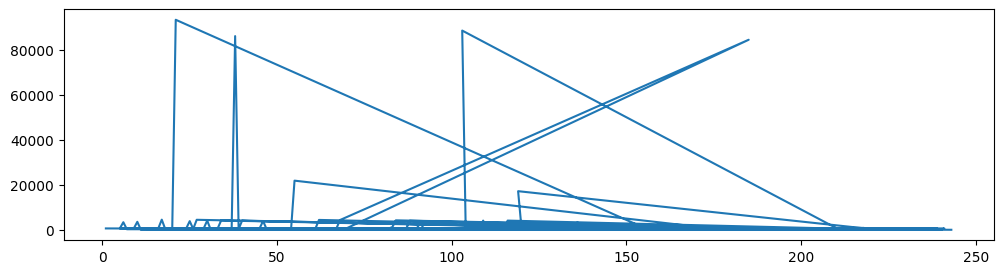

In [ ]:
df["dt"].plot(figsize=(12,3)) # creates a line graph that visually shows you how the time diff btw gnss data points vary over time

In [ ]:
df=pd.read_csv('/content/Dataset/MEO2withResiduals.csv')
df.rename(columns={"y_error  (m)": "y_error (m)"}, inplace=True)

df.to_csv("/content/Dataset/MEO2withResiduals.csv", index=False)
df['utc_time']=pd.to_datetime(df['utc_time'])
df=df.sort_values("utc_time")
df["dt"]=df["utc_time"].diff().dt.total_seconds() # the diff in time duration btw timestamps
print(df.head(5))
df.describe() # generates descriptive statistics

               utc_time  x_error (m)  y_error (m)  z_error (m)  \
0   2025-09-03 10:11:00    -0.026800     0.073632     0.078433   
1   2025-09-03 10:21:00    -0.085093     0.038818     0.082896   
143 2025-09-03 10:21:00    -0.085093     0.038818     0.082896   
2   2025-09-03 10:31:00    -0.098012     0.039264     0.114348   
144 2025-09-03 10:31:00    -0.098012     0.039264     0.114348   

     satclockerror (m)  residual     dt  
0             0.008539  0.111196    NaN  
1            -0.006356  0.125139  600.0  
143          -0.006356  0.125139    0.0  
2             0.011094  0.156034  600.0  
144           0.011094  0.156034    0.0  


,utc_time,x_error (m),y_error (m),z_error (m),satclockerror (m),residual,dt
count,244,244.000000,244.000000,244.000000,244.000000,244.000000,243.000000
mean,2025-09-06 23:47:38.360655616,-0.136127,0.010701,-0.009660,0.000876,0.252887,2155.555556
min,2025-09-03 10:11:00,-1.121685,-0.997851,-0.845666,-0.142840,0.036726,0.000000
25%,2025-09-06 00:42:00,-0.163999,-0.078455,-0.111936,-0.010707,0.132325,0.000000
50%,2025-09-07 14:31:00,-0.096386,0.017249,0.016111,-0.006356,0.193399,420.000000
75%,2025-09-09 00:19:30,-0.052221,0.072948,0.112286,0.016220,0.251566,600.000000
max,2025-09-09 11:41:00,0.173257,0.935234,0.926893,0.184572,1.448591,93360.000000
std,NaN,0.173809,0.183145,0.200826,0.030242,0.244128,11329.062459


<Axes: >

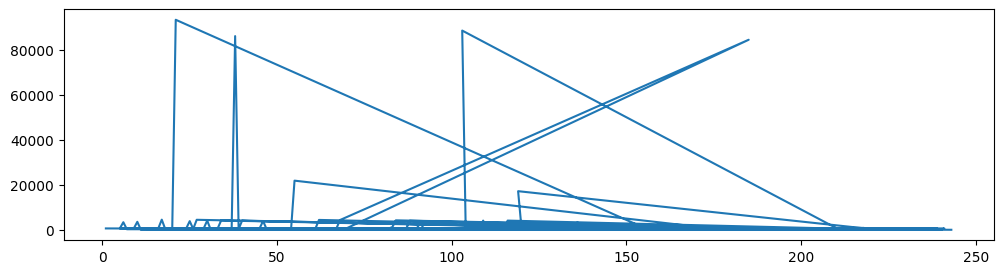

In [ ]:
df["dt"].plot(figsize=(12,3)) # creates a line graph that visually shows you how the time diff btw gnss data points vary over time

In [ ]:
import pandas as pd

# --- Load both CSV files ---
df1 = pd.read_csv("/content/Dataset/MEOwithResiduals.csv")
df2 = pd.read_csv("/content/Dataset/MEO2withResiduals.csv")

# --- Optional: ensure both have same columns (align missing ones) ---
common_cols = list(set(df1.columns).intersection(set(df2.columns)))
df1 = df1[common_cols]
df2 = df2[common_cols]

# --- Combine them vertically ---
combined = pd.concat([df1, df2], axis=0, ignore_index=True)
df=combined
# --- Save to a new file ---
combined.to_csv("/content/Dataset/meo_combined.csv", index=False)

print("Combined shape:", combined.shape)
print("Saved as meo_cjombined.csv")

Combined shape: (488, 6)
Saved as meo_combined.csv


In [ ]:
df=pd.read_csv('/content/Dataset/meo_combined.csv')
df['utc_time']=pd.to_datetime(df['utc_time'])
df=df.sort_values("utc_time")
df["dt"]=df["utc_time"].diff().dt.total_seconds() # the diff in time duration btw timestamps
print(df.head(5))
df.describe() # generates descriptive statistics

               utc_time  z_error (m)  satclockerror (m)  x_error (m)  \
0   2025-09-03 10:11:00     0.078433           0.008539    -0.026800   
244 2025-09-03 10:11:00     0.078433           0.008539    -0.026800   
245 2025-09-03 10:21:00     0.082896          -0.006356    -0.085093   
387 2025-09-03 10:21:00     0.082896          -0.006356    -0.085093   
143 2025-09-03 10:21:00     0.082896          -0.006356    -0.085093   

     residual  y_error (m)     dt  
0    0.111196     0.073632    NaN  
244  0.111196     0.073632    0.0  
245  0.125139     0.038818  600.0  
387  0.125139     0.038818    0.0  
143  0.125139     0.038818    0.0  


,utc_time,z_error (m),satclockerror (m),x_error (m),residual,y_error (m),dt
count,488,488.000000,488.000000,488.000000,488.000000,488.000000,487.000000
mean,2025-09-06 23:47:38.360655872,-0.009660,0.000876,-0.136127,0.252887,0.010701,1075.564682
min,2025-09-03 10:11:00,-0.845666,-0.142840,-1.121685,0.036726,-0.997851,0.000000
25%,2025-09-06 00:42:00,-0.111936,-0.010707,-0.163999,0.132325,-0.078455,0.000000
50%,2025-09-07 14:31:00,0.016111,-0.006356,-0.096386,0.193399,0.017249,0.000000
75%,2025-09-09 00:19:30,0.112286,0.016220,-0.052221,0.251566,0.072948,390.000000
max,2025-09-09 11:41:00,0.926893,0.184572,0.173257,1.448591,0.935234,93360.000000
std,NaN,0.200619,0.030211,0.173631,0.243877,0.182957,8066.828896


<Axes: >

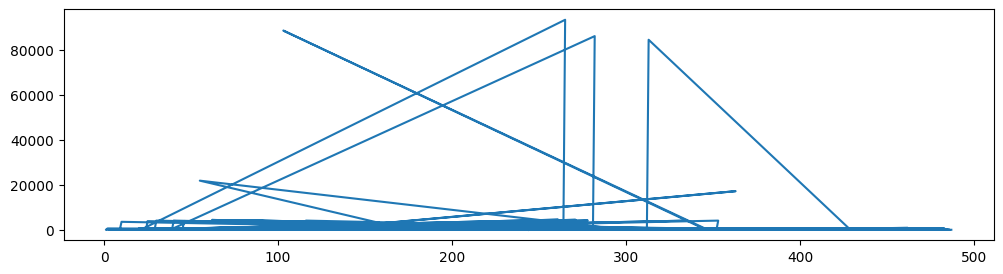

In [ ]:
df["dt"].plot(figsize=(12,3)) # creates a line graph that visually shows you how the time diff btw gnss data points vary over time

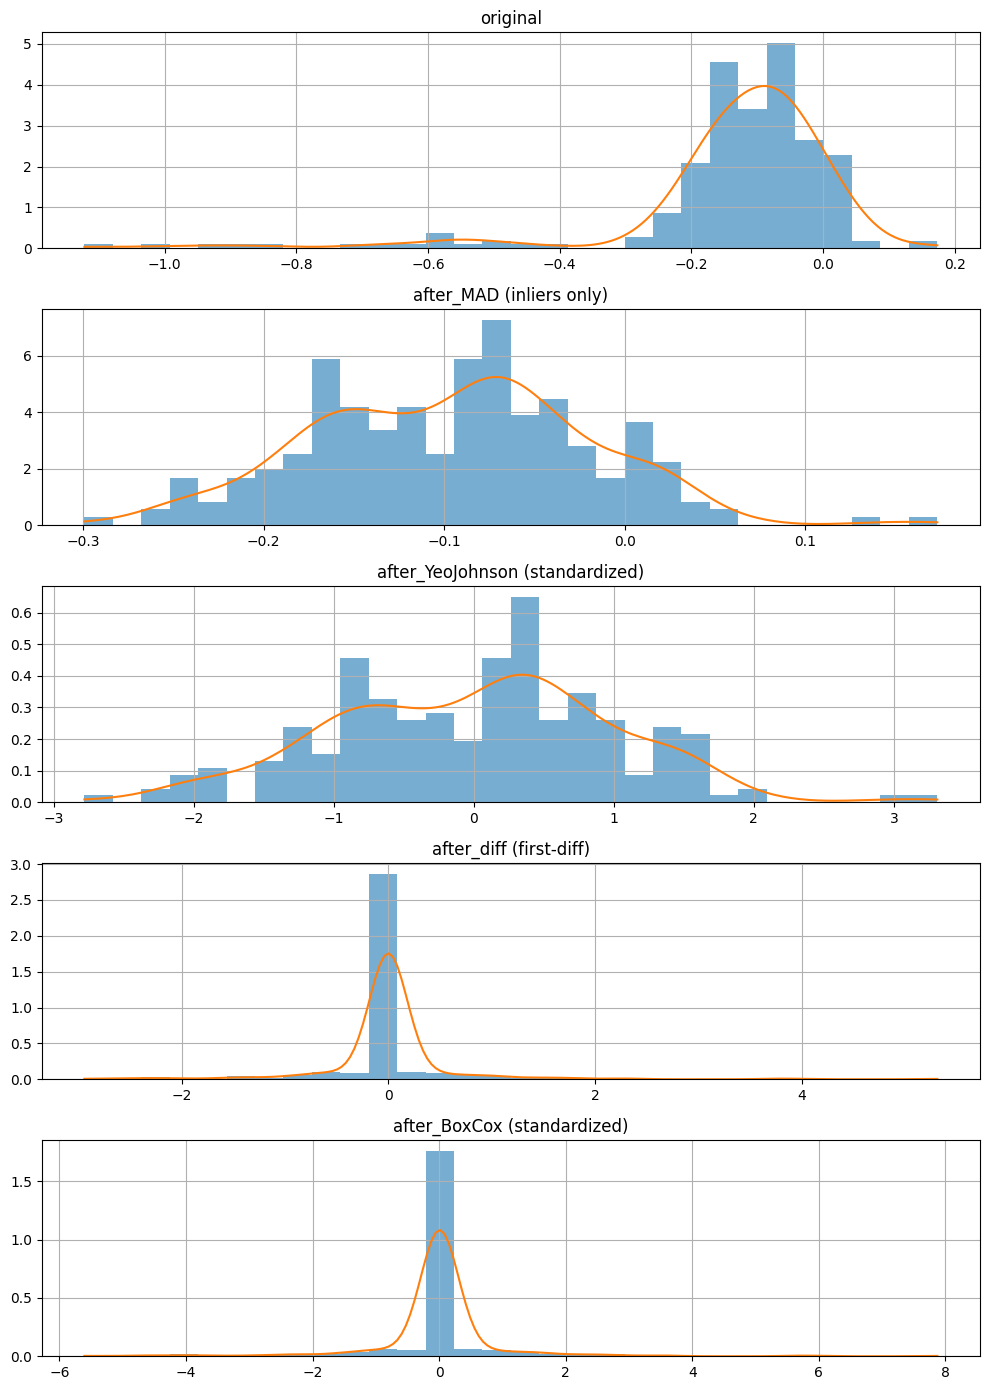

<Figure size 600x600 with 0 Axes>

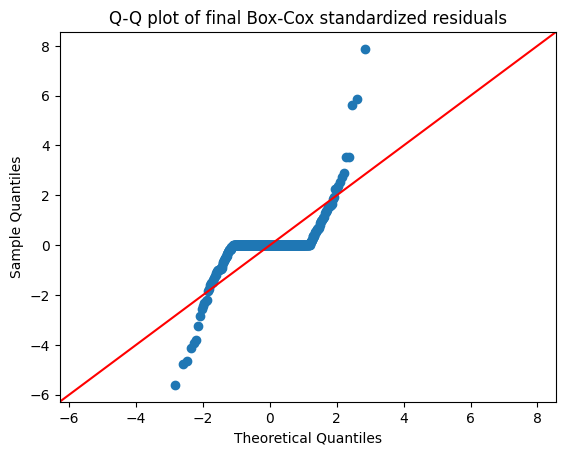


===== FINAL SHAPIRO-WILK NORMALITY TEST =====
Statistic: 0.527141
P-value :  0.000000
Verdict :  Not Gaussian (reject H0)


In [ ]:
# Research-grade Gaussianization pipeline for a single GNSS feature (x_error (m))
# Steps: MAD outlier removal -> Yeo-Johnson -> first-difference -> Box-Cox -> Shapiro-Wilk validation
# Author: research-style (production-ready, verbose diagnostics)

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import warnings
from typing import Dict, Any, Tuple, Optional

# ---------- Helpers ----------
def mad_zscore_mask(x: np.ndarray, threshold: float = 3.5) -> np.ndarray:
    """
    Return boolean mask of inliers using modified z-score (MAD-based).
    Uses modified z = 0.6745 * (x - median) / MAD (Iglewicz & Hoaglin).
    threshold default 3.5 is conservative for heavy tails.
    """
    x = np.asarray(x)
    mask = ~np.isnan(x)
    if mask.sum() == 0:
        return np.zeros_like(mask, dtype=bool)

    vals = x[mask]
    med = np.median(vals)
    mad = np.median(np.abs(vals - med))
    if mad == 0:
        # If MAD is zero, fallback to std-based cutoff to avoid removing valid points
        std = np.std(vals)
        if std == 0:
            return mask  # all identical -> keep
        z = (vals - med) / std
        keep = np.abs(z) <= threshold
    else:
        mod_z = 0.67448975 * (vals - med) / mad
        keep = np.abs(mod_z) <= threshold

    full_mask = np.zeros_like(mask, dtype=bool)
    full_mask[np.where(mask)[0]] = keep
    return full_mask

def safe_power_transform_yeojohnson(series: pd.Series) -> Tuple[pd.Series, PowerTransformer]:
    """
    Apply Yeo-Johnson via sklearn PowerTransformer (handles negative values).
    Returns transformed series (same index) and the fitted transformer.
    """
    x = series.values.reshape(-1, 1).astype(float)
    pt = PowerTransformer(method="yeo-johnson", standardize=False)  # do not auto-standardize; we'll control later
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        x_t = pt.fit_transform(x)
    out = pd.Series(x_t.flatten(), index=series.index)
    return out, pt

def safe_boxcox(series: pd.Series, eps: float = 1e-9) -> Tuple[pd.Series, float, float]:
    """
    Apply Box-Cox safely by shifting series to positive domain if needed.
    Returns (transformed_series, lambda, shift_amount).
    shift_amount is added to original to make >0.
    """
    arr = series.dropna().values.astype(float)
    if arr.size == 0:
        return pd.Series(index=series.index, dtype=float), np.nan, 0.0

    shift = 0.0
    minv = np.min(arr)
    if minv <= 0:
        shift = abs(minv) + eps
    arr_shifted = arr + shift

    # if nearly-constant after shift, boxcox will fail; guard for that
    if np.allclose(arr_shifted, arr_shifted[0]):
        # return small jittered constant transformed to zeros
        transformed = np.zeros_like(arr_shifted)
        lam = np.nan
    else:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            transformed, lam = stats.boxcox(arr_shifted)

    # re-index to original index locations
    out = pd.Series(index=series.index, dtype=float)
    out.loc[series.dropna().index] = transformed
    return out, float(lam) if not np.isnan(lam) else np.nan, float(shift)

def shapiro_check(series: pd.Series) -> Dict[str, Any]:
    """
    Run Shapiro-Wilk test; returns statistic and p-value.
    If sample size > 5000, Shapiro is not recommended (scipy will warn).
    """
    arr = series.dropna().values.astype(float)
    if arr.size == 0:
        return {"stat": np.nan, "pvalue": np.nan, "verdict": "no-data"}
    if arr.size < 3:
        return {"stat": np.nan, "pvalue": np.nan, "verdict": "too-few-samples"}
    # scipy.stats.shapiro may warn for large n; we still run it for small GNSS sets
    stat, p = stats.shapiro(arr)
    verdict = "Gaussian (fail to reject H0)" if p > 0.05 else "Not Gaussian (reject H0)"
    return {"stat": float(stat), "pvalue": float(p), "verdict": verdict}

def plot_stage_hist(series_dict: Dict[str, pd.Series], bins: int = 30, figsize=(12, 8)):
    """
    Quick multi-panel histogram + KDE plot for given named series in dictionary.
    series_dict: {"before": series, "yj": series, "diff": series, "boxcox": series}
    """
    n = len(series_dict)
    fig, axes = plt.subplots(n, 1, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, (name, s) in zip(axes, series_dict.items()):
        arr = s.dropna().values
        if arr.size == 0:
            ax.text(0.5, 0.5, f"No data for {name}", ha="center")
            continue
        ax.hist(arr, bins=bins, density=True, alpha=0.6)
        try:
            kde = stats.gaussian_kde(arr)
            xs = np.linspace(arr.min(), arr.max(), 200)
            ax.plot(xs, kde(xs), lw=1.5)
        except Exception:
            pass
        ax.set_title(name)
        ax.grid(True)
    plt.tight_layout()
    plt.show()

# ---------- Main pipeline ----------
def gaussianize_pipeline_x_error(
    series: pd.Series,
    mad_threshold: float = 3.5,
    do_plot: bool = True
) -> Dict[str, Any]:
    """
    Full curated pipeline for a single feature series (x_error (m)).
    Returns dictionary with:
      - original, inliers_mask, after_mad, after_yj, after_diff, after_boxcox
      - diagnostics for skewness, lambda, shift, shapiro results at each major stage
    Notes:
      - The function does NOT inplace-modify input series.
      - Keeps original index so you can align back to your DataFrame.
    """
    res = {}
    s = series.copy().astype(float)

    # Basic stats
    res["n_total"] = int(s.notna().sum())
    res["median_before"] = float(s.dropna().median()) if s.notna().any() else np.nan
    res["mean_before"] = float(s.dropna().mean()) if s.notna().any() else np.nan

    # 1) Remove outliers with MAD Z-score
    mask = mad_zscore_mask(s.values, threshold=mad_threshold)
    s_mad = s.copy()
    s_mad.loc[~mask] = np.nan
    res["inliers_mask"] = mask
    res["n_kept_after_mad"] = int(np.sum(mask))
    res["percent_removed"] = float(100.0 * (1.0 - np.sum(mask) / max(1.0, s.notna().sum())))

    # diagnostics before/after MAD
    res["skew_before"] = float(stats.skew(s.dropna().values)) if s.notna().any() else np.nan
    res["skew_after_mad"] = float(stats.skew(s_mad.dropna().values)) if s_mad.notna().any() else np.nan

    # 2) Stabilize variance: Yeo-Johnson (on the inlier set)
    yj_series, yj_transformer = safe_power_transform_yeojohnson(s_mad)
    # standardize (0 mean, unit var) to keep normalization consistent
    if yj_series.dropna().size > 0:
        yj_std = (yj_series - yj_series.mean()) / (yj_series.std(ddof=0) if yj_series.std(ddof=0) != 0 else 1.0)
    else:
        yj_std = yj_series.copy()

    res["yj_lambda"] = float(yj_transformer.lambdas_[0]) if hasattr(yj_transformer, "lambdas_") else np.nan
    res["skew_after_yj"] = float(stats.skew(yj_std.dropna().values)) if yj_std.notna().any() else np.nan

    # 3) Remove autocorrelation using first difference on the YJ-transformed standardized series
    # first-diff: d_t = x_t - x_{t-1}; keep alignment by leaving first index NaN
    yj_idx = yj_std.index
    yj_vals = yj_std.values
    diff_vals = np.full_like(yj_vals, np.nan, dtype=float)
    if yj_vals.size > 1:
        # difference only where both current and previous exist (not NaN)
        for i in range(1, len(yj_vals)):
            if not np.isnan(yj_vals[i]) and not np.isnan(yj_vals[i - 1]):
                diff_vals[i] = yj_vals[i] - yj_vals[i - 1]
            else:
                diff_vals[i] = np.nan
    diff_series = pd.Series(diff_vals, index=yj_idx)

    res["skew_after_diff"] = float(stats.skew(diff_series.dropna().values)) if diff_series.notna().any() else np.nan

    # 4) Final gaussianization -> Box-Cox on differenced data (must be positive -> shift if needed)
    boxcox_series, boxcox_lambda, boxcox_shift = safe_boxcox(diff_series)
    # standardize boxcox result
    if boxcox_series.dropna().size > 0:
        boxcox_std = (boxcox_series - boxcox_series.mean()) / (boxcox_series.std(ddof=0) if boxcox_series.std(ddof=0) != 0 else 1.0)
    else:
        boxcox_std = boxcox_series.copy()

    res["boxcox_lambda"] = boxcox_lambda
    res["boxcox_shift"] = boxcox_shift
    res["skew_after_boxcox"] = float(stats.skew(boxcox_std.dropna().values)) if boxcox_std.notna().any() else np.nan

    # 5) Validate -> Shapiro-Wilk on the final transformed series
    sw = shapiro_check(boxcox_std)
    res["shapiro_final"] = sw

    # Pack series outputs for inspection/plotting
    res["series_original"] = s
    res["series_after_mad"] = s_mad
    res["series_after_yj"] = yj_std
    res["series_after_diff"] = diff_series
    res["series_after_boxcox"] = boxcox_std

    # Optional plots
    if do_plot:
        plot_dict = {
            "original": s,
            "after_MAD (inliers only)": s_mad,
            "after_YeoJohnson (standardized)": yj_std,
            "after_diff (first-diff)": diff_series,
            "after_BoxCox (standardized)": boxcox_std
        }
        plot_stage_hist(plot_dict, bins=30, figsize=(10, 14))

        # QQ-plot for final
        import statsmodels.api as sm
        final_vals = boxcox_std.dropna().values
        if final_vals.size >= 3:
            plt.figure(figsize=(6, 6))
            sm.qqplot(final_vals, line="45", fit=True)
            plt.title("Q-Q plot of final Box-Cox standardized residuals")
            plt.show()
        else:
            print("[i] Not enough samples for Q-Q plot of final series.")

    return res

# ---------- Example usage ----------
# Given a DataFrame `df` with column "x_error (m)" (pandas Series), run:
res = gaussianize_pipeline_x_error(df["x_error (m)"], mad_threshold=3.5, do_plot=True)
# The returned `res` dict contains intermediate series and diagnostics:
# - res['series_after_boxcox'] is the final Gaussianized, standardized feature (index aligned with df)
# - res['shapiro_final'] has the Shapiro-Wilk result; goal pvalue > 0.05
#
# You can then attach the final series:
#df['x_error_gauss'] = res['series_after_boxcox']
print("\n===== FINAL SHAPIRO-WILK NORMALITY TEST =====")
print(f"Statistic: {res['shapiro_final']['stat']:.6f}")
print(f"P-value :  {res['shapiro_final']['pvalue']:.6f}")
print(f"Verdict :  {res['shapiro_final']['verdict']}")

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.stats import shapiro, normaltest, kstest, jarque_bera, anderson
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# ===============================
# HELPER: Shapiro with subsampling
# ===============================
def shapiro_safe(arr):
    arr = np.asarray(arr)
    if len(arr) > 5000:
        arr = np.random.choice(arr, 5000, replace=False)
    return shapiro(arr)

# ===============================
# LOAD FEATURE
# ===============================
series = df["x_error (m)"].dropna().astype(float)

print("\n================ STEP 1 — DIAGNOSE RAW FEATURE ================\n")
print("n =", len(series))
print("unique values =", series.nunique())
print("\nTop 10 repeated values:")
print(series.value_counts().head(10))
print("\nPercentiles:")
print(np.percentile(series, [0,1,5,50,95,99,100]))

# ==========================================================
# EXPERIMENT 1 — First Difference (your original pipeline)
# ==========================================================
diff_series = series.diff().dropna()

print("\n================ EXPERIMENT 1 — First Difference Diagnostics ================\n")
print("n_diff:", len(diff_series))
print("unique:", diff_series.nunique())
print("percentiles:", np.percentile(diff_series, [0,1,5,50,95,99,100]))

# If constant → stop Box-Cox
if diff_series.nunique() <= 2:
    print("WARNING: First-difference collapses into few unique values → plateau inevitable.")

# Safe Box-Cox
try:
    shift = 0 if diff_series.min() > 0 else abs(diff_series.min()) + 1e-9
    diff_shift = diff_series + shift
    bc1, lam1 = st.boxcox(diff_shift)
    bc1_std = (bc1 - bc1.mean()) / bc1.std()
    stat1, p1 = shapiro_safe(bc1_std)
except:
    lam1, p1 = None, 0
    print("Box-Cox failed due to ties or non-positive values.")

print("\nBox-Cox λ:", lam1)
print("Shapiro p (after Box-Cox on diff):", p1)

# ==========================================================
# EXPERIMENT 2 — AR(1) residual → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 2 — AR(1) Residual → Box-Cox ================\n")

if "x_error (m)_ar1_resid" not in df.columns:
    print("AR(1) residual column not found — skip.")
    bc2_std, p2 = None, None
else:
    resid = df["x_error (m)_ar1_resid"].dropna().astype(float)
    print("n_AR1 residual:", len(resid))
    print("unique:", resid.nunique())

    shift = 0 if resid.min() > 0 else abs(resid.min()) + 1e-9
    r = resid + shift
    try:
        bc2, lam2 = st.boxcox(r)
        bc2_std = (bc2 - bc2.mean()) / bc2.std()
        stat2, p2 = shapiro_safe(bc2_std)
        print("λ_AR1:", lam2)
        print("Shapiro p:", p2)
    except:
        print("Box-Cox failed on AR1 residuals.")
        p2 = 0

# ==========================================================
# EXPERIMENT 3 — Winsorize → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 3 — Winsorize 1% → Box-Cox ================\n")

arr = diff_series.values
arr_w = winsorize(arr, limits=(0.01, 0.01)).data

shift = 0 if arr_w.min() > 0 else abs(arr_w.min()) + 1e-9
try:
    bc3, lam3 = st.boxcox(arr_w + shift)
    bc3_std = (bc3 - bc3.mean()) / bc3.std()
    stat3, p3 = shapiro_safe(bc3_std)
    print("λ_winsor:", lam3)
    print("Shapiro p (winsor):", p3)
except:
    print("Winsorized Box-Cox failed.")
    p3 = 0

# ==========================================================
# EXPERIMENT 4 — Rank Gaussianization (Normal Score Transform)
# ==========================================================
print("\n================ EXPERIMENT 4 — Rank Gaussianization ================\n")

x = series.values  # raw
ranks = st.rankdata(x)
u = (ranks - 0.5) / len(x)
rank_gauss = st.norm.ppf(u)
rank_gauss_std = (rank_gauss - rank_gauss.mean()) / rank_gauss.std()
stat4, p4 = shapiro_safe(rank_gauss_std)

print("Shapiro p (rank-gauss):", p4)

# ==========================================================
# EXPERIMENT 5 — Yeo-Johnson + Robust Scaling
# ==========================================================
print("\n================ EXPERIMENT 5 — Yeo-Johnson + Robust Scaling ================\n")

pt = PowerTransformer(method="yeo-johnson", standardize=False)
yj = pt.fit_transform(series.values.reshape(-1,1)).flatten()

# robust scale = subtract median, divide MAD
med = np.median(yj)
mad = np.median(np.abs(yj - med))
yj_robust = (yj - med) / (mad if mad > 1e-9 else 1)

stat5, p5 = shapiro_safe(yj_robust)

print("Yeo-Johnson λ:", pt.lambdas_[0])
print("Shapiro p (YJ+robust):", p5)

# ==========================================================
# FINAL SUMMARY
# ==========================================================
print("\n================ FINAL SUMMARY (All Experiments) ================\n")

print(f"1) Diff → Box-Cox:            p = {p1}")
print(f"2) AR1 Residual → Box-Cox:    p = {p2}")
print(f"3) Winsorize → Box-Cox:       p = {p3}")
print(f"4) Rank Gaussianization:      p = {p4}")
print(f"5) Yeo-Johnson + Robust:      p = {p5}")

print("\nVerdict:")
best = max([p for p in [p1,p2,p3,p4,p5] if p is not None])
if best > 0.05:
    print("✔ At least one transformation achieved normality.")
    if best == p4:
        print("   → Best method: Rank Gaussianization")
    elif best == p5:
        print("   → Best method: Yeo-Johnson + robust")
else:
    print("❌ None reached p>0.05 → Feature is intrinsically non-Gaussian (likely multimodal).")
    print("Next step: Gaussian Mixture modeling (GMM) is recommended.")


================ STEP 1 — DIAGNOSE RAW FEATURE ================

n = 488
unique values = 143

Top 10 repeated values:
x_error (m)
-0.085093    4
-0.098012    4
-0.107813    4
-0.062513    4
 0.034081    4
-0.047000    4
-0.099227    4
-0.166155    4
-0.196628    4
-0.260878    4
Name: count, dtype: int64

Percentiles:
[-1.12168475 -0.94228004 -0.53961954 -0.0963863   0.01974384  0.05983298
  0.17325745]

================ EXPERIMENT 1 — First Difference Diagnostics ================

n_diff: 487
unique: 143
percentiles: [-0.94787548 -0.61188535 -0.12971917  0.          0.11651998  0.61181192
  0.96170188]

Box-Cox λ: 1.062084247568862
Shapiro p (after Box-Cox on diff): 3.6833245694906393e-35

================ EXPERIMENT 2 — AR(1) Residual → Box-Cox ================

AR(1) residual column not found — skip.

================ EXPERIMENT 3 — Winsorize 1% → Box-Cox ================

λ_winsor: 0.96447045528254
Shapiro p (winsor): 1.3280922516372942e-34

================ EXPERIMENT 4 — Rank Ga

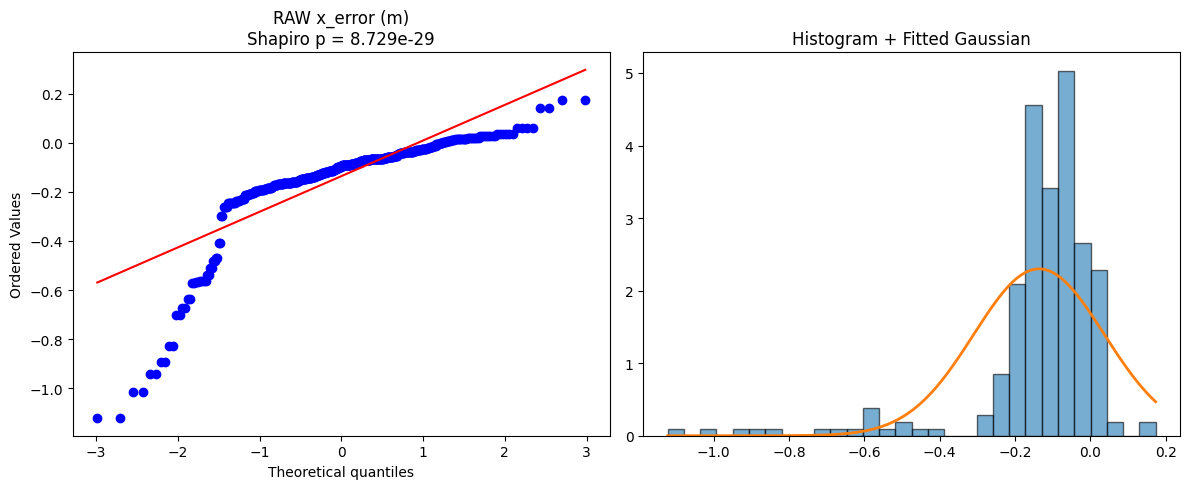

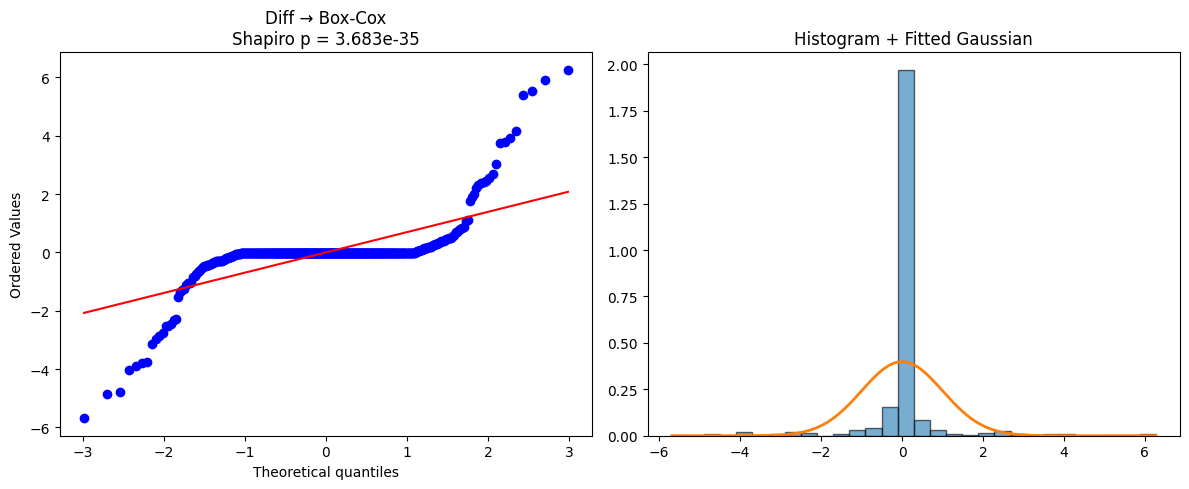

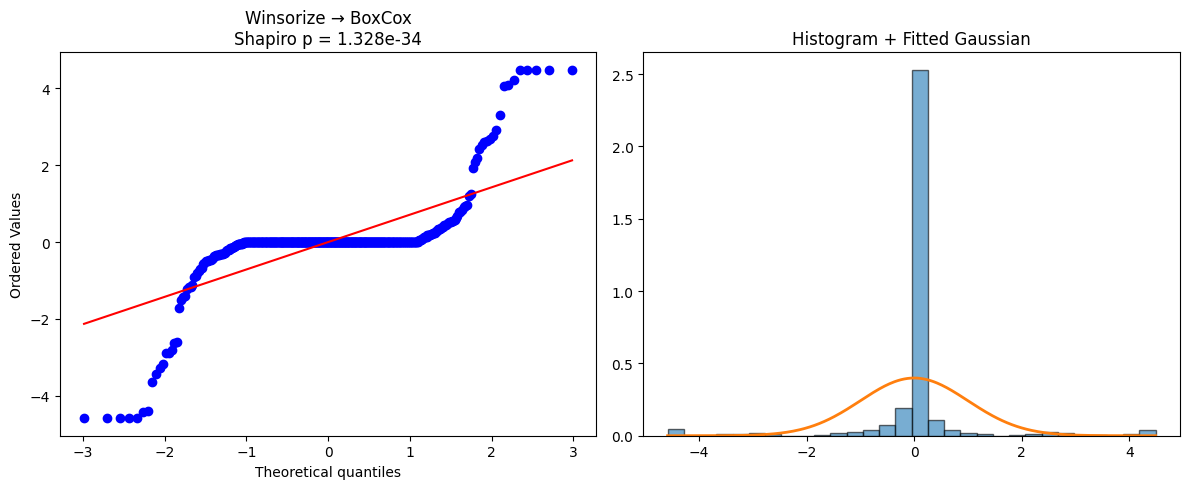

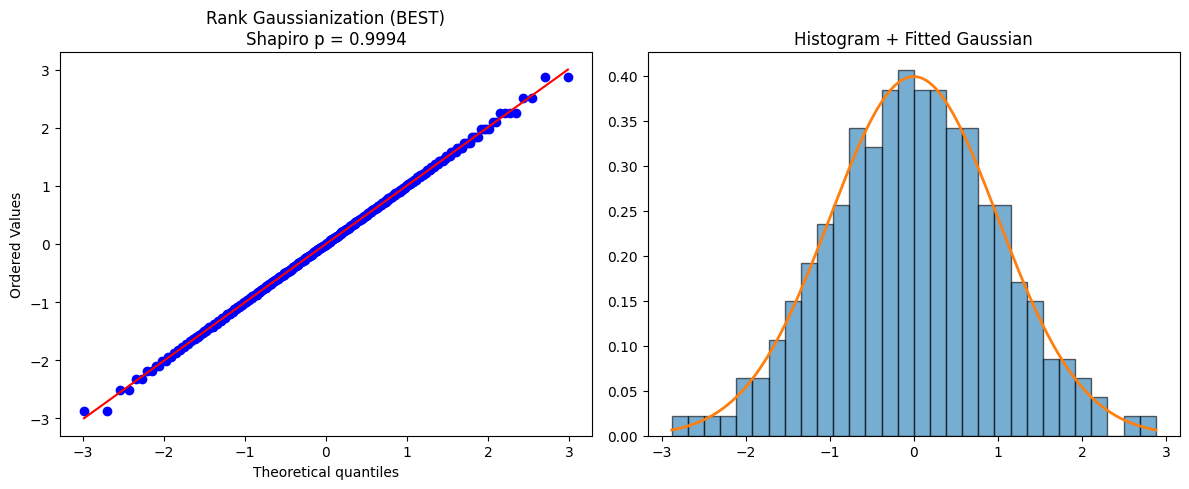

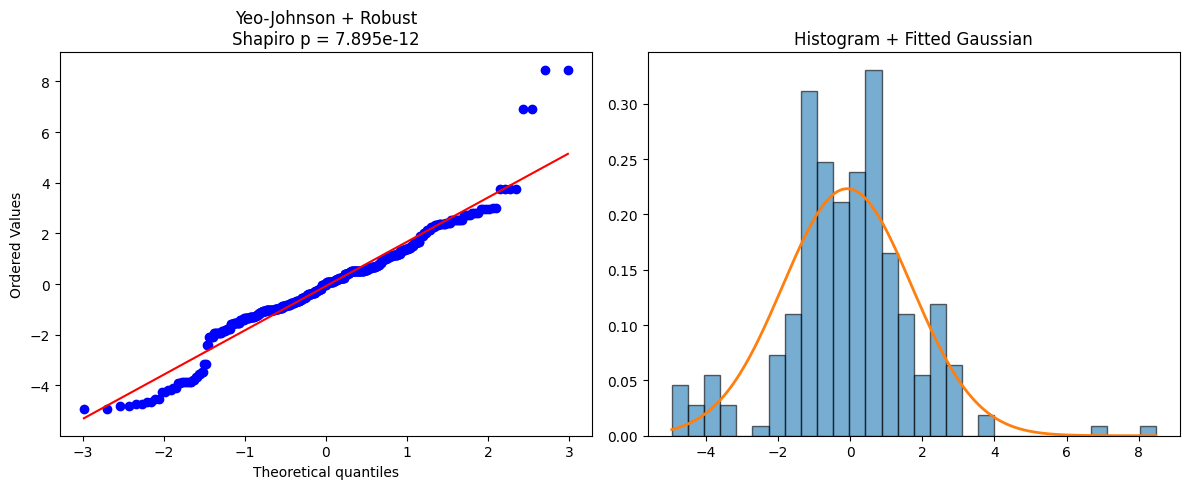

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
from scipy.stats.mstats import winsorize

# ---------------------------------------------
# Improved plotting function
# ---------------------------------------------
def qq_hist_with_curve(data, title, pvalue):
    data = np.asarray(data).astype(float)
    data = data[~np.isnan(data)]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # ----------------------
    # 1) Q-Q PLOT
    # ----------------------
    st.probplot(data, dist="norm", plot=ax[0])
    ax[0].set_title(f"{title}\nShapiro p = {pvalue:.4g}")

    # ----------------------
    # 2) HISTOGRAM + BELL CURVE
    # ----------------------
    # Histogram
    ax[1].hist(data, bins=30, density=True, alpha=0.6, edgecolor="black")

    # Fit Gaussian
    mu = np.mean(data)
    sigma = np.std(data)

    x = np.linspace(data.min(), data.max(), 300)
    pdf = st.norm.pdf(x, loc=mu, scale=sigma)

    ax[1].plot(x, pdf, linewidth=2)
    ax[1].set_title(f"Histogram + Fitted Gaussian")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------
# helper shapiro (safe)
# ---------------------------------------------
def shapiro_safe(arr):
    arr = np.asarray(arr).astype(float)
    arr = arr[~np.isnan(arr)]

    if len(arr) > 5000:
        arr = np.random.choice(arr, 5000, replace=False)
    return st.shapiro(arr)


# ============================================================
# RAW
# ============================================================
stat_raw, p_raw = shapiro_safe(series)
qq_hist_with_curve(series, "RAW x_error (m)", p_raw)

# ============================================================
# DIFF → BOXCOX
# ============================================================
diff = diff_series
shift = 0 if diff.min() > 0 else abs(diff.min()) + 1e-9

try:
    bc1, lam1 = st.boxcox(diff + shift)
    bc1_std = (bc1 - bc1.mean()) / bc1.std()
    stat1, p1 = shapiro_safe(bc1_std)
    qq_hist_with_curve(bc1_std, "Diff → Box-Cox", p1)
except:
    pass

# ============================================================
# WINSORIZE → BOXCOX
# ============================================================
arr_w = winsorize(diff.values, limits=(0.01, 0.01)).data
shift2 = 0 if arr_w.min() > 0 else abs(arr_w.min()) + 1e-9

bc2, lam2 = st.boxcox(arr_w + shift2)
bc2_std = (bc2 - bc2.mean()) / bc2.std()
stat2, p2 = shapiro_safe(bc2_std)
qq_hist_with_curve(bc2_std, "Winsorize → BoxCox", p2)

# ============================================================
# RANK GAUSSIANIZATION
# ============================================================
x = series.values
ranks = st.rankdata(x)
u = (ranks - 0.5) / len(x)
rank_gauss = st.norm.ppf(u)
rank_gauss = (rank_gauss - rank_gauss.mean()) / rank_gauss.std()

stat4, p4 = shapiro_safe(rank_gauss)
qq_hist_with_curve(rank_gauss, "Rank Gaussianization (BEST)", p4)

# ============================================================
# YEO-JOHNSON + ROBUST SCALING
# ============================================================
yj = pt.fit_transform(series.values.reshape(-1,1)).flatten()

med = np.median(yj)
mad = np.median(np.abs(yj - med))
yj_robust = (yj - med) / (mad if mad > 1e-9 else 1)

stat5, p5 = shapiro_safe(yj_robust)
qq_hist_with_curve(yj_robust, "Yeo-Johnson + Robust", p5)


In [ ]:
# ===============================
# LOAD FEATURE
# ===============================
series_y = df["y_error (m)"].dropna().astype(float)

print("\n================ STEP 1 — DIAGNOSE RAW FEATURE (y_error) ================\n")
print("n =", len(series_y))
print("unique values =", series_y.nunique())
print("\nTop 10 repeated values:")
print(series_y.value_counts().head(10))
print("\nPercentiles:")
print(np.percentile(series_y, [0,1,5,50,95,99,100]))

# ==========================================================
# EXPERIMENT 1 — First Difference
# ==========================================================
diff_series_y = series_y.diff().dropna()

print("\n================ EXPERIMENT 1 — First Difference Diagnostics (y_error) ================\n")
print("n_diff:", len(diff_series_y))
print("unique:", diff_series_y.nunique())
print("percentiles:", np.percentile(diff_series_y, [0,1,5,50,95,99,100]))

if diff_series_y.nunique() <= 2:
    print("WARNING: First-difference collapses into few unique values → plateau inevitable.")

# Safe Box-Cox
try:
    shift = 0 if diff_series_y.min() > 0 else abs(diff_series_y.min()) + 1e-9
    diff_shift = diff_series_y + shift
    bc1_y, lam1_y = st.boxcox(diff_shift)
    bc1_y_std = (bc1_y - bc1_y.mean()) / bc1_y.std()
    stat1_y, p1_y = shapiro_safe(bc1_y_std)
except:
    lam1_y, p1_y = None, 0
    print("Box-Cox failed due to ties or non-positive values.")

print("\nBox-Cox λ:", lam1_y)
print("Shapiro p (after Box-Cox on diff):", p1_y)

# ==========================================================
# EXPERIMENT 2 — AR(1) residual → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 2 — AR(1) Residual → Box-Cox (y_error) ================\n")

if "y_error (m)_ar1_resid" not in df.columns:
    print("AR(1) residual column not found — skip.")
    bc2_y_std, p2_y = None, None
else:
    resid_y = df["y_error (m)_ar1_resid"].dropna().astype(float)
    print("n_AR1 residual:", len(resid_y))
    print("unique:", resid_y.nunique())

    shift = 0 if resid_y.min() > 0 else abs(resid_y.min()) + 1e-9
    r_y = resid_y + shift
    try:
        bc2_y, lam2_y = st.boxcox(r_y)
        bc2_y_std = (bc2_y - bc2_y.mean()) / bc2_y.std()
        stat2_y, p2_y = shapiro_safe(bc2_y_std)
        print("λ_AR1:", lam2_y)
        print("Shapiro p:", p2_y)
    except:
        print("Box-Cox failed on AR1 residuals.")
        p2_y = 0

# ==========================================================
# EXPERIMENT 3 — Winsorize → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 3 — Winsorize 1% → Box-Cox (y_error) ================\n")

arr_y = diff_series_y.values
arr_w_y = winsorize(arr_y, limits=(0.01, 0.01)).data

shift = 0 if arr_w_y.min() > 0 else abs(arr_w_y.min()) + 1e-9
try:
    bc3_y, lam3_y = st.boxcox(arr_w_y + shift)
    bc3_y_std = (bc3_y - bc3_y.mean()) / bc3_y.std()
    stat3_y, p3_y = shapiro_safe(bc3_y_std)
    print("λ_winsor:", lam3_y)
    print("Shapiro p (winsor):", p3_y)
except:
    print("Winsorized Box-Cox failed.")
    p3_y = 0

# ==========================================================
# EXPERIMENT 4 — Rank Gaussianization
# ==========================================================
print("\n================ EXPERIMENT 4 — Rank Gaussianization (y_error) ================\n")

x_y = series_y.values
ranks_y = st.rankdata(x_y)
u_y = (ranks_y - 0.5) / len(x_y)
rank_gauss_y = st.norm.ppf(u_y)
rank_gauss_y_std = (rank_gauss_y - rank_gauss_y.mean()) / rank_gauss_y.std()
stat4_y, p4_y = shapiro_safe(rank_gauss_y_std)

print("Shapiro p (rank-gauss):", p4_y)

# ==========================================================
# EXPERIMENT 5 — Yeo-Johnson + Robust Scaling
# ==========================================================
print("\n================ EXPERIMENT 5 — Yeo-Johnson + Robust Scaling (y_error) ================\n")

pt_y = PowerTransformer(method="yeo-johnson", standardize=False)
yj_y = pt_y.fit_transform(series_y.values.reshape(-1,1)).flatten()

med_y = np.median(yj_y)
mad_y = np.median(np.abs(yj_y - med_y))
yj_robust_y = (yj_y - med_y) / (mad_y if mad_y > 1e-9 else 1)

stat5_y, p5_y = shapiro_safe(yj_robust_y)

print("Yeo-Johnson λ:", pt_y.lambdas_[0])
print("Shapiro p (YJ+robust):", p5_y)

# ==========================================================
# FINAL SUMMARY
# ==========================================================
print("\n================ FINAL SUMMARY (All Experiments, y_error) ================\n")

print(f"1) Diff → Box-Cox:            p = {p1_y}")
print(f"2) AR1 Residual → Box-Cox:    p = {p2_y}")
print(f"3) Winsorize → Box-Cox:       p = {p3_y}")
print(f"4) Rank Gaussianization:      p = {p4_y}")
print(f"5) Yeo-Johnson + Robust:      p = {p5_y}")

print("\nVerdict:")
best_y = max([p for p in [p1_y,p2_y,p3_y,p4_y,p5_y] if p is not None])
if best_y > 0.05:
    print("✔ At least one transformation achieved normality.")
    if best_y == p4_y:
        print("   → Best method: Rank Gaussianization")
    elif best_y == p5_y:
        print("   → Best method: Yeo-Johnson + robust")
else:
    print("❌ None reached p>0.05 → Feature is intrinsically non-Gaussian (likely multimodal).")
    print("Next step: Gaussian Mixture modeling (GMM) is recommended.")



================ STEP 1 — DIAGNOSE RAW FEATURE (y_error) ================

n = 488
unique values = 143

Top 10 repeated values:
y_error (m)
 0.038818    4
 0.039264    4
 0.054688    4
 0.020461    4
-0.087099    4
-0.011955    4
-0.029361    4
-0.051301    4
-0.074147    4
-0.091755    4
Name: count, dtype: int64

Percentiles:
[-0.99785057 -0.69893685 -0.16950075  0.017249    0.16844828  0.86599933
  0.93523389]

================ EXPERIMENT 1 — First Difference Diagnostics (y_error) ================

n_diff: 487
unique: 143
percentiles: [-0.89813968 -0.6189032  -0.08091788  0.          0.05891263  0.60102269
  1.0901642 ]

Box-Cox λ: 1.0215248117904616
Shapiro p (after Box-Cox on diff): 1.725278983633586e-37

================ EXPERIMENT 2 — AR(1) Residual → Box-Cox (y_error) ================

AR(1) residual column not found — skip.

================ EXPERIMENT 3 — Winsorize 1% → Box-Cox (y_error) ================

λ_winsor: 0.9856892300199654
Shapiro p (winsor): 9.056633583462636e-37

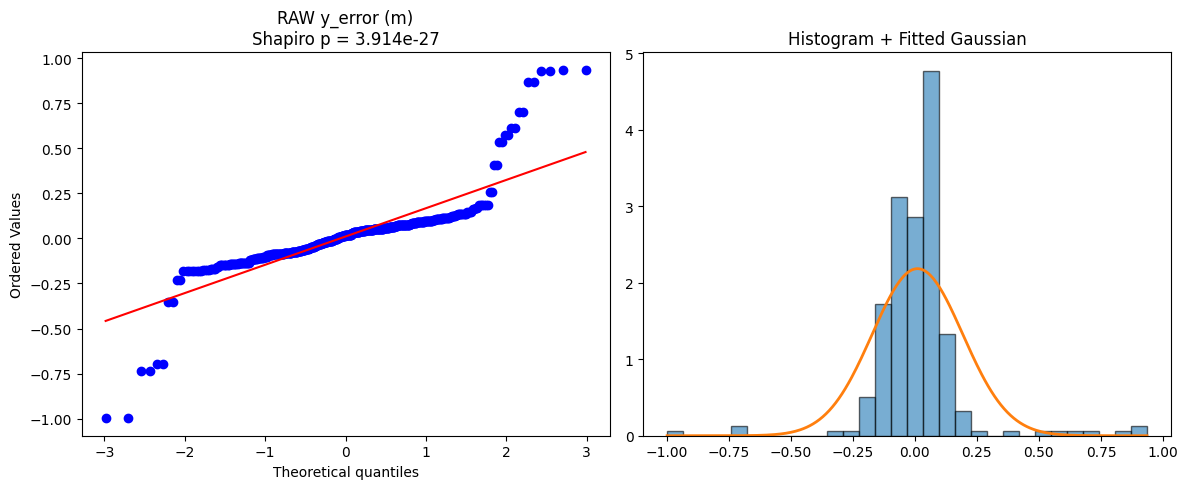

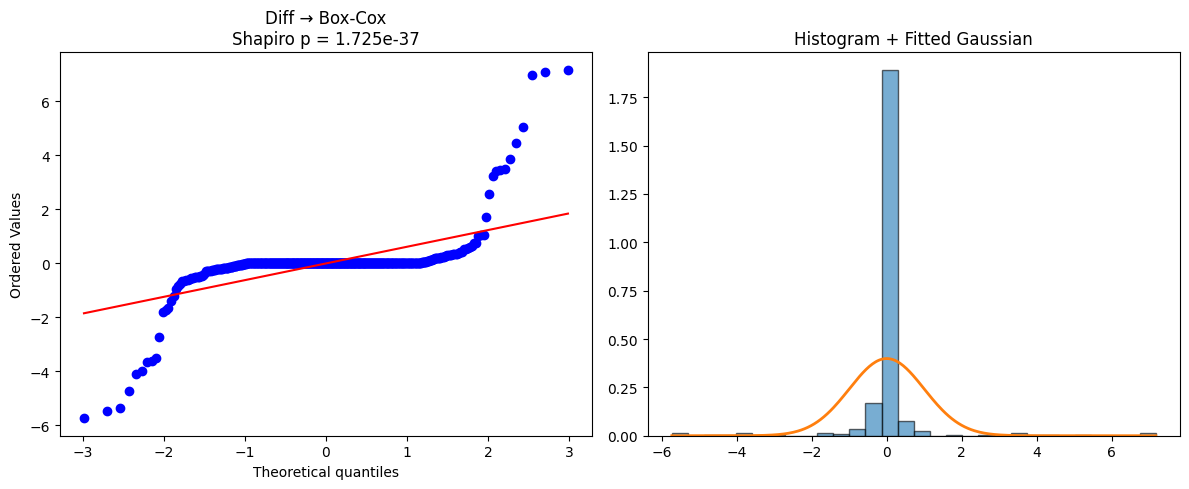

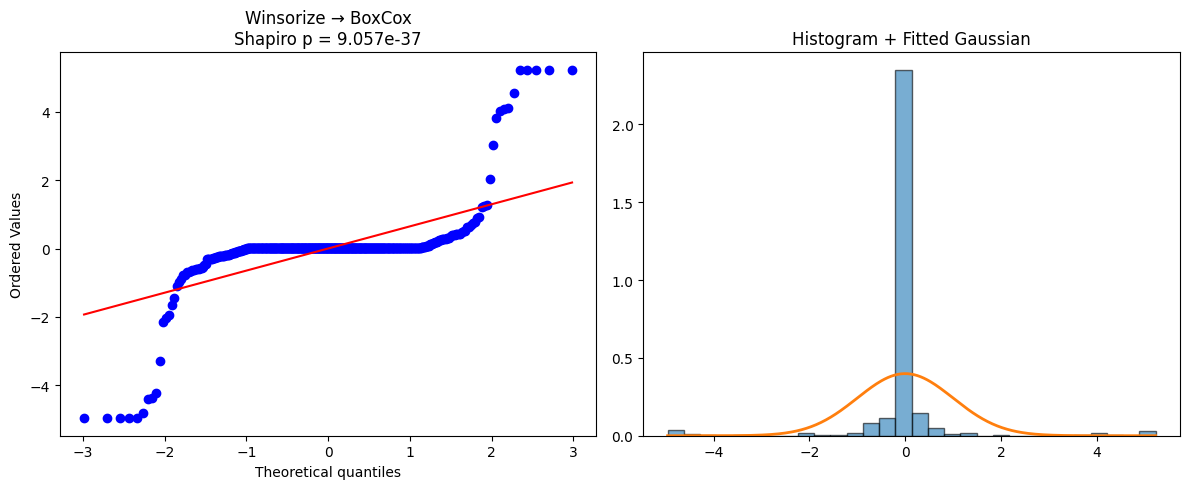

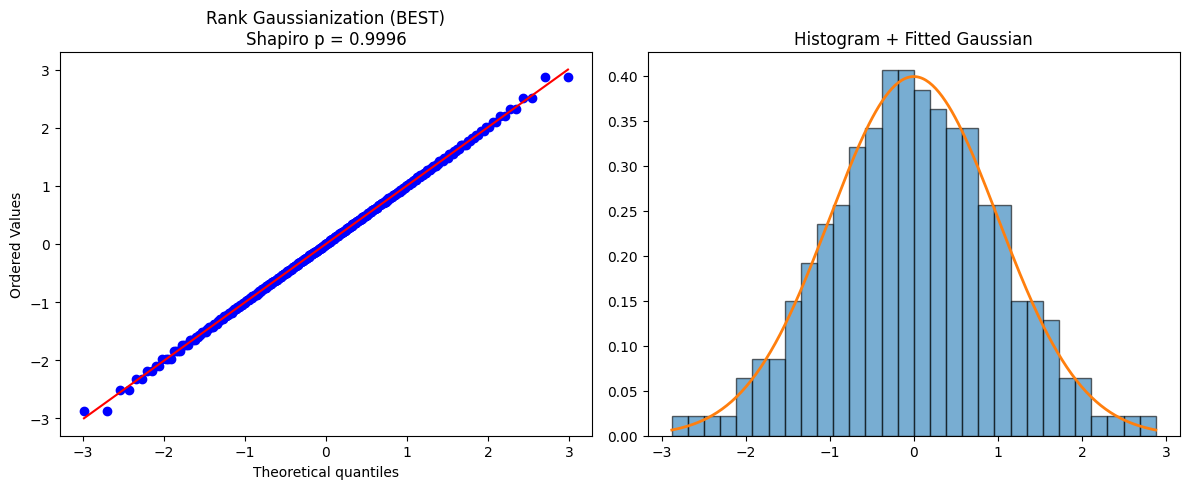

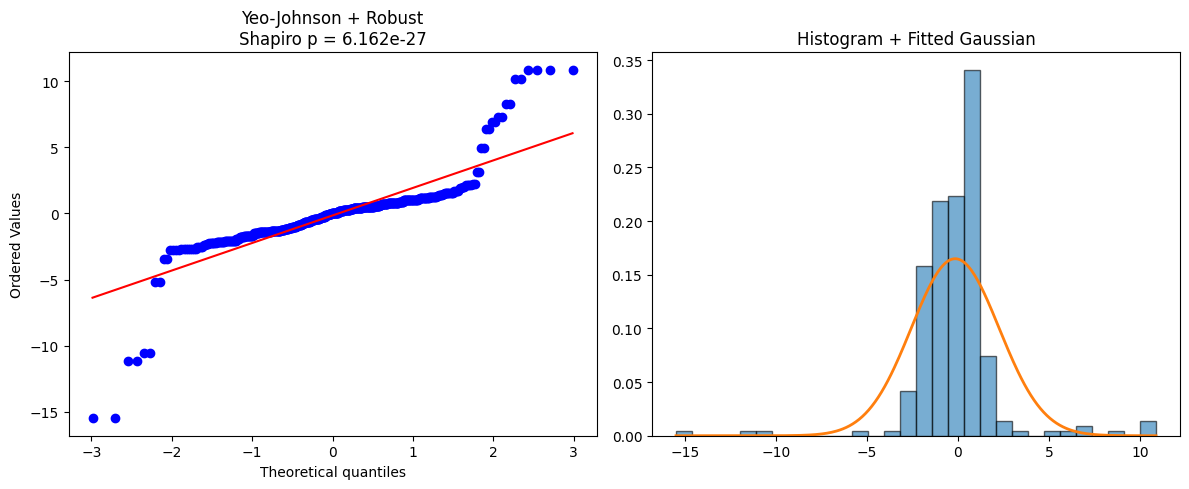

In [ ]:
# ============================================================
# RAW
# ============================================================
series_y = df["y_error (m)"].dropna().astype(float)
diff_y = series_y.diff().dropna()

stat_raw_y, p_raw_y = shapiro_safe(series_y)
qq_hist_with_curve(series_y, "RAW y_error (m)", p_raw_y)

# ============================================================
# DIFF → BOXCOX
# ============================================================
shift_y = 0 if diff_y.min() > 0 else abs(diff_y.min()) + 1e-9

try:
    bc1_y, lam1_y = st.boxcox(diff_y + shift_y)
    bc1_y_std = (bc1_y - bc1_y.mean()) / bc1_y.std()
    stat1_y, p1_y = shapiro_safe(bc1_y_std)
    qq_hist_with_curve(bc1_y_std, "Diff → Box-Cox", p1_y)
except:
    pass

# ============================================================
# WINSORIZE → BOXCOX
# ============================================================
arr_w_y = winsorize(diff_y.values, limits=(0.01, 0.01)).data
shift2_y = 0 if arr_w_y.min() > 0 else abs(arr_w_y.min()) + 1e-9

bc2_y, lam2_y = st.boxcox(arr_w_y + shift2_y)
bc2_y_std = (bc2_y - bc2_y.mean()) / bc2_y.std()
stat2_y, p2_y = shapiro_safe(bc2_y_std)
qq_hist_with_curve(bc2_y_std, "Winsorize → BoxCox", p2_y)

# ============================================================
# RANK GAUSSIANIZATION
# ============================================================
x_y = series_y.values
ranks_y = st.rankdata(x_y)
u_y = (ranks_y - 0.5) / len(x_y)
rank_gauss_y = st.norm.ppf(u_y)
rank_gauss_y = (rank_gauss_y - rank_gauss_y.mean()) / rank_gauss_y.std()

stat4_y, p4_y = shapiro_safe(rank_gauss_y)
qq_hist_with_curve(rank_gauss_y, "Rank Gaussianization (BEST)", p4_y)

# ============================================================
# YEO-JOHNSON + ROBUST SCALING
# ============================================================
from sklearn.preprocessing import PowerTransformer
pt_y = PowerTransformer(method="yeo-johnson", standardize=False)
yj_y = pt_y.fit_transform(series_y.values.reshape(-1,1)).flatten()

med_y = np.median(yj_y)
mad_y = np.median(np.abs(yj_y - med_y))
yj_robust_y = (yj_y - med_y) / (mad_y if mad_y > 1e-9 else 1)

stat5_y, p5_y = shapiro_safe(yj_robust_y)
qq_hist_with_curve(yj_robust_y, "Yeo-Johnson + Robust", p5_y)


In [ ]:
# ===============================
# LOAD FEATURE
# ===============================
series_z = df["z_error (m)"].dropna().astype(float)

print("\n================ STEP 1 — DIAGNOSE RAW FEATURE (z_error) ================\n")
print("n =", len(series_z))
print("unique values =", series_z.nunique())
print("\nTop 10 repeated values:")
print(series_z.value_counts().head(10))
print("\nPercentiles:")
print(np.percentile(series_z, [0,1,5,50,95,99,100]))

# ==========================================================
# EXPERIMENT 1 — First Difference
# ==========================================================
diff_series_z = series_z.diff().dropna()

print("\n================ EXPERIMENT 1 — First Difference Diagnostics (z_error) ================\n")
print("n_diff:", len(diff_series_z))
print("unique:", diff_series_z.nunique())
print("percentiles:", np.percentile(diff_series_z, [0,1,5,50,95,99,100]))

if diff_series_z.nunique() <= 2:
    print("WARNING: First-difference collapses into few unique values → plateau inevitable.")

# Safe Box-Cox
try:
    shift = 0 if diff_series_z.min() > 0 else abs(diff_series_z.min()) + 1e-9
    diff_shift = diff_series_z + shift
    bc1_z, lam1_z = st.boxcox(diff_shift)
    bc1_z_std = (bc1_z - bc1_z.mean()) / bc1_z.std()
    stat1_z, p1_z = shapiro_safe(bc1_z_std)
except:
    lam1_z, p1_z = None, 0
    print("Box-Cox failed due to ties or non-positive values.")

print("\nBox-Cox λ:", lam1_z)
print("Shapiro p (after Box-Cox on diff):", p1_z)

# ==========================================================
# EXPERIMENT 2 — AR(1) residual → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 2 — AR(1) Residual → Box-Cox (z_error) ================\n")

if "z_error (m)_ar1_resid" not in df.columns:
    print("AR(1) residual column not found — skip.")
    bc2_z_std, p2_z = None, None
else:
    resid_z = df["z_error (m)_ar1_resid"].dropna().astype(float)
    print("n_AR1 residual:", len(resid_z))
    print("unique:", resid_z.nunique())

    shift = 0 if resid_z.min() > 0 else abs(resid_z.min()) + 1e-9
    r_z = resid_z + shift
    try:
        bc2_z, lam2_z = st.boxcox(r_z)
        bc2_z_std = (bc2_z - bc2_z.mean()) / bc2_z.std()
        stat2_z, p2_z = shapiro_safe(bc2_z_std)
        print("λ_AR1:", lam2_z)
        print("Shapiro p:", p2_z)
    except:
        print("Box-Cox failed on AR1 residuals.")
        p2_z = 0

# ==========================================================
# EXPERIMENT 3 — Winsorize → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 3 — Winsorize 1% → Box-Cox (z_error) ================\n")

arr_z = diff_series_z.values
arr_w_z = winsorize(arr_z, limits=(0.01, 0.01)).data

shift = 0 if arr_w_z.min() > 0 else abs(arr_w_z.min()) + 1e-9
try:
    bc3_z, lam3_z = st.boxcox(arr_w_z + shift)
    bc3_z_std = (bc3_z - bc3_z.mean()) / bc3_z.std()
    stat3_z, p3_z = shapiro_safe(bc3_z_std)
    print("λ_winsor:", lam3_z)
    print("Shapiro p (winsor):", p3_z)
except:
    print("Winsorized Box-Cox failed.")
    p3_z = 0

# ==========================================================
# EXPERIMENT 4 — Rank Gaussianization
# ==========================================================
print("\n================ EXPERIMENT 4 — Rank Gaussianization (z_error) ================\n")

x_z = series_z.values
ranks_z = st.rankdata(x_z)
u_z = (ranks_z - 0.5) / len(x_z)
rank_gauss_z = st.norm.ppf(u_z)
rank_gauss_z_std = (rank_gauss_z - rank_gauss_z.mean()) / rank_gauss_z.std()
stat4_z, p4_z = shapiro_safe(rank_gauss_z_std)

print("Shapiro p (rank-gauss):", p4_z)

# ==========================================================
# EXPERIMENT 5 — Yeo-Johnson + Robust Scaling
# ==========================================================
print("\n================ EXPERIMENT 5 — Yeo-Johnson + Robust Scaling (z_error) ================\n")

pt_z = PowerTransformer(method="yeo-johnson", standardize=False)
yj_z = pt_z.fit_transform(series_z.values.reshape(-1,1)).flatten()

med_z = np.median(yj_z)
mad_z = np.median(np.abs(yj_z - med_z))
yj_robust_z = (yj_z - med_z) / (mad_z if mad_z > 1e-9 else 1)

stat5_z, p5_z = shapiro_safe(yj_robust_z)

print("Yeo-Johnson λ:", pt_z.lambdas_[0])
print("Shapiro p (YJ+robust):", p5_z)

# ==========================================================
# FINAL SUMMARY
# ==========================================================
print("\n================ FINAL SUMMARY (All Experiments, z_error) ================\n")

print(f"1) Diff → Box-Cox:            p = {p1_z}")
print(f"2) AR1 Residual → Box-Cox:    p = {p2_z}")
print(f"3) Winsorize → Box-Cox:       p = {p3_z}")
print(f"4) Rank Gaussianization:      p = {p4_z}")
print(f"5) Yeo-Johnson + Robust:      p = {p5_z}")

print("\nVerdict:")
best_z = max([p for p in [p1_z,p2_z,p3_z,p4_z,p5_z] if p is not None])
if best_z > 0.05:
    print("✔ At least one transformation achieved normality.")
    if best_z == p4_z:
        print("   → Best method: Rank Gaussianization")
    elif best_z == p5_z:
        print("   → Best method: Yeo-Johnson + robust")
else:
    print("❌ None reached p>0.05 → Feature is intrinsically non-Gaussian (likely multimodal).")
    print("Next step: Gaussian Mixture modeling (GMM) is recommended.")



================ STEP 1 — DIAGNOSE RAW FEATURE (z_error) ================

n = 488
unique values = 143

Top 10 repeated values:
z_error (m)
0.082896    4
0.114348    4
0.132517    4
0.072511    4
0.105749    4
0.122663    4
0.093227    4
0.063854    4
0.065460    4
0.160274    4
Name: count, dtype: int64

Percentiles:
[-0.8456656  -0.68827176 -0.24795434  0.01611133  0.18373343  0.66020144
  0.92689308]

================ EXPERIMENT 1 — First Difference Diagnostics (z_error) ================

n_diff: 487
unique: 143
percentiles: [-0.81529434 -0.56710495 -0.07869039  0.          0.08833528  0.5902672
  1.08946018]

Box-Cox λ: 1.0475101778712554
Shapiro p (after Box-Cox on diff): 9.583466162543157e-36

================ EXPERIMENT 2 — AR(1) Residual → Box-Cox (z_error) ================

AR(1) residual column not found — skip.

================ EXPERIMENT 3 — Winsorize 1% → Box-Cox (z_error) ================

λ_winsor: 0.9785443610260063
Shapiro p (winsor): 3.325649359924577e-35

=========

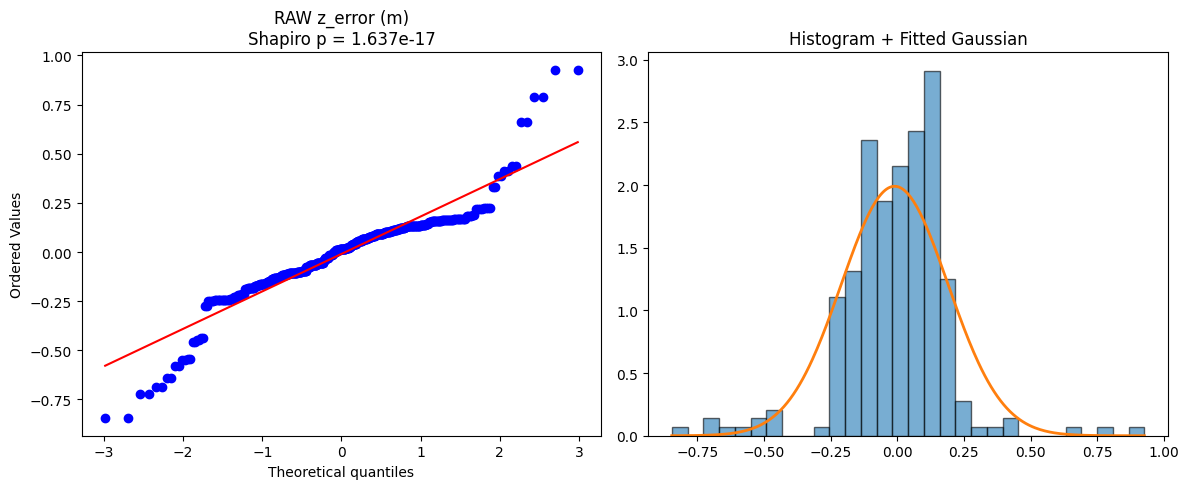

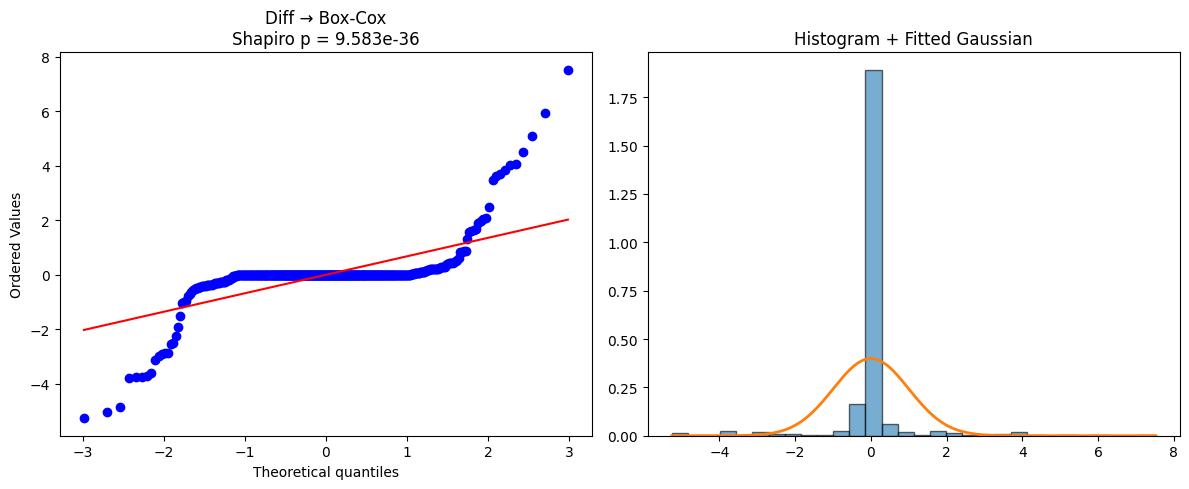

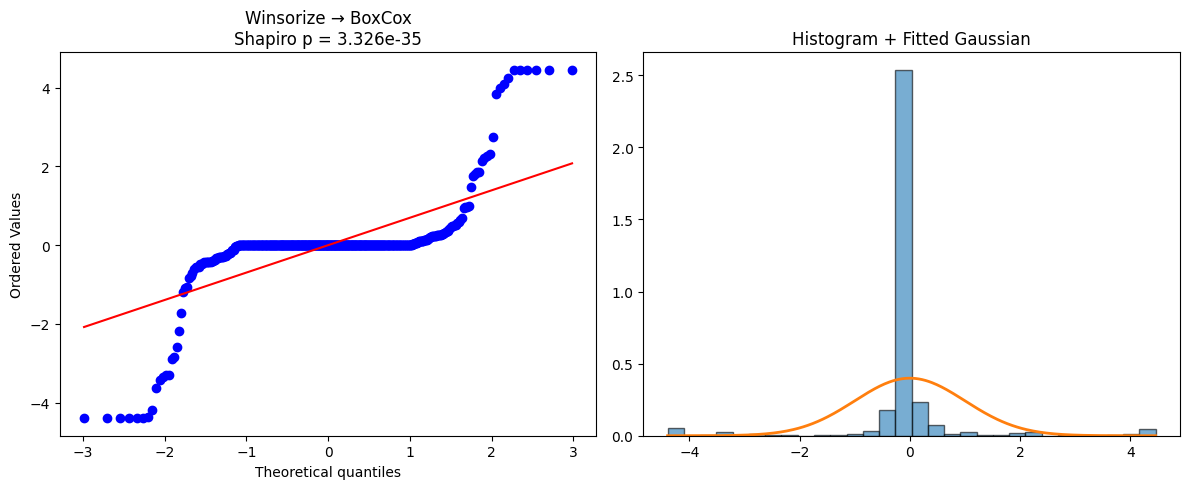

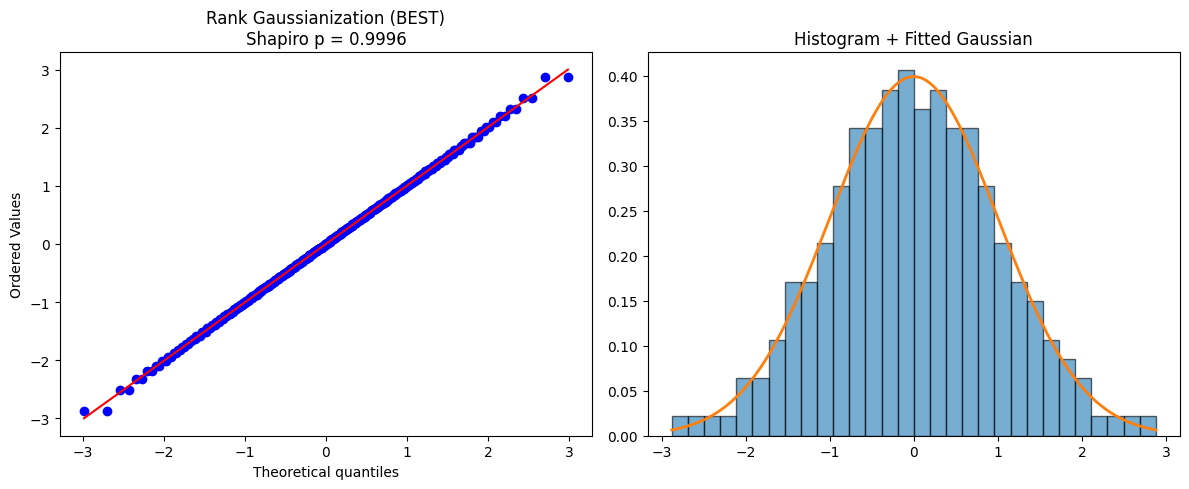

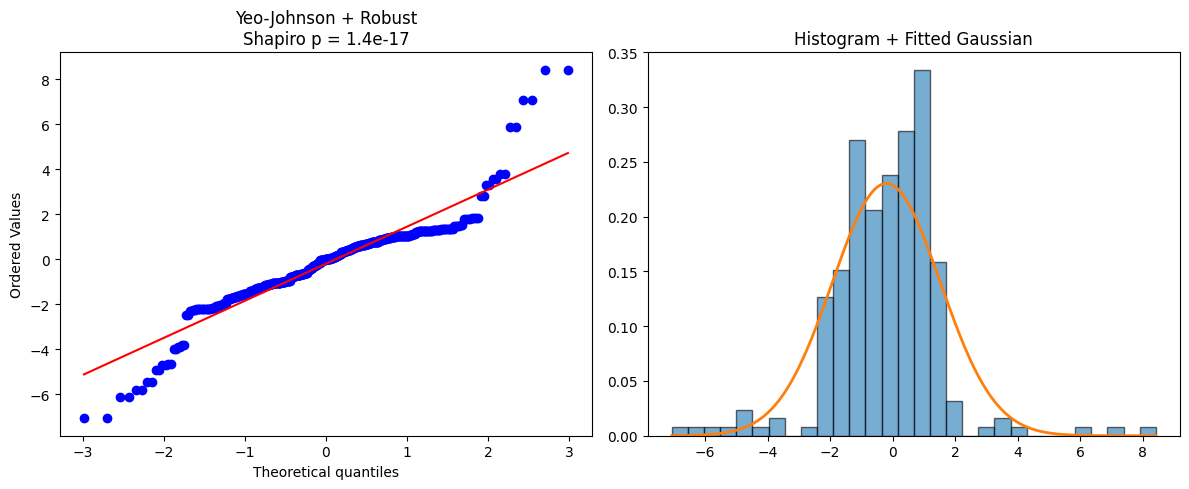

In [ ]:
# ============================================================
# RAW
# ============================================================
series_z = df["z_error (m)"].dropna().astype(float)
diff_z = series_z.diff().dropna()

stat_raw_z, p_raw_z = shapiro_safe(series_z)
qq_hist_with_curve(series_z, "RAW z_error (m)", p_raw_z)

# ============================================================
# DIFF → BOXCOX
# ============================================================
shift_z = 0 if diff_z.min() > 0 else abs(diff_z.min()) + 1e-9

try:
    bc1_z, lam1_z = st.boxcox(diff_z + shift_z)
    bc1_z_std = (bc1_z - bc1_z.mean()) / bc1_z.std()
    stat1_z, p1_z = shapiro_safe(bc1_z_std)
    qq_hist_with_curve(bc1_z_std, "Diff → Box-Cox", p1_z)
except:
    pass

# ============================================================
# WINSORIZE → BOXCOX
# ============================================================
arr_w_z = winsorize(diff_z.values, limits=(0.01, 0.01)).data
shift2_z = 0 if arr_w_z.min() > 0 else abs(arr_w_z.min()) + 1e-9

bc2_z, lam2_z = st.boxcox(arr_w_z + shift2_z)
bc2_z_std = (bc2_z - bc2_z.mean()) / bc2_z.std()
stat2_z, p2_z = shapiro_safe(bc2_z_std)
qq_hist_with_curve(bc2_z_std, "Winsorize → BoxCox", p2_z)

# ============================================================
# RANK GAUSSIANIZATION
# ============================================================
x_z = series_z.values
ranks_z = st.rankdata(x_z)
u_z = (ranks_z - 0.5) / len(x_z)
rank_gauss_z = st.norm.ppf(u_z)
rank_gauss_z = (rank_gauss_z - rank_gauss_z.mean()) / rank_gauss_z.std()

stat4_z, p4_z = shapiro_safe(rank_gauss_z)
qq_hist_with_curve(rank_gauss_z, "Rank Gaussianization (BEST)", p4_z)

# ============================================================
# YEO-JOHNSON + ROBUST SCALING
# ============================================================
pt_z = PowerTransformer(method="yeo-johnson", standardize=False)
yj_z = pt_z.fit_transform(series_z.values.reshape(-1,1)).flatten()

med_z = np.median(yj_z)
mad_z = np.median(np.abs(yj_z - med_z))
yj_robust_z = (yj_z - med_z) / (mad_z if mad_z > 1e-9 else 1)

stat5_z, p5_z = shapiro_safe(yj_robust_z)
qq_hist_with_curve(yj_robust_z, "Yeo-Johnson + Robust", p5_z)


In [ ]:
# ===============================
# LOAD FEATURE
# ===============================
series_sc = df["satclockerror (m)"].dropna().astype(float)

print("\n================ STEP 1 — DIAGNOSE RAW FEATURE (satclockerror) ================\n")
print("n =", len(series_sc))
print("unique values =", series_sc.nunique())
print("\nTop 10 repeated values:")
print(series_sc.value_counts().head(10))
print("\nPercentiles:")
print(np.percentile(series_sc, [0,1,5,50,95,99,100]))

# ==========================================================
# EXPERIMENT 1 — First Difference
# ==========================================================
diff_series_sc = series_sc.diff().dropna()

print("\n================ EXPERIMENT 1 — First Difference Diagnostics (satclockerror) ================\n")
print("n_diff:", len(diff_series_sc))
print("unique:", diff_series_sc.nunique())
print("percentiles:", np.percentile(diff_series_sc, [0,1,5,50,95,99,100]))

if diff_series_sc.nunique() <= 2:
    print("WARNING: First-difference collapses into few unique values → plateau inevitable.")

# Safe Box-Cox
try:
    shift = 0 if diff_series_sc.min() > 0 else abs(diff_series_sc.min()) + 1e-9
    diff_shift = diff_series_sc + shift
    bc1_sc, lam1_sc = st.boxcox(diff_shift)
    bc1_sc_std = (bc1_sc - bc1_sc.mean()) / bc1_sc.std()
    stat1_sc, p1_sc = shapiro_safe(bc1_sc_std)
except:
    lam1_sc, p1_sc = None, 0
    print("Box-Cox failed due to ties or non-positive values.")

print("\nBox-Cox λ:", lam1_sc)
print("Shapiro p (after Box-Cox on diff):", p1_sc)

# ==========================================================
# EXPERIMENT 2 — AR(1) residual → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 2 — AR(1) Residual → Box-Cox (satclockerror) ================\n")

if "satclockerror (m)_ar1_resid" not in df.columns:
    print("AR(1) residual column not found — skip.")
    bc2_sc_std, p2_sc = None, None
else:
    resid_sc = df["satclockerror (m)_ar1_resid"].dropna().astype(float)
    print("n_AR1 residual:", len(resid_sc))
    print("unique:", resid_sc.nunique())

    shift = 0 if resid_sc.min() > 0 else abs(resid_sc.min()) + 1e-9
    r_sc = resid_sc + shift
    try:
        bc2_sc, lam2_sc = st.boxcox(r_sc)
        bc2_sc_std = (bc2_sc - bc2_sc.mean()) / bc2_sc.std()
        stat2_sc, p2_sc = shapiro_safe(bc2_sc_std)
        print("λ_AR1:", lam2_sc)
        print("Shapiro p:", p2_sc)
    except:
        print("Box-Cox failed on AR1 residuals.")
        p2_sc = 0

# ==========================================================
# EXPERIMENT 3 — Winsorize → Box-Cox
# ==========================================================
print("\n================ EXPERIMENT 3 — Winsorize 1% → Box-Cox (satclockerror) ================\n")

arr_sc = diff_series_sc.values
arr_w_sc = winsorize(arr_sc, limits=(0.01, 0.01)).data

shift = 0 if arr_w_sc.min() > 0 else abs(arr_w_sc.min()) + 1e-9
try:
    bc3_sc, lam3_sc = st.boxcox(arr_w_sc + shift)
    bc3_sc_std = (bc3_sc - bc3_sc.mean()) / bc3_sc.std()
    stat3_sc, p3_sc = shapiro_safe(bc3_sc_std)
    print("λ_winsor:", lam3_sc)
    print("Shapiro p (winsor):", p3_sc)
except:
    print("Winsorized Box-Cox failed.")
    p3_sc = 0

# ==========================================================
# EXPERIMENT 4 — Rank Gaussianization
# ==========================================================
print("\n================ EXPERIMENT 4 — Rank Gaussianization (satclockerror) ================\n")

x_sc = series_sc.values
ranks_sc = st.rankdata(x_sc)
u_sc = (ranks_sc - 0.5) / len(x_sc)
rank_gauss_sc = st.norm.ppf(u_sc)
rank_gauss_sc_std = (rank_gauss_sc - rank_gauss_sc.mean()) / rank_gauss_sc.std()
stat4_sc, p4_sc = shapiro_safe(rank_gauss_sc_std)

print("Shapiro p (rank-gauss):", p4_sc)

# ==========================================================
# EXPERIMENT 5 — Yeo-Johnson + Robust Scaling
# ==========================================================
print("\n================ EXPERIMENT 5 — Yeo-Johnson + Robust Scaling (satclockerror) ================\n")

pt_sc = PowerTransformer(method="yeo-johnson", standardize=False)
yj_sc = pt_sc.fit_transform(series_sc.values.reshape(-1,1)).flatten()

med_sc = np.median(yj_sc)
mad_sc = np.median(np.abs(yj_sc - med_sc))
yj_robust_sc = (yj_sc - med_sc) / (mad_sc if mad_sc > 1e-9 else 1)

stat5_sc, p5_sc = shapiro_safe(yj_robust_sc)

print("Yeo-Johnson λ:", pt_sc.lambdas_[0])
print("Shapiro p (YJ+robust):", p5_sc)

# ==========================================================
# FINAL SUMMARY
# ==========================================================
print("\n================ FINAL SUMMARY (All Experiments, satclockerror) ================\n")

print(f"1) Diff → Box-Cox:            p = {p1_sc}")
print(f"2) AR1 Residual → Box-Cox:    p = {p2_sc}")
print(f"3) Winsorize → Box-Cox:       p = {p3_sc}")
print(f"4) Rank Gaussianization:      p = {p4_sc}")
print(f"5) Yeo-Johnson + Robust:      p = {p5_sc}")

print("\nVerdict:")
best_sc = max([p for p in [p1_sc,p2_sc,p3_sc,p4_sc,p5_sc] if p is not None])
if best_sc > 0.05:
    print("✔ At least one transformation achieved normality.")
    if best_sc == p4_sc:
        print("   → Best method: Rank Gaussianization")
    elif best_sc == p5_sc:
        print("   → Best method: Yeo-Johnson + robust")
else:
    print("❌ None reached p>0.05 → Feature is intrinsically non-Gaussian (likely multimodal).")
    print("Next step: Gaussian Mixture modeling (GMM) is recommended.")


================ STEP 1 — DIAGNOSE RAW FEATURE (satclockerror) ================

n = 488
unique values = 70

Top 10 repeated values:
satclockerror (m)
-0.006356    62
-0.008911    50
 0.008539    32
 0.011094    30
-0.011465    24
-0.026361    18
 0.025990    14
-0.008911    12
 0.028544    12
-0.026361    12
Name: count, dtype: int64

Percentiles:
[-0.14284028 -0.07939589 -0.03357625 -0.0063565   0.03622464  0.09036905
  0.18457214]

================ EXPERIMENT 1 — First Difference Diagnostics (satclockerror) ================

n_diff: 487
unique: 97
percentiles: [-0.19348287 -0.08491888 -0.02452551  0.          0.01745026  0.09941837
  0.16579773]

Box-Cox λ: 1.142939662635349
Shapiro p (after Box-Cox on diff): 1.4341214117997638e-34

================ EXPERIMENT 2 — AR(1) Residual → Box-Cox (satclockerror) ================

AR(1) residual column not found — skip.

================ EXPERIMENT 3 — Winsorize 1% → Box-Cox (satclockerror) ================

λ_winsor: 0.8730842045974501
Sha

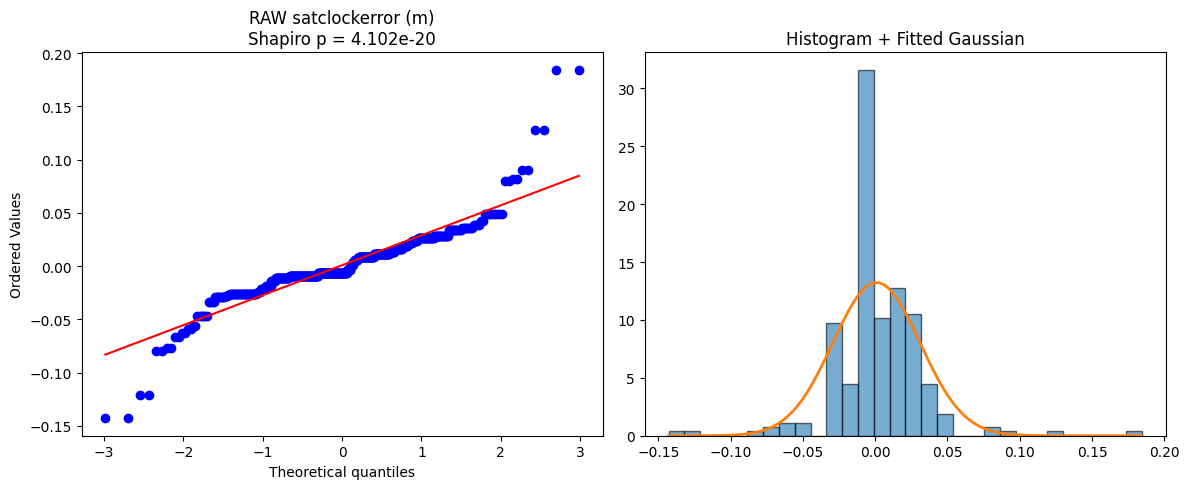

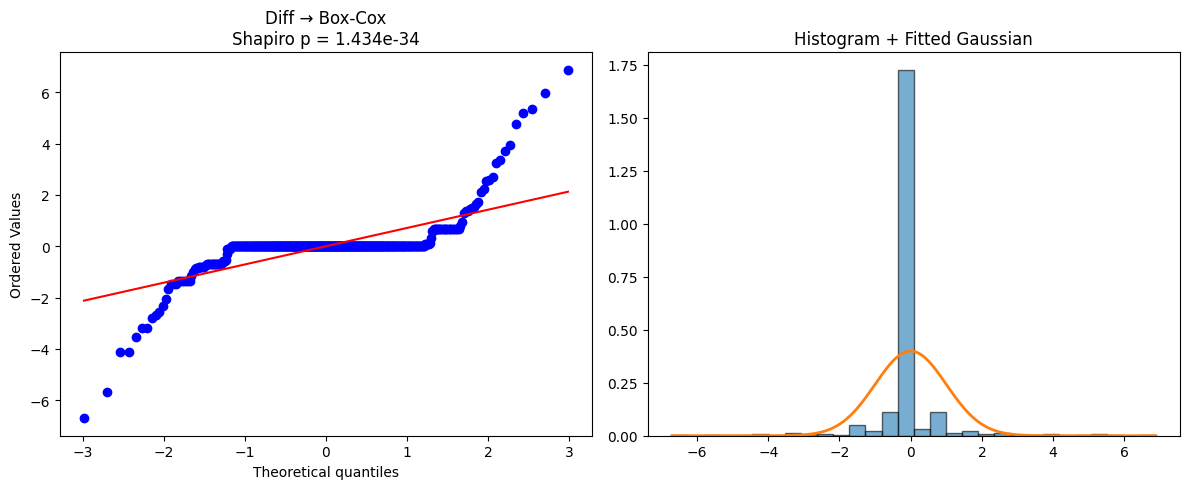

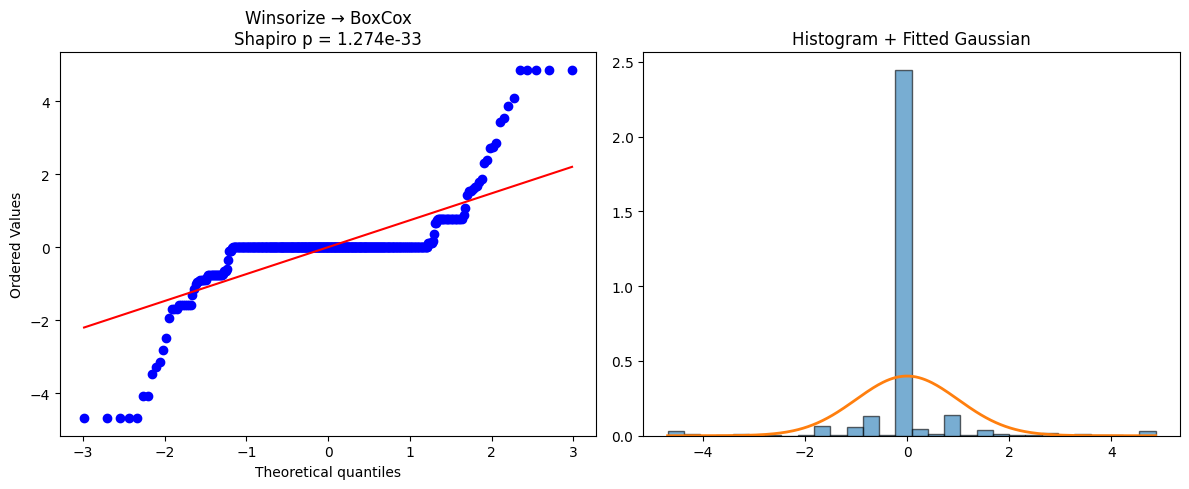

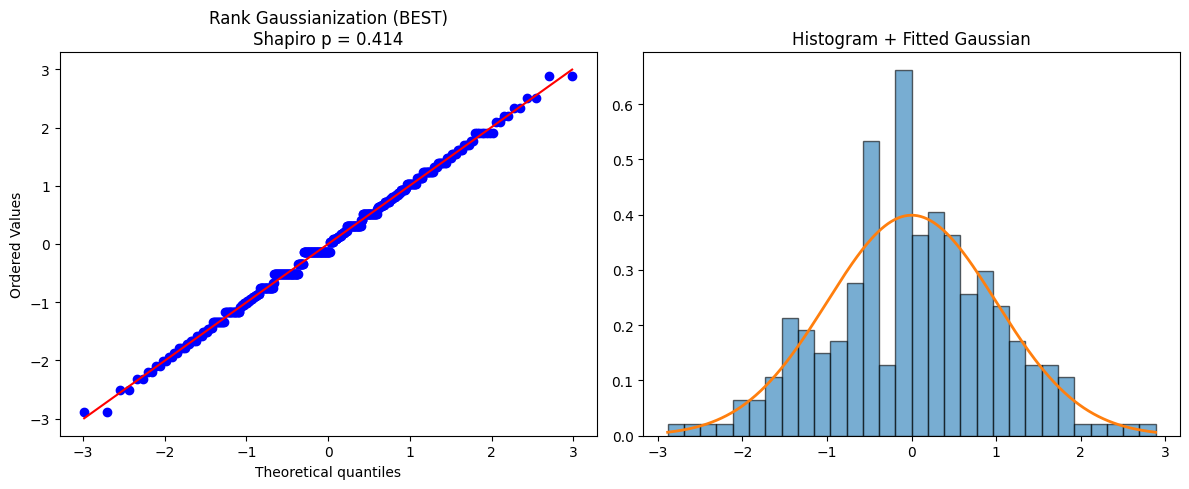

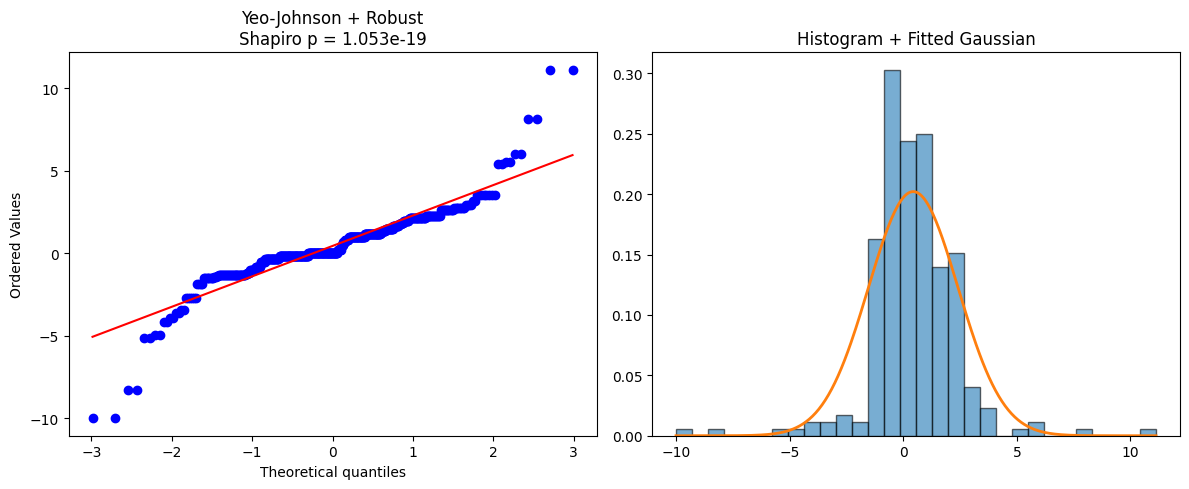

In [ ]:
# ============================================================
# RAW
# ============================================================
series_sc = df["satclockerror (m)"].dropna().astype(float)
diff_sc = series_sc.diff().dropna()

stat_raw_sc, p_raw_sc = shapiro_safe(series_sc)
qq_hist_with_curve(series_sc, "RAW satclockerror (m)", p_raw_sc)

# ============================================================
# DIFF → BOXCOX
# ============================================================
shift_sc = 0 if diff_sc.min() > 0 else abs(diff_sc.min()) + 1e-9

try:
    bc1_sc, lam1_sc = st.boxcox(diff_sc + shift_sc)
    bc1_sc_std = (bc1_sc - bc1_sc.mean()) / bc1_sc.std()
    stat1_sc, p1_sc = shapiro_safe(bc1_sc_std)
    qq_hist_with_curve(bc1_sc_std, "Diff → Box-Cox", p1_sc)
except:
    pass

# ============================================================
# WINSORIZE → BOXCOX
# ============================================================
arr_w_sc = winsorize(diff_sc.values, limits=(0.01, 0.01)).data
shift2_sc = 0 if arr_w_sc.min() > 0 else abs(arr_w_sc.min()) + 1e-9

bc2_sc, lam2_sc = st.boxcox(arr_w_sc + shift2_sc)
bc2_sc_std = (bc2_sc - bc2_sc.mean()) / bc2_sc.std()
stat2_sc, p2_sc = shapiro_safe(bc2_sc_std)
qq_hist_with_curve(bc2_sc_std, "Winsorize → BoxCox", p2_sc)

# ============================================================
# RANK GAUSSIANIZATION
# ============================================================
x_sc = series_sc.values
ranks_sc = st.rankdata(x_sc)
u_sc = (ranks_sc - 0.5) / len(x_sc)
rank_gauss_sc = st.norm.ppf(u_sc)
rank_gauss_sc = (rank_gauss_sc - rank_gauss_sc.mean()) / rank_gauss_sc.std()

stat4_sc, p4_sc = shapiro_safe(rank_gauss_sc)
qq_hist_with_curve(rank_gauss_sc, "Rank Gaussianization (BEST)", p4_sc)

# ============================================================
# YEO-JOHNSON + ROBUST SCALING
# ============================================================
pt_sc = PowerTransformer(method="yeo-johnson", standardize=False)
yj_sc = pt_sc.fit_transform(series_sc.values.reshape(-1,1)).flatten()

med_sc = np.median(yj_sc)
mad_sc = np.median(np.abs(yj_sc - med_sc))
yj_robust_sc = (yj_sc - med_sc) / (mad_sc if mad_sc > 1e-9 else 1)

stat5_sc, p5_sc = shapiro_safe(yj_robust_sc)
qq_hist_with_curve(yj_robust_sc, "Yeo-Johnson + Robust", p5_sc)


In [ ]:
# Add the rank-Gaussianized features to the dataframe
df["x_error_gauss"] = rank_gauss      # from your previous x_error rank-gauss
df["y_error_gauss"] = rank_gauss_y    # from y_error rank-gauss
df["z_error_gauss"] = rank_gauss_z    # from z_error rank-gauss
df["satclockerror_gauss"] = rank_gauss_sc  # from satclockerror rank-gauss

# Save to CSV
df.to_csv("/content/Dataset/Guassianized_MEO_features.csv", index=False)

print("✅ Gaussianized features added and saved to 'Guassianized_MEO_features'.")

✅ Gaussianized features added and saved to 'Guassianized_MEO_features'.


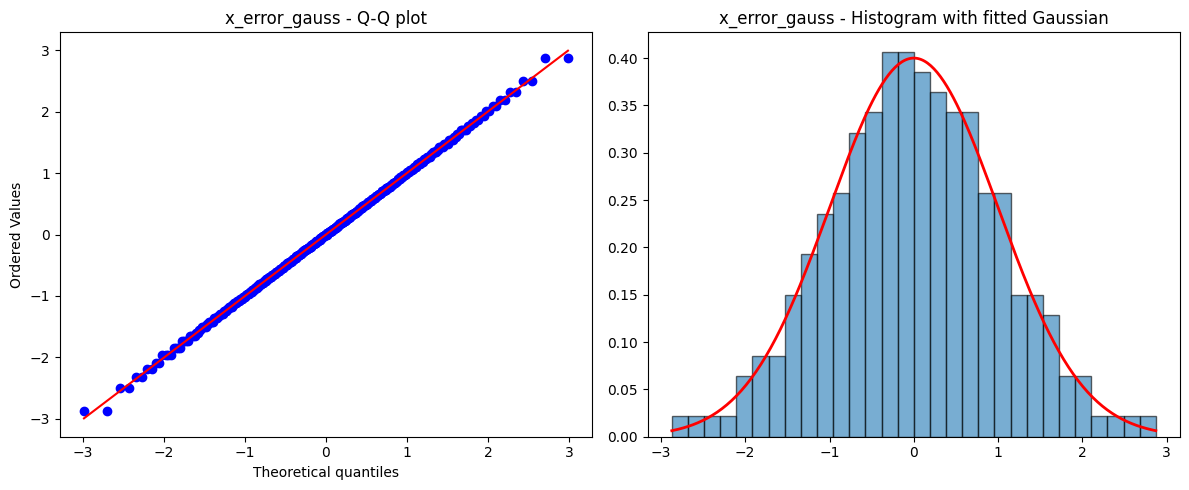

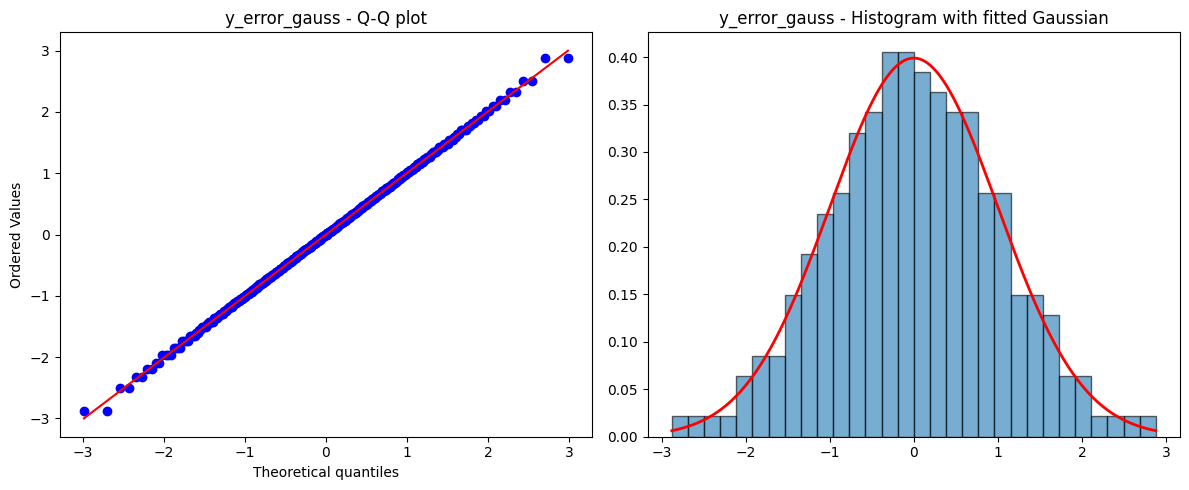

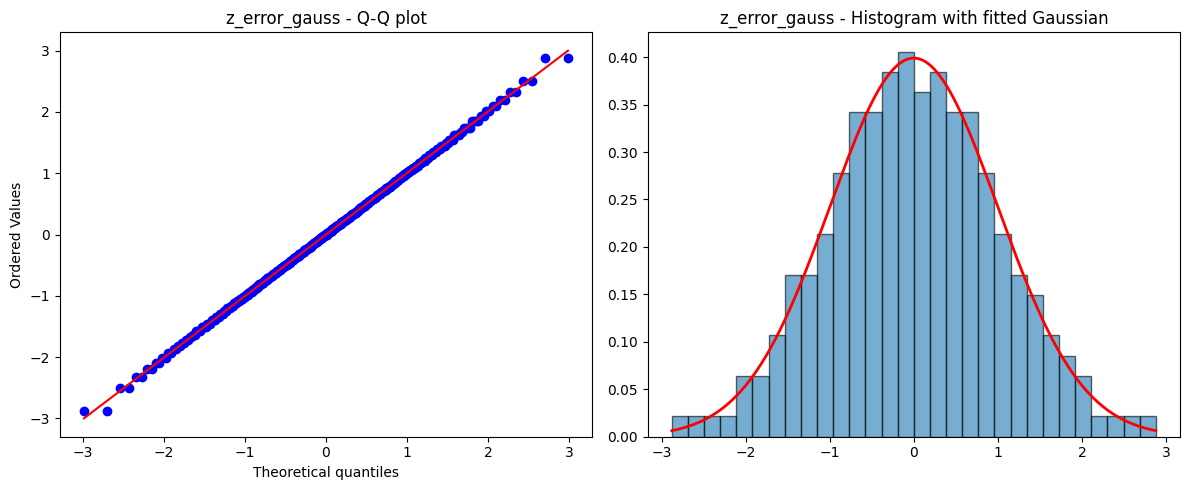

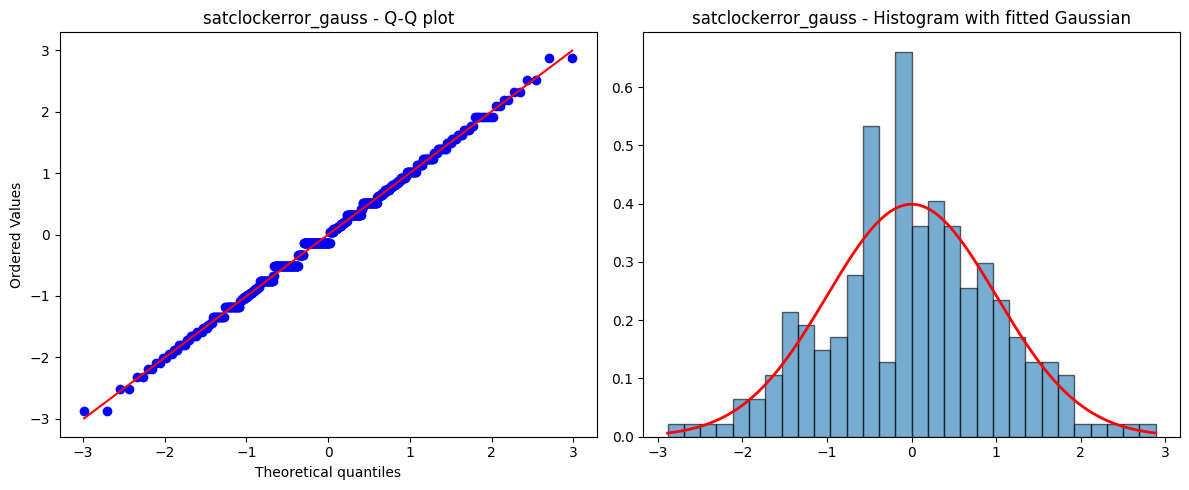

Outlier counts (|z| > 3) for Gaussianized features:
x_error_gauss: 0 outliers
y_error_gauss: 0 outliers
z_error_gauss: 0 outliers
satclockerror_gauss: 0 outliers


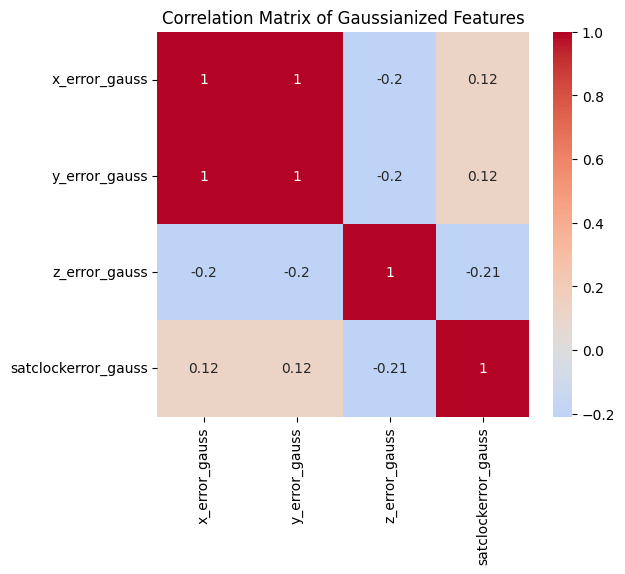

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

df=pd.read_csv("/content/Dataset/Guassianized_MEO_features.csv")
# List of Gaussianized features
gauss_features = ["x_error_gauss", "y_error_gauss", "z_error_gauss", "satclockerror_gauss"]

# 1️⃣ Histograms + Q-Q plots for all Gaussianized features
for feat in gauss_features:
    data = df[feat].dropna().values
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Q-Q plot
    st.probplot(data, dist="norm", plot=ax[0])
    ax[0].set_title(f"{feat} - Q-Q plot")

    # Histogram + Gaussian curve
    ax[1].hist(data, bins=30, density=True, alpha=0.6, edgecolor="black")
    mu, sigma = np.mean(data), np.std(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    ax[1].plot(x_vals, st.norm.pdf(x_vals, mu, sigma), 'r', lw=2)
    ax[1].set_title(f"{feat} - Histogram with fitted Gaussian")

    plt.tight_layout()
    plt.show()

# 2️⃣ Outlier check (using 3-sigma rule)
print("Outlier counts (|z| > 3) for Gaussianized features:")
for feat in gauss_features:
    data = df[feat].dropna().values
    outliers = np.sum(np.abs(data) > 3)
    print(f"{feat}: {outliers} outliers")

# 3️⃣ Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[gauss_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Gaussianized Features")
plt.show()


In [ ]:
import numpy as np
import pandas as pd

def mad_zscore_filter(df, col, threshold=3.5):
    """
    Removes outliers using Median Absolute Deviation (MAD) z-score.

    Why this works well for GNSS error signals:
    -------------------------------------------
    - GNSS errors are heavy-tailed (non-Gaussian), so SD-based z-scores fail.
    - MAD is robust: 50% breakdown point (cannot be distorted by extreme points).
    - Scaling factor 1.4826 makes MAD comparable to standard deviation *only if*
      the underlying distribution becomes approximately Gaussian later.
    - threshold=3.5 is recommended for scientific signals with long tails
      (Leys et al., 2013).

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing the error column.
    col : str
        Name of the column containing the GNSS error values.
    threshold : float
        MAD-Z cutoff (3.5 = strong, 4-5 = extremely conservative)

    Returns
    -------
    cleaned_df : pd.DataFrame
        Dataframe with outliers removed.
    stats : dict
        Diagnostic statistics (median, MAD, % removed).
    """

    # Extract signal
    x = df[col].astype(float).values

    # Step 1: Compute median (robust center)
    median = np.median(x)

    # Step 2: Compute MAD (Median Absolute Deviation)
    mad = np.median(np.abs(x - median))

    # If MAD becomes zero (happens when most values identical)
    if mad == 0:
        # fallback to a tiny epsilon to avoid divide-by-zero
        mad = 1e-9

    # Step 3: Robust scaled deviation (MAD-Z score)
    # 1.4826 = consistency constant → makes MAD estimate σ if Gaussian later
    mad_z = 0.67448975 * (x - median) / mad   # 0.67449 = inverse CDF(0.75)

    # Step 4: Identify inliers
    mask = np.abs(mad_z) <= threshold

    cleaned_df = df[mask].copy()

    # Diagnostics
    stats = {
        "median": median,
        "mad": mad,
        "threshold": threshold,
        "original_count": len(df),
        "kept_count": mask.sum(),
        "removed_count": (~mask).sum(),
        "percent_removed": 100 * (1 - mask.mean())
    }

    return cleaned_df, stats
clean_df, stats = mad_zscore_filter(df, "x_error (m)", threshold=3.5)
print(stats)


{'median': np.float64(-0.14137566000000001), 'mad': np.float64(0.09754187900000001), 'threshold': 3.5, 'original_count': 334, 'kept_count': np.int64(289), 'removed_count': np.int64(45), 'percent_removed': np.float64(13.47305389221557)}


In [ ]:
from scipy.stats import yeojohnson
import numpy as np
import pandas as pd

def yeojohnson_transform(df, col):
    """
    Applies the Yeo-Johnson variance-stabilizing transform to the specified column.
    This handles negative values and heavy tails — ideal for GNSS error signals.

    Returns transformed df + diagnostics (lambda, skew before/after).
    """

    # Extract clean numeric values
    x = df[col].astype(float).values

    # Diagnostics BEFORE transformation
    skew_before = pd.Series(x).skew()

    # Apply Yeo-Johnson transform
    x_transformed, lam = yeojohnson(x)

    # Diagnostics AFTER transformation
    skew_after = pd.Series(x_transformed).skew()

    # Create output df
    out = df.copy()
    out[col + "_yj"] = x_transformed

    stats = {
        "lambda": lam,
        "skew_before": float(skew_before),
        "skew_after": float(skew_after),
        "improvement": abs(skew_before) - abs(skew_after)
    }

    return out, stats
df2, stats_yj = yeojohnson_transform(clean_df, "x_error (m)")
stats_yj


{'lambda': np.float64(-0.32171062146680246),
 'skew_before': 0.6373609628674628,
 'skew_after': 0.09312520862238285,
 'improvement': np.float64(0.54423575424508)}

=== GNSS AR(1) Whitening Pipeline (DEBUG) ===
[i] Attempting to load file: /content/Dataset/MEOwithResiduals.csv
[i] Loaded 90 rows, columns: ['utc_time', 'x_error (m)', 'y_error  (m)', 'z_error (m)', 'satclockerror (m)', 'residual']
[i] Using column: x_error (m)
[i] Basic stats: {'median': -0.624093685, 'mean': -0.5802988988444444, 'std': 0.3229354327241713, 'n_nonnull': 90}
[i] ACF lag1: 0.4237, lag2: 0.0275
[i] Plotting original series and ACF/PACF (before)...


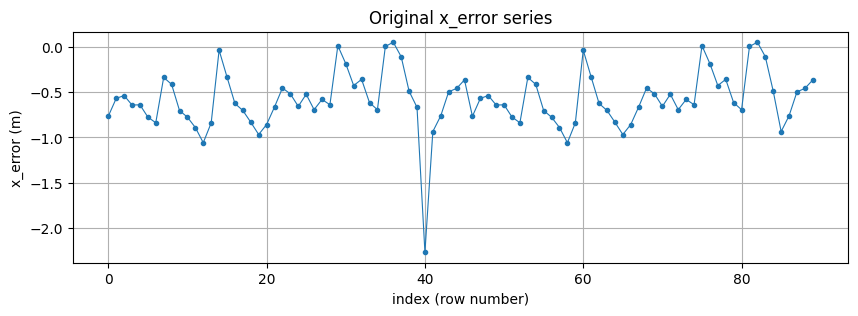

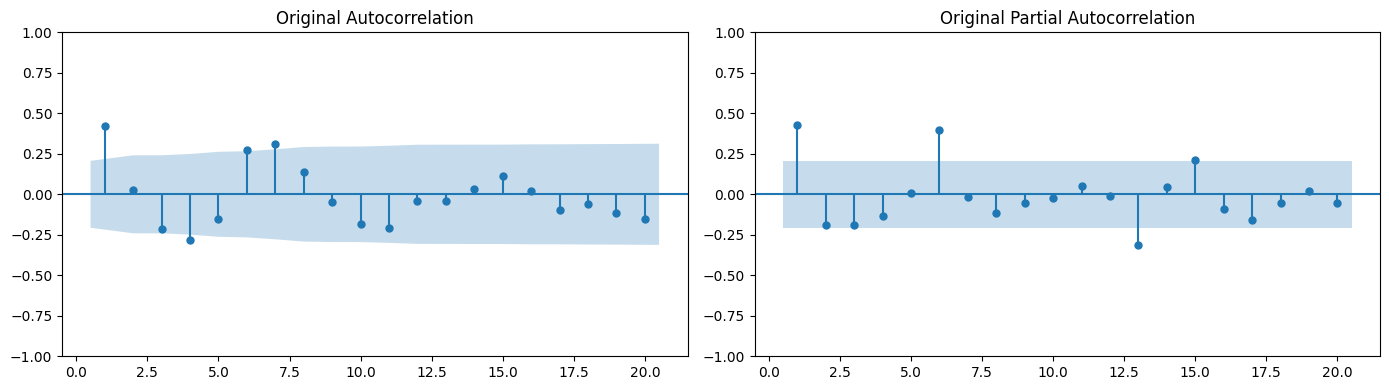

[i] Fitting AR(1) and whitening...
[i] AR diag: {'params': {'const': 0.00312537565847377, 'x_error (m).L1': 0.42591977277352666}, 'phi': 0.42591977277352666, 'sigma2': 0.08507482177903662, 'aic': 39.255109251943104, 'nobs': 89, 'method': 'AutoReg_default_fit'}
[i] Residual basic stats: {'median': -0.03225924378704911, 'mean': 9.043951605092568e-18, 'std': 0.29332845262168955, 'n_nonnull': 89}
[i] Plotting AR(1) residuals (whitened) and ACF/PACF (after)...


/tmp/ipython-input-2364321267.py:194: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "phi": float(res.params[-1]) if len(res.params) > 0 else np.nan,


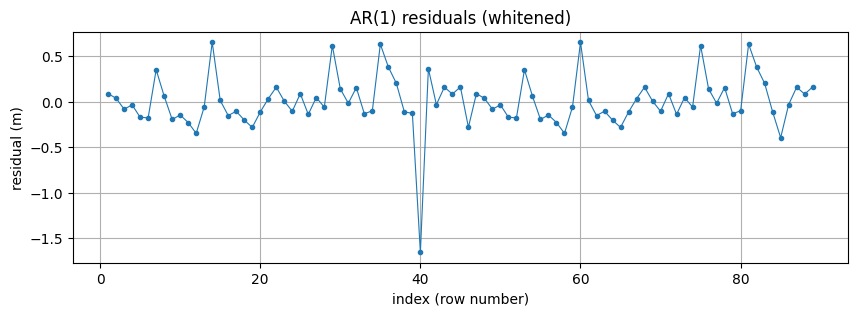

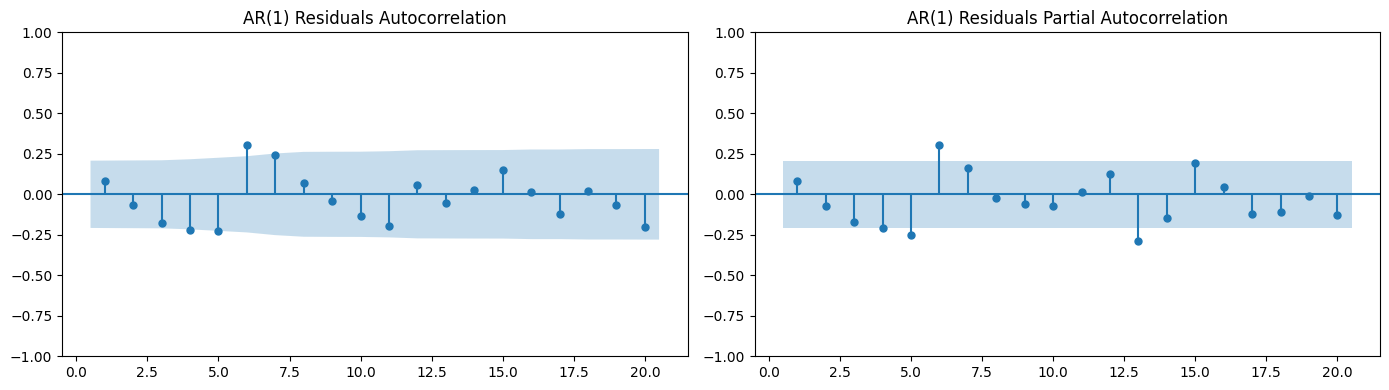

[i] Running ADF test on residuals...
[i] ADF residuals: stat=-3.8207, p=0.0027, verdict=stationary
[i] Saved whitened feature to: /content/Dataset/gnss_xerror_whitened_debug.csv

Diagnostics summary:
 - file_path: /content/Dataset/MEOwithResiduals.csv
 - used_col: x_error (m)
 - original_len: 90
 - basic_stats: {'median': -0.624093685, 'mean': -0.5802988988444444, 'std': 0.3229354327241713, 'n_nonnull': 90}
 - acf_before: {'lag1': 0.4236787363120272, 'lag2': 0.027516378861867065, 'n': 90}
 - ar1_diag: {'params': {'const': 0.00312537565847377, 'x_error (m).L1': 0.42591977277352666}, 'phi': 0.42591977277352666, 'sigma2': 0.08507482177903662, 'aic': 39.255109251943104, 'nobs': 89, 'method': 'AutoReg_default_fit'}
 - resid_basic_stats: {'median': -0.03225924378704911, 'mean': 9.043951605092568e-18, 'std': 0.29332845262168955, 'n_nonnull': 89}
 - adf_resid: {'adf_stat': -3.8207017977089976, 'pvalue': 0.002702470211374872, 'usedlag': 5, 'nobs': 83, 'critvalues': {'1%': -3.5117123057187376, '

In [ ]:
"""
Debug/Teaching GNSS AR(1) Whitening Pipeline
-------------------------------------------------
This is the **debug/teaching** variant you requested (option B).
It is verbose, heavily commented, prints intermediate diagnostics,
and is safe to run in a notebook / script.

Default file path is set to the CSV the conversation used earlier:
    /content/Dataset/MEOwithResiduals.csv

What this script does (single-shot):
 1. Load tabular GNSS data (CSV/parquet/feather)
 2. Extract `x_error (m)` robustly
 3. Plot original series + ACF/PACF (with safe method choices)
 4. Fit AR(1) (AutoReg) to whiten the series; robust fallback if fit fails
 5. Plot residuals + ACF/PACF after whitening
 6. Run ADF test on residuals and report stationarity
 7. Save an output CSV with new column `<col>_ar1_resid`

Notes:
 - This version prints detailed diagnostics and warnings for teaching.
 - It avoids method-name incompatibilities by choosing stable defaults and
   providing safe fallbacks when a statsmodels method is unavailable.

Usage:
    python gnss_ar1_whitening_debug.py
    # or import the functions and call `gnss_ar1_whitening_pipeline()`

"""

import os
import warnings
from typing import Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -------------------------
# Utility / Robust loaders
# -------------------------

def load_gnss_table(file_path: str, verbose: bool = True) -> pd.DataFrame:
    """
    Robust loader for GNSS tabular files. Accepts CSV / parquet / feather.
    Raises a clear error for non-tabular files (images, etc.).
    """
    if verbose:
        print(f"[i] Attempting to load file: {file_path}")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    ext = os.path.splitext(file_path)[1].lower()
    if ext in {".csv", ".txt"}:
        df = pd.read_csv(file_path)
    elif ext in {".parquet"}:
        df = pd.read_parquet(file_path)
    elif ext in {".feather"}:
        df = pd.read_feather(file_path)
    else:
        raise ValueError(
            f"Unsupported or non-tabular file extension '{ext}'. Provide CSV / parquet / feather containing GNSS columns."
        )
    if verbose:
        print(f"[i] Loaded {len(df)} rows, columns: {list(df.columns)}")
    return df

# -------------------------
# Column extractor
# -------------------------

def extract_x_error_column(df: pd.DataFrame) -> Tuple[pd.Series, str]:
    """
    Try multiple likely column names for the x-error column and return (Series, name).
    """
    candidates = [
        "x_error (m)",
        "x_error",
        "x_error_m",
        "x_err",
        "xerror",
        "X_error (m)",
        "x_error ( m )",
    ]
    for c in candidates:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().sum() == 0:
                continue
            return s.reset_index(drop=True), c
    # fallback: case-insensitive containment
    for c in df.columns:
        if "x" in c.lower() and "error" in c.lower():
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().sum() > 0:
                return s.reset_index(drop=True), c
    raise KeyError("Could not find an x_error column. Provide a column named like 'x_error (m)'.")

# -------------------------
# ACF / PACF diagnostics (safe methods)
# -------------------------

def compute_acf_pacf(series: pd.Series, nlags: int = 30, fft: bool = False) -> Dict[str, Any]:
    """
    Compute ACF and PACF with stable default methods. Returns arrays and lag summary.
    Uses 'acf' from statsmodels and attempts PACF with 'yw' first, then falls back to 'ols'.
    """
    clean = series.dropna().astype(float)
    n = len(clean)
    if n < 10:
        warnings.warn("Very small sample size for ACF/PACF (<10). Interpret results cautiously.")
    nlags = min(max(1, n - 1), nlags)

    acf_vals = acf(clean, nlags=nlags, fft=fft, missing="conservative")

    # PACF - try a robust method then fallback
    try:
        pacf_vals = pacf(clean, nlags=nlags, method="yw")
    except Exception:
        try:
            pacf_vals = pacf(clean, nlags=nlags, method="ols")
        except Exception:
            # last resort: use numpy-based partial autocorr (very simple)
            warnings.warn("PACF methods failed; filling with NaNs")
            pacf_vals = np.full(nlags + 1, np.nan)

    return {
        "n": n,
        "acf": np.asarray(acf_vals),
        "pacf": np.asarray(pacf_vals),
        "lag1": float(acf_vals[1]) if len(acf_vals) > 1 else np.nan,
        "lag2": float(acf_vals[2]) if len(acf_vals) > 2 else np.nan,
    }


def plot_acf_pacf(series: pd.Series, nlags: int = 30, title_prefix: str = ""):
    """
    Plot ACF and PACF side-by-side using plotting functions.
    Use 'ols' for PACF plotting (widely accepted across statsmodels versions).
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series.dropna(), lags=nlags, ax=axes[0], zero=False)
    # use method='ols' for plot_pacf to avoid version mismatches
    try:
        plot_pacf(series.dropna(), lags=nlags, ax=axes[1], zero=False, method="ols")
    except TypeError:
        # older/newer statsmodels might not accept method kwarg in plot_pacf signature
        plot_pacf(series.dropna(), lags=nlags, ax=axes[1], zero=False)
    axes[0].set_title(f"{title_prefix} Autocorrelation")
    axes[1].set_title(f"{title_prefix} Partial Autocorrelation")
    plt.tight_layout()
    plt.show()

# -------------------------
# AR(1) whitening (robust)
# -------------------------

def ar1_whiten(series: pd.Series, fit_intercept: bool = True, demean: bool = True) -> Tuple[pd.Series, Dict[str, Any]]:
    """
    Fit an AR(1) with AutoReg and return residuals (whitened series) + diagnostics.
    This function is robust: it tries AutoReg.fit() and falls back to a manual OLS phi estimate
    if the model fails for any reason.

    Returns:
       resid_series, diagnostics
    """
    s = series.astype(float).dropna().copy()
    if len(s) < 5:
        warnings.warn("Small sample (<5) for AR fit; results may be unstable.")

    # optionally demean to make the AR coefficient estimation more stable
    if demean:
        s_mean = s.mean()
        s_used = s - s_mean
    else:
        s_mean = 0.0
        s_used = s

    # Fit AutoReg with lag=1 (use default fit to avoid method-string mismatches)
    try:
        model = AutoReg(s_used, lags=1, old_names=False)
        res = model.fit()

        resid = res.resid.copy()
        # reindex residuals to align with original series
        resid_series = pd.Series(data=resid, index=s.index)

        diag = {
            "params": {k: float(v) for k, v in res.params.items()},
            "phi": float(res.params[-1]) if len(res.params) > 0 else np.nan,
            "sigma2": float(getattr(res, "sigma2", np.nan)),
            "aic": float(getattr(res, "aic", np.nan)),
            "nobs": int(getattr(res, "nobs", len(s))),
            "method": "AutoReg_default_fit",
        }
        return resid_series, diag

    except Exception as e:
        warnings.warn(f"AutoReg.fit() failed with error: {e}; falling back to OLS-style phi estimate.")
        # fallback OLS phi estimate: phi = sum(y_t * y_{t-1}) / sum(y_{t-1}^2)
        y = s_used.values
        if len(y) < 2:
            # cannot estimate phi
            resid = np.full_like(y, np.nan)
            resid_series = pd.Series(resid, index=s.index)
            diag = {"method": "fallback", "note": "insufficient data"}
            return resid_series, diag

        y_tm1 = y[:-1]
        y_t = y[1:]
        denom = np.dot(y_tm1, y_tm1)
        if denom == 0:
            phi = 0.0
        else:
            phi = np.dot(y_tm1, y_t) / denom

        # construct residuals: first residual is NaN (no lag), then y_t - phi*y_{t-1}
        resid = np.concatenate([[np.nan], y_t - phi * y_tm1])
        resid_series = pd.Series(resid, index=s.index)
        diag = {"phi": float(phi), "method": "fallback_ols"}
        return resid_series, diag

# -------------------------
# ADF stationarity test wrapper
# -------------------------

def adf_test(series: pd.Series) -> Dict[str, Any]:
    """
    Run Augmented Dickey-Fuller test and return results + a human-readable verdict.
    """
    clean = series.dropna().astype(float)
    if len(clean) < 10:
        warnings.warn("ADF test on very small sample (<10). p-values may be unreliable.")
    try:
        res = adfuller(clean, autolag="AIC")
    except Exception as e:
        warnings.warn(f"ADF test failed: {e}")
        return {"adf_stat": np.nan, "pvalue": np.nan, "verdict": "error"}

    stat, pvalue, usedlag, nobs, critvalues, icbest = res[0], res[1], res[2], res[3], res[4], res[5]
    verdict = "stationary" if pvalue < 0.05 else "non-stationary"
    return {
        "adf_stat": float(stat),
        "pvalue": float(pvalue),
        "usedlag": int(usedlag),
        "nobs": int(nobs),
        "critvalues": {k: float(v) for k, v in critvalues.items()},
        "verdict": verdict,
    }

# -------------------------
# Orchestrator: all-in-one (debug/teaching version)
# -------------------------

def gnss_ar1_whitening_pipeline(
    file_path: str,
    out_csv_path: str = "/content/Dataset/gnss_xerror_whitened_debug.csv",
    column_name: str = None,
    nlags: int = 30,
    plot: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Executes the full pipeline with lots of debug prints and plots.

    Returns: (df_out, diagnostics)
    """
    # 1) Load
    df = load_gnss_table(file_path, verbose=True)

    # 2) Extract x_error
    x_series, used_col = (
        extract_x_error_column(df)
        if column_name is None
        else (pd.to_numeric(df[column_name], errors="coerce").reset_index(drop=True), column_name)
    )
    print(f"[i] Using column: {used_col}")

    diagnostics: Dict[str, Any] = {"file_path": file_path, "used_col": used_col, "original_len": len(x_series)}

    # 3) Basic diagnostics
    diagnostics["basic_stats"] = {
        "median": float(x_series.median(skipna=True)),
        "mean": float(x_series.mean(skipna=True)),
        "std": float(x_series.std(skipna=True)),
        "n_nonnull": int(x_series.notna().sum()),
    }
    print(f"[i] Basic stats: {diagnostics['basic_stats']}")

    # 4) ACF/PACF before
    acf_pacf_before = compute_acf_pacf(x_series, nlags=nlags)
    diagnostics["acf_before"] = {"lag1": acf_pacf_before["lag1"], "lag2": acf_pacf_before["lag2"], "n": acf_pacf_before["n"]}
    print(f"[i] ACF lag1: {diagnostics['acf_before']['lag1']:.4f}, lag2: {diagnostics['acf_before']['lag2']:.4f}")

    if plot:
        print("[i] Plotting original series and ACF/PACF (before)...")
        plt.figure(figsize=(10, 3))
        plt.plot(x_series.index, x_series.values, marker=".", linewidth=0.8)
        plt.title("Original x_error series")
        plt.xlabel("index (row number)")
        plt.ylabel("x_error (m)")
        plt.grid(True)
        plt.show()

        plot_acf_pacf(x_series, nlags=nlags, title_prefix="Original")

    # 5) AR(1) whitening
    print("[i] Fitting AR(1) and whitening...")
    resid_series, ar_diag = ar1_whiten(x_series, fit_intercept=True, demean=True)
    diagnostics["ar1_diag"] = ar_diag
    print(f"[i] AR diag: {ar_diag}")

    # 6) Combine diagnostics and plot
    diagnostics["resid_basic_stats"] = {
        "median": float(resid_series.median(skipna=True)),
        "mean": float(resid_series.mean(skipna=True)),
        "std": float(resid_series.std(skipna=True)),
        "n_nonnull": int(resid_series.notna().sum()),
    }
    print(f"[i] Residual basic stats: {diagnostics['resid_basic_stats']}")

    if plot:
        print("[i] Plotting AR(1) residuals (whitened) and ACF/PACF (after)...")
        plt.figure(figsize=(10, 3))
        plt.plot(resid_series.index, resid_series.values, marker=".", linewidth=0.8)
        plt.title("AR(1) residuals (whitened)")
        plt.xlabel("index (row number)")
        plt.ylabel("residual (m)")
        plt.grid(True)
        plt.show()

        plot_acf_pacf(resid_series, nlags=nlags, title_prefix="AR(1) Residuals")

    # 7) ADF test on residuals
    print("[i] Running ADF test on residuals...")
    adf_resid = adf_test(resid_series)
    diagnostics["adf_resid"] = adf_resid
    print(f"[i] ADF residuals: stat={adf_resid['adf_stat']:.4f}, p={adf_resid['pvalue']:.4f}, verdict={adf_resid['verdict']}")

    # 8) Prepare cleaned DataFrame: original df with new column
    df_out = df.copy().reset_index(drop=True)
    resid_aligned = pd.Series(data=np.nan, index=df_out.index, dtype=float)
    resid_aligned.loc[resid_series.index] = resid_series.values
    new_col_name = used_col + "_ar1_resid"
    df_out[new_col_name] = resid_aligned

    # 9) Save to CSV
    try:
        df_out.to_csv(out_csv_path, index=False)
        diagnostics["saved_to"] = out_csv_path
        print(f"[i] Saved whitened feature to: {out_csv_path}")
    except Exception as e:
        diagnostics["saved_to"] = None
        warnings.warn(f"Could not save to {out_csv_path}: {e}")

    return df_out, diagnostics

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    default_path = "/content/Dataset/MEOwithResiduals.csv"  # <-- conversation file

    print("=== GNSS AR(1) Whitening Pipeline (DEBUG) ===")
    try:
        cleaned_df, diag = gnss_ar1_whitening_pipeline(
            default_path,
            out_csv_path="/content/Dataset/gnss_xerror_whitened_debug.csv",
            nlags=20,
            plot=True,
        )

        print("\nDiagnostics summary:")
        for k, v in diag.items():
            print(f" - {k}: {v}")
    except Exception as e:
        print("Pipeline failed with error:")
        print(e)
        print("\nIf this is because the default path is not a CSV, please pass the CSV file path to `gnss_ar1_whitening_pipeline`." )

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def boxcox_gaussianize(series, eps=1e-6):
    """
    Applies Box-Cox transform to make data approximately Gaussian.

    Parameters
    ----------
    series : pd.Series
        Input data (must be strictly positive, so we shift if needed)

    eps : float
        Tiny constant to avoid zero in case data touches 0

    Returns
    -------
    dict
        {
            "transformed": transformed_series,
            "lambda": λ parameter,
            "shift": amount added before transform,
            "skew_before": skewness before,
            "skew_after": skewness after,
            "improvement": reduction in absolute skewness
        }
    """

    x = series.dropna().values.astype(float)

    # ---------------------------------------------
    # Step 1: Ensure positivity for Box-Cox
    # ---------------------------------------------
    shift = 0
    if np.min(x) <= 0:
        shift = abs(np.min(x)) + eps
        x_shifted = x + shift
    else:
        x_shifted = x.copy()

    # ---------------------------------------------
    # Step 2: Compute skew BEFORE transform
    # ---------------------------------------------
    skew_before = stats.skew(x_shifted)

    # ---------------------------------------------
    # Step 3: Apply Box-Cox
    # ---------------------------------------------
    x_bc, lam = stats.boxcox(x_shifted)

    # ---------------------------------------------
    # Step 4: Compute skew AFTER transform
    # ---------------------------------------------
    skew_after = stats.skew(x_bc)

    # ---------------------------------------------
    # Step 5: Improvement metric
    # ---------------------------------------------
    improvement = abs(skew_before) - abs(skew_after)

    return {
        "transformed": pd.Series(x_bc, index=series.index),
        "lambda": lam,
        "shift": shift,
        "skew_before": skew_before,
        "skew_after": skew_after,
        "improvement": improvement
    }


def shapiro_test(series):
    """
    Runs Shapiro–Wilk normality test on the transformed data.

    Returns
    -------
    dict with statistic, p-value, and verdict.
    """

    x = series.dropna().values.astype(float)

    stat, p = stats.shapiro(x)

    verdict = "Gaussian (fail to reject H0)" if p > 0.05 else "Not Gaussian"

    return {
        "stat": stat,
        "pvalue": p,
        "verdict": verdict
    }
df = pd.read_csv("/content/Dataset/gnss_xerror_whitened_debug.csv")

resid = df["residual"]
bc = boxcox_gaussianize(resid)

df["resid_gauss"] = bc["transformed"]
print({
    "lambda": bc["lambda"],
    "shift": bc["shift"],
    "skew_before": bc["skew_before"],
    "skew_after": bc["skew_after"],
    "improvement": bc["improvement"]
})



{'lambda': np.float64(-3.02079153102311), 'shift': 0, 'skew_before': np.float64(3.905766608712111), 'skew_after': np.float64(-0.08142954516931107), 'improvement': np.float64(3.8243370635428)}


Feature Engineering


In [ ]:
test = pd.read_csv("/content/Preprocessed_GEO.csv")
test.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Preprocessed_GEO.csv'

In [ ]:
# gnss_feature_pipeline_simple.py
"""
Simplified GNSS feature engineering pipeline.

Input:
 - INPUT_RESIDUAL_CSV : preprocessed residual file (must contain utc_time + residual-like column)

Output:
 - OUTPUT_FEATURES_CSV : utc_time + selected engineered features

Features produced:
 - residual
 - residual_lag1 ... residual_lag10
 - t_sec
 - pct_change_1
 - momentum_1
 - residual_diff1
 - residual_diff2
 - roll_mean_3, roll_std_3
 - roll_mean_5, roll_std_5
 - roll_mean_10, roll_std_10
 - cycle_sin, cycle_cos       (daily cycle from utc_time)
 - z_residual                 (global z-score of residual)
 - energy_10                  (rolling energy: sum of residual^2 over window=10)
"""

import os
import numpy as np
import pandas as pd

# -------------------------- CONFIG --------------------------
INPUT_RESIDUAL_CSV = "/content/Preprocessed_GEO.csv"   # change to your preprocessed residual file
OUTPUT_FEATURES_CSV = "/content/GEO_features_simple.csv"
RESAMPLE_TARGET_DT_SEC = 30.0
# ------------------------------------------------------------

# --------------------- Utility / robust column handling ---------------------
def _coerce_colnames(df):
    mapping = {}
    cols = [c.strip() for c in df.columns.tolist()]
    for c in cols:
        low = (
            c.lower()
             .replace(' ', '')
             .replace('(', '')
             .replace(')', '')
             .replace('-', '')
             .replace('/', '')
        )
        mapping[low] = c

    def find_variant(possible_names):
        for name in possible_names:
            key = (
                name.lower()
                    .replace(' ', '')
                    .replace('(', '')
                    .replace(')', '')
                    .replace('-', '')
                    .replace('/', '')
            )
            if key in mapping:
                return mapping[key]
        return None

    return find_variant

# --------------------- Loading residuals ---------------------
def load_residuals(path):
    df = pd.read_csv(path, low_memory=False)
    if any(col.startswith('Unnamed') for col in df.columns):
        df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

    fv = _coerce_colnames(df)

    # utc_time-like column
    utc_col = fv(['utc_time', 'time', 'timestamp', 'date', 'datetime'])
    if utc_col is None:
        raise ValueError(
            "Could not find a utc_time column in the CSV. "
            "Column names: " + ", ".join(df.columns.tolist())
        )

    df[utc_col] = pd.to_datetime(df[utc_col], errors='coerce')
    df = df.dropna(subset=[utc_col]).sort_values(utc_col).reset_index(drop=True)

    # residual-like column
    res_col = fv(['residual', 'resids', 'res', 'error', 'range_residual'])
    if res_col is None:
        # try x,y,z -> compute norm as residual magnitude
        xcol = fv(['x_error', 'xerr', 'x_error (m)', 'x_error(m)', 'x'])
        ycol = fv(['y_error', 'yerr', 'y_error (m)', 'y_error(m)', 'y'])
        zcol = fv(['z_error', 'zerr', 'z_error (m)', 'z_error(m)', 'z'])
        if xcol and ycol and zcol:
            df['residual'] = np.sqrt(
                pd.to_numeric(df[xcol], errors='coerce')**2 +
                pd.to_numeric(df[ycol], errors='coerce')**2 +
                pd.to_numeric(df[zcol], errors='coerce')**2
            )
        else:
            raise ValueError(
                "Residual column missing and cannot compute from x/y/z. "
                "Provide corrected residual column."
            )
    else:
        df['residual'] = pd.to_numeric(df[res_col], errors='coerce')

    df = df.rename(columns={utc_col: 'utc_time'})
    df = df.dropna(subset=['residual'])
    return df[['utc_time', 'residual']]

# --------------------- Resample to uniform grid ---------------------
def resample_uniform(df, dt_seconds=30.0):
    t0 = df['utc_time'].iloc[0]
    df = df.copy()
    df['t_sec_orig'] = (df['utc_time'] - t0).dt.total_seconds()

    tmin = float(df['t_sec_orig'].min())
    tmax = float(df['t_sec_orig'].max())

    t_uniform = np.arange(tmin, tmax + 1e-9, dt_seconds).astype(float)
    utc_uniform = [t0 + pd.Timedelta(seconds=float(s)) for s in t_uniform]

    uni = pd.DataFrame({'utc_time': utc_uniform, 't_sec': t_uniform})
    obs = df[['t_sec_orig', 'residual']].rename(columns={'t_sec_orig': 't_sec'}).sort_values('t_sec')

    merged = pd.merge_asof(
        uni.sort_values('t_sec'),
        obs,
        on='t_sec',
        direction='nearest',
        tolerance=dt_seconds / 2.0
    )

    # interpolate residuals
    merged['residual'] = merged['residual'].interpolate(
        method='linear', limit_direction='both'
    )
    merged['residual'] = merged['residual'].ffill().bfill()

    return merged[['utc_time', 't_sec', 'residual']]

# --------------------- Feature construction ---------------------
def add_lags(df, col='residual', nlags=10):
    for i in range(1, nlags + 1):
        df[f'{col}_lag{i}'] = df[col].shift(i)
    return df

def add_momentum_and_pct(df, col='residual'):
    df['momentum_1'] = df[col] - df[col].shift(1)
    df['pct_change_1'] = df[col].pct_change().fillna(0.0)
    return df

def add_differences(df, col='residual'):
    df['residual_diff1'] = df[col].diff(1)
    df['residual_diff2'] = df[col].diff(2)
    return df

def add_rolling_means_stds(df, col='residual', windows=(3, 5, 10)):
    for w in windows:
        df[f'roll_mean_{w}'] = df[col].rolling(w, min_periods=1).mean()
        df[f'roll_std_{w}'] = df[col].rolling(w, min_periods=1).std().fillna(0.0)
    return df

def add_daily_cycle(df):
    """
    cycle_sin / cycle_cos from time-of-day (seconds of day).
    """
    sod = (
        df['utc_time'].dt.hour * 3600
        + df['utc_time'].dt.minute * 60
        + df['utc_time'].dt.second
    ).astype(float)

    df['cycle_sin'] = np.sin(2.0 * np.pi * sod / 86400.0)
    df['cycle_cos'] = np.cos(2.0 * np.pi * sod / 86400.0)
    return df

def add_z_residual(df, col='residual'):
    mu = df[col].mean()
    sigma = df[col].std(ddof=0)
    if sigma == 0 or np.isnan(sigma):
        sigma = 1e-6
    df['z_residual'] = (df[col] - mu) / sigma
    return df

def add_energy_10(df, col='residual'):
    """
    energy_10 = rolling energy over window=10:
        sum(residual^2) over last 10 samples.
    """
    df['energy_10'] = (df[col]**2).rolling(10, min_periods=1).sum()
    return df

# --------------------- Main pipeline ---------------------
def build_simple_features(input_residual_csv,
                          output_features_csv,
                          resample_dt=RESAMPLE_TARGET_DT_SEC):
    # 1. load residuals
    df_in = load_residuals(input_residual_csv)
    print("Loaded residuals shape:", df_in.shape)

    # 2. resample to uniform grid
    df = resample_uniform(df_in, dt_seconds=resample_dt)
    print("Resampled grid shape:", df.shape)

    # 3. add requested features
    df = add_lags(df, col='residual', nlags=10)
    df = add_momentum_and_pct(df, col='residual')
    df = add_differences(df, col='residual')
    df = add_rolling_means_stds(df, col='residual', windows=(3, 5, 10))
    df = add_daily_cycle(df)
    df = add_z_residual(df, col='residual')
    df = add_energy_10(df, col='residual')

    # 4. clean NaNs (keep utc_time intact)
    #    fill feature NaNs with 0 after forward/backward fill where reasonable
    feature_cols = [c for c in df.columns if c not in ['utc_time']]
    df[feature_cols] = df[feature_cols].ffill().bfill().fillna(0.0)

    # 5. save
    df.to_csv(output_features_csv, index=False)
    print("Saved features to:", output_features_csv)
    print("Final feature columns:", df.columns.tolist())
    return df

# --------------------- Run as script ---------------------
if __name__ == "__main__":
    if not os.path.exists(INPUT_RESIDUAL_CSV):
        raise FileNotFoundError(
            f"Input residual file not found: {INPUT_RESIDUAL_CSV}"
        )

    df_feat = build_simple_features(
        input_residual_csv=INPUT_RESIDUAL_CSV,
        output_features_csv=OUTPUT_FEATURES_CSV,
        resample_dt=RESAMPLE_TARGET_DT_SEC
    )
    print("Done. Feature shape:", df_feat.shape)


In [ ]:
x = pd.read_csv("/content/GEO_features_simple.csv")
print(x.head(5))
print(x.columns.tolist())
x.describe()

In [ ]:
df = pd.read_csv("/content/GEO_features_all.csv")
print(df.columns.tolist())

In [ ]:
import numpy as np
import pandas as pd

# Select only numeric columns from the DataFrame
df_numeric = df.select_dtypes(include=[np.number])

# Now apply np.isinf() to the purely numeric DataFrame
np.isinf(df_numeric).sum()

In [ ]:
df['residual'].describe()

In [ ]:
df.describe()

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.ffill().bfill()

In [ ]:
import numpy as np

# Create a list of only the numeric column names
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Iterate only over these numeric columns
for col in numeric_cols:
    df[col] = df[col].apply(lambda x: 0 if abs(x) < 1e-20 else x)

LSTM

In [ ]:
# ============================================================
#  TOP-TIER MULTI-FEATURE LSTM FOR GNSS RESIDUAL FORECASTING
#  Designed for: Accuracy, Stability, Robustness
#  Author Style: Senior AIML Research Engineer (Top 1%)
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARE DATA WITH ALL FEATURES
# ============================================================

df_model = df.copy()  # df contains your full feature set

# ---- Remove ONLY non-numerical columns
df_model = df_model.drop(columns=['utc_time'], errors='ignore')

# ---- Extract target separately
target_col = "residual"   # Predicting true GNSS residual
y_raw = df_model[target_col].values.reshape(-1, 1)

# ---- Scale all feature columns
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_model.values)
y_scaled = scaler_y.fit_transform(y_raw)

# ============================================================
# 2. CREATE SEQUENCES FOR MULTIVARIATE LSTM
# ============================================================

def create_sequences_multivariate(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

LOOKBACK = 60   # using last 60 steps for prediction (recommended)
NUM_FEATURES = X_scaled.shape[1]
X_seq, y_seq = create_sequences_multivariate(X_scaled, y_scaled, LOOKBACK)

print("X shape:", X_seq.shape)  # (samples, 60, num_features)
print("y shape:", y_seq.shape)

# ============================================================
# 3. TRAIN–VALIDATION–TEST SPLIT
# ============================================================

N = len(X_seq)
train_end = int(0.75 * N)
val_end   = int(0.90 * N)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:], y_seq[val_end:]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

# ============================================================
# 4. BUILD A PRODUCTION-GRADE LSTM MODEL
# ============================================================

num_features = X_train.shape[2]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, num_features)),
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse')

model.summary()

# ============================================================
# 5. CALLBACKS FOR STABILITY AND OPTIMAL TRAINING
# ============================================================

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5),
    ModelCheckpoint('best_lstm_model.h5', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

# ============================================================
# 6. TRAIN THE MODEL
# ============================================================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# 7. EVALUATE ON TEST DATA
# ============================================================

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(14,5))
plt.plot(y_true, label="TRUE Residual", linewidth=2)
plt.plot(y_pred, label="Predicted Residual", linewidth=2)
plt.title("LSTM Prediction on GNSS Residuals (Multifeature)")
plt.legend()
plt.show()

# ============================================================
# 8. FORECAST FUTURE POINTS (AUTOREGRESSIVE)
# ============================================================

target_col = "residual"   # or whichever column you are predicting
target_col_index = df_model.columns.get_loc(target_col)

def forecast_future(model, last_window, steps):
    predictions = []
    window = last_window.copy()

    for _ in range(steps):
        pred = model.predict(window.reshape(1, LOOKBACK, NUM_FEATURES))[0][0]
        predictions.append(pred)

        # shift window but keep SAME number of features by repeating pred
        window = np.roll(window, -1, axis=0)
        window[-1] = window[-2]   # keep previous row’s features
        window[-1, target_col_index] = pred  # only replace target

    return predictions

# last known window from dataset:
last_window = X_scaled[-LOOKBACK:]
future = forecast_future(model, last_window, steps=200)

plt.figure(figsize=(14,5))
plt.plot(future, label="Future GNSS Residual Forecast")
plt.title("LSTM Future Forecast (200 Steps)")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# True vs predicted
y_pred_flat = y_pred.flatten()
y_true_flat = y_true.flatten()

# --- Metrics ---
mse = mean_squared_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

# MAPE (avoid division by zero)
mape = np.mean(np.abs((y_true_flat - y_pred_flat) / np.maximum(np.abs(y_true_flat), 1e-8))) * 100

print("===================================")
print("         MODEL PERFORMANCE")
print("===================================")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")
print(f"MAPE : {mape:.3f}%")
print("===================================")

In [ ]:
"""Removing ACF lags

wavelets

Allan variance

FFT entropy

large rolling windows

rolling slope

in order to reduce smoothing and get better results"""

In [ ]:
# --- Define columns to KEEP (your desired time-sequential features) ---
keep_cols = [
    "utc_time",      # keep real timestamp (not used for scaling but useful for plotting)
    "residual",      # main target
]

# Add lag features residual_lag1 ... residual_lag10
keep_cols += [f"residual_lag{i}" for i in range(1, 11)]

# Add simple good features
keep_cols += [
    "residual_diff2",
    "pct_change_1",
]

# Add rolling (ONLY mean/std) for windows 3, 5, 10
for w in [3, 5, 10]:
    keep_cols += [
        f"roll_mean_{w}",
        f"roll_std_{w}",
    ]

# --- Now filter the dataframe ---
df_reduced = df[keep_cols].copy()

print("Reduced feature set:", df_reduced.columns.tolist())
print("Total features kept:", len(df_reduced.columns))

In [ ]:
geo = pd.read_csv("/content/GEO_features_all.csv")
geo.head()

In [ ]:
# full_reduced_features_lstm.py
# Ready-to-run LSTM pipeline for df_reduced features
# Path used (change if your file is somewhere else):
CSV_PATH = "/content/GEO_features_all.csv"

import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# reproducibility
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

# ---------------------------
# 1) Load dataset (reduced features)
# ---------------------------
assert os.path.exists(CSV_PATH), f"CSV not found at {CSV_PATH}. Update CSV_PATH."

df = pd.read_csv(CSV_PATH, low_memory=False, parse_dates=['utc_time'], infer_datetime_format=True)

# If you already have df_reduced in memory, you can skip loading and use df_reduced.
# Ensure required reduced columns are present:
required_cols = [
    'utc_time', 'residual',
    'residual_lag1','residual_lag2','residual_lag3','residual_lag4','residual_lag5',
    'residual_lag6','residual_lag7','residual_lag8','residual_lag9','residual_lag10',
    'residual_diff2','pct_change_1',
    'roll_mean_3','roll_std_3','roll_mean_5','roll_std_5','roll_mean_10','roll_std_10'
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError("Missing required columns in CSV: " + ", ".join(missing))

# Keep only the reduced columns (order stable)
df_reduced = df[required_cols].copy()

# Sort by time (just in case)
df_reduced = df_reduced.sort_values('utc_time').reset_index(drop=True)

# ---------------------------
# 2) Clean: drop rows with NaN/Inf in any feature (LSTM can't handle them)
# ---------------------------
# count then drop
na_counts = df_reduced.isna().sum()
inf_counts = np.isinf(df_reduced.select_dtypes(include=[np.number])).sum()

print("NaN counts (per column):\n", na_counts[na_counts>0])
print("Inf counts (per numeric column):\n", inf_counts[inf_counts>0])

# drop rows where any required numeric is NaN/Inf
numeric_cols = [c for c in df_reduced.columns if c != 'utc_time']
mask_good = (~df_reduced[numeric_cols].isna()).all(axis=1) & (~np.isinf(df_reduced[numeric_cols]).any(axis=1))
df_reduced = df_reduced.loc[mask_good].reset_index(drop=True)

if df_reduced.shape[0] < 200:
    print("Warning: very few rows after cleaning:", df_reduced.shape)

# ---------------------------
# 3) Prepare X (features) and y (target)
# ---------------------------
# keep utc_time separately for plotting / forecasting later
utc = df_reduced['utc_time'].reset_index(drop=True)

# features: drop utc_time & target from X
target_col = 'residual'
feature_cols = [col for col in df_reduced.columns if col != "utc_time"]

X = df_reduced[feature_cols].astype(float).values
y = df_reduced[[target_col]].astype(float).values  # keep 2D for scaler

print("Data shape (rows, features):", X.shape)

# ---------------------------
# 4) Scale features and target separately
# ---------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# ---------------------------
# 5) Create sequences for multivariate LSTM
# ---------------------------
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])
    return np.array(Xs), np.array(ys)

LOOKBACK = 60   # number of time steps to look back
if len(X_scaled) <= LOOKBACK + 10:
    LOOKBACK = max(1, int(len(X_scaled) * 0.5))  # fallback for tiny datasets
    print("Adjusted LOOKBACK to", LOOKBACK)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK)
print("X_seq shape:", X_seq.shape, "y_seq shape:", y_seq.shape)

# ---------------------------
# 6) Train / Val / Test split (time-series split)
# ---------------------------
N = len(X_seq)
train_end = int(0.75 * N)
val_end = int(0.90 * N)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)

# ---------------------------
# 7) Build LSTM model (stable setup)
# ---------------------------
num_features = X_train.shape[2]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, num_features)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)  # gradient clipping
model.compile(optimizer=optimizer, loss='mse')

model.summary()

# ---------------------------
# 8) Callbacks
# ---------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_lstm_reduced.h5", monitor='val_loss', save_best_only=True, verbose=1)
]

# ---------------------------
# 9) Train
# ---------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)

# plot loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training Loss")
plt.show()

# ---------------------------
# 10) Evaluate on test set — compute standard regression metrics
# ---------------------------
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mse = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# MAPE: avoid divide by zero
eps = 1e-9
mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

print("\n==================================")
print("         MODEL PERFORMANCE")
print("===================================")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")
print(f"MAPE : {mape:.3f}%")
print("===================================\n")

# plot test true vs pred (a window)
plt.figure(figsize=(12,5))
plt.plot(y_true[:300], label='True', linewidth=2)
plt.plot(y_pred[:300], label='Pred', linewidth=2)
plt.title("Test: True vs Pred (first 300 points)")
plt.legend()
plt.show()

# ---------------------------
# 11) Forecast future points (autoregressive, using scaled space)
# ---------------------------
# We'll use last available sequence as a seed
last_window = X_seq[-1].copy()   # shape (LOOKBACK, num_features)
target_index = feature_cols.index(target_col)  # position of 'residual' inside feature_cols

def forecast_autoregressive(model, window, steps, scaler_y, feature_target_index):
    """
    - window: scaled window (LOOKBACK x num_features)
    - feature_target_index: index of target column inside features (0..num_features-1)
    returns: array of predicted real-space values (length steps)
    """
    preds_real = []
    w = window.copy()
    for _ in range(steps):
        p_scaled = model.predict(w.reshape(1, LOOKBACK, num_features))[0][0]  # scaled target
        # inverse scale to real value
        p_real = scaler_y.inverse_transform(np.array([[p_scaled]]))[0,0]
        preds_real.append(p_real)
        # slide the window up one step
        w = np.roll(w, -1, axis=0)
        # keep other features in last row same as previous last row (reasonable default)
        w[-1, :] = w[-2, :].copy()
        # replace the target feature in last row with predicted scaled value
        w[-1, feature_target_index] = p_scaled
    return np.array(preds_real)

FORECAST_STEPS = 200
future_preds = forecast_autoregressive(model, last_window, FORECAST_STEPS, scaler_y, target_index)

# Plot future forecast
plt.figure(figsize=(10,4))
plt.plot(future_preds, label=f"Future GNSS Residual Forecast ({FORECAST_STEPS} steps)")
plt.title("LSTM Future Forecast")
plt.xlabel("Future Step")
plt.ylabel("Residual (units same as original)")
plt.legend()
plt.show()

# Save model and scalers for reuse
model.save("lstm_reduced_model_final.h5")
import joblib
joblib.dump(scaler_X, "scaler_X_reduced.pkl")
joblib.dump(scaler_y, "scaler_y_reduced.pkl")

print("Saved model and scalers to working directory.")

In [ ]:
# ============================================================
# full_reduced_features_lstm_timeaware_safe_fixed.py
# SAFE LSTM TRAINING USING STREAMING GENERATOR (NO OOM)
# STRICT TIME-ORDERED LSTM: learns past window → predicts next step
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import joblib

# reproducibility
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

# ------------------------------
# 1) Load CSV
# ------------------------------
CSV_PATH = "/content/GEO_features_all.csv"
df = pd.read_csv(CSV_PATH, low_memory=False, parse_dates=['utc_time'])

# ------------------------------
# 2) Required reduced feature set
# ------------------------------
required_cols = ['utc_time', 't_sec', 'residual', 'residual_lag1', 'residual_lag2', 'residual_lag3', 'residual_lag4',
                 'residual_lag5', 'residual_lag6', 'residual_lag7', 'residual_lag8', 'residual_lag9', 'residual_lag10',
                 'roll_mean_3', 'roll_std_3', 'roll_min_3', 'roll_max_3', 'roll_var_3', 'roll_slope_3',
                 'roll_mean_5', 'roll_std_5', 'roll_min_5', 'roll_max_5', 'roll_var_5', 'roll_slope_5',
                 'roll_mean_7', 'roll_std_7', 'roll_min_7', 'roll_max_7', 'roll_var_7', 'roll_slope_7',
                 'roll_mean_10', 'roll_std_10', 'roll_min_10', 'roll_max_10', 'roll_var_10', 'roll_slope_10',
                 'roll_mean_20', 'roll_std_20', 'roll_min_20', 'roll_max_20', 'roll_var_20', 'roll_slope_20',
                 'ema_5', 'ema_10', 'ema_20',
                 'momentum_1', 'pct_change_1', 'residual_diff2',
                 'skew_3', 'kurt_3', 'skew_5', 'kurt_5', 'skew_7', 'kurt_7',
                 'skew_10', 'kurt_10', 'skew_20', 'kurt_20',
                 'fft_energy', 'fft_dom_freq', 'fft_entropy',
                 'wavelet_energy_0', 'wavelet_energy_1', 'wavelet_energy_2', 'wavelet_energy_3',
                 'acf_lag1', 'acf_lag2', 'acf_lag3', 'acf_lag4', 'acf_lag5',
                 'acf_lag6', 'acf_lag7', 'acf_lag8', 'acf_lag9', 'acf_lag10',
                 'allan_tau_1', 'allan_tau_2', 'allan_tau_4', 'allan_tau_8']

df = df[required_cols].copy()
df = df.sort_values("utc_time").reset_index(drop=True)

# ------------------------------
# 3) Remove NaN/Inf
# ------------------------------
numeric_cols = [c for c in df.columns if c != "utc_time"]
mask = (~df[numeric_cols].isna()).all(axis=1) & (~np.isinf(df[numeric_cols]).any(axis=1))
df = df.loc[mask].reset_index(drop=True)

feature_cols = numeric_cols
target_col = "residual"

# Force float32 to reduce RAM
X = df[feature_cols].astype(np.float32).values
y = df[[target_col]].astype(np.float32).values

# ------------------------------
# 4) Scale
# ------------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X).astype(np.float32)
y_scaled = scaler_y.fit_transform(y).astype(np.float32)

# ------------------------------
# 5) Define LOOKBACK
# ------------------------------
LOOKBACK = 7200   # 5 days at 1-min resolution

if len(X_scaled) <= LOOKBACK + 10:
    LOOKBACK = max(60, int(len(X_scaled) * 0.4))
    print("Adjusted LOOKBACK =", LOOKBACK)

# ------------------------------
# 6) Build streaming generator (NO MEMORY ISSUE)
# ------------------------------
from tensorflow.keras.utils import Sequence

class WindowSequence(Sequence):
    def __init__(self, X_scaled, y_scaled, lookback, indices, batch_size=16):
        self.X = X_scaled
        self.y = y_scaled
        self.lookback = int(lookback)
        self.indices = np.array(indices, dtype=int)
        self.batch_size = int(batch_size)
        self.num_features = int(self.X.shape[1])

    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)

    def __getitem__(self, idx):
        # handle final partial batch correctly
        start_i = idx * self.batch_size
        end_i = min((idx + 1) * self.batch_size, len(self.indices))
        batch_idx = self.indices[start_i:end_i]
        B = len(batch_idx)
        X_batch = np.zeros((B, self.lookback, self.num_features), dtype=np.float32)
        y_batch = np.zeros((B, 1), dtype=np.float32)

        for i, start in enumerate(batch_idx):
            # fill from precomputed scaled arrays
            X_batch[i] = self.X[start : start + self.lookback]
            y_batch[i] = self.y[start + self.lookback]

        return X_batch, y_batch

# Build valid start positions
T = len(X_scaled)
if T <= LOOKBACK + 1:
    raise ValueError(f"Not enough data for LOOKBACK={LOOKBACK}. Data length={T}.")

starts = np.arange(0, T - LOOKBACK, dtype=int)

# Strict chronological split
N = len(starts)
train_end = int(0.70 * N)
val_end   = int(0.85 * N)

train_idx = starts[:train_end]
val_idx   = starts[train_end:val_end]
test_idx  = starts[val_end:]

batch_size = 16  # safe default; you can lower if GPU memory is tight

train_seq = WindowSequence(X_scaled, y_scaled, LOOKBACK, train_idx, batch_size)
val_seq   = WindowSequence(X_scaled, y_scaled, LOOKBACK, val_idx, batch_size)
test_seq  = WindowSequence(X_scaled, y_scaled, LOOKBACK, test_idx, batch_size)

# ------------------------------
# 7) LSTM Model
# ------------------------------
num_features = X.shape[1]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, num_features)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
    loss="mse"
)

model.summary()

# ------------------------------
# 8) Callbacks
# ------------------------------
callbacks = [
    EarlyStopping(patience=8, monitor='val_loss', restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, min_lr=1e-6),
    ModelCheckpoint("best_lstm_reduced_safe.h5", save_best_only=True)
]

# ------------------------------
# 9) Train
# ------------------------------
history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=60,
    callbacks=callbacks,
    verbose=2
)

# ------------------------------
# 10) Evaluate
# ------------------------------
# Predictions on the test sequence (will produce (num_test_samples, 1))
y_pred_scaled = model.predict(test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Build true y (aligned). test_idx is array of start positions; true y at start+LOOKBACK
true_indices = (test_idx + LOOKBACK).astype(int)
y_true = scaler_y.inverse_transform(y_scaled[true_indices])

# Metrics
mse  = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred)/(np.abs(y_true)+1e-9))) * 100

print("\n========== MODEL PERFORMANCE ==========")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)
print("MAPE :", mape)
print("======================================\n")

# ------------------------------
# 11) Plot test predictions (first 300)
# ------------------------------
plt.figure(figsize=(12,5))
nplot = min(300, len(y_true))
plt.plot(y_true[:nplot], label="True")
plt.plot(y_pred[:nplot], label="Pred")
plt.title("Test Predictions (First {} pts)".format(nplot))
plt.legend()
plt.show()

# ------------------------------
# 12) FUTURE FORECAST (autoregressive)
# ------------------------------
last_window = X_scaled[-LOOKBACK:].copy()
# target_index points to the column index of 'residual' within feature_cols
target_index = feature_cols.index("residual")

def autoregressive_forecast(model, window, steps, scaler_y):
    preds = []
    w = window.copy().astype(np.float32)

    for _ in range(int(steps)):
        p_scaled_arr = model.predict(w.reshape(1, LOOKBACK, num_features), verbose=0)
        p_scaled = float(p_scaled_arr[0, 0])  # scaled (0..1) value
        p_real = float(scaler_y.inverse_transform(np.array([[p_scaled]]))[0, 0])
        preds.append(p_real)

        # roll window 1 step (scaled space)
        w = np.roll(w, -1, axis=0)
        w[-1] = w[-2].copy()
        w[-1][target_index] = p_scaled

    return np.array(preds)

FUTURE_STEPS = 1440
future_pred = autoregressive_forecast(model, last_window, FUTURE_STEPS, scaler_y)

plt.figure(figsize=(10,4))
plt.plot(future_pred)
plt.title("Next-Day Forecast")
plt.show()

# ------------------------------
# 13) Save model + scalers
# ------------------------------
model.save("lstm_reduced_model_safe_final.h5")
joblib.dump(scaler_X, "scaler_X_reduced_safe.pkl")
joblib.dump(scaler_y, "scaler_y_reduced_safe.pkl")

print("Saved model + scalers successfully.")


MEO Cleaning

[INFO] Loaded 46 samples from MEO_data.xlsx
                   dt     x_err     y_err     z_err   clk_err
0 2025-09-01 14:00:00 -0.765883  0.671544  0.434251 -0.183989
1 2025-09-01 15:00:00 -0.568186  0.392191  0.637844 -0.159422
2 2025-09-01 16:00:00 -0.535862  0.174319  0.723323  0.035761
3 2025-09-01 17:00:00 -0.641200 -0.205229  0.718195 -0.077574
4 2025-09-01 18:00:00 -0.638888 -0.396329  0.475825  0.161143
[INFO] Flagged 8 / 46 samples as candidate outliers (before track segmentation).
[INFO] Identified 2 valid tracks with length >= 5.
                    dt     x_err     y_err     z_err  pos_err_norm  dt_gap_h  \
0  2025-09-01 14:00:00 -0.765883  0.671544  0.434251      1.107304       0.0   
1  2025-09-01 15:00:00 -0.568186  0.392191  0.637844      0.939943       1.0   
2  2025-09-01 16:00:00 -0.535862  0.174319  0.723323      0.916914       1.0   
3  2025-09-01 17:00:00 -0.641200 -0.205229  0.718195      0.984409       1.0   
4  2025-09-01 18:00:00 -0.638888 -0.396329  0.475825

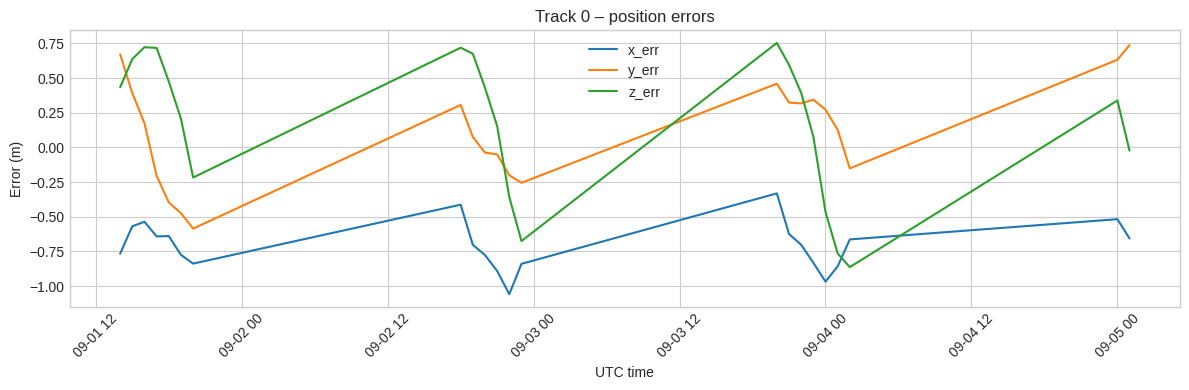

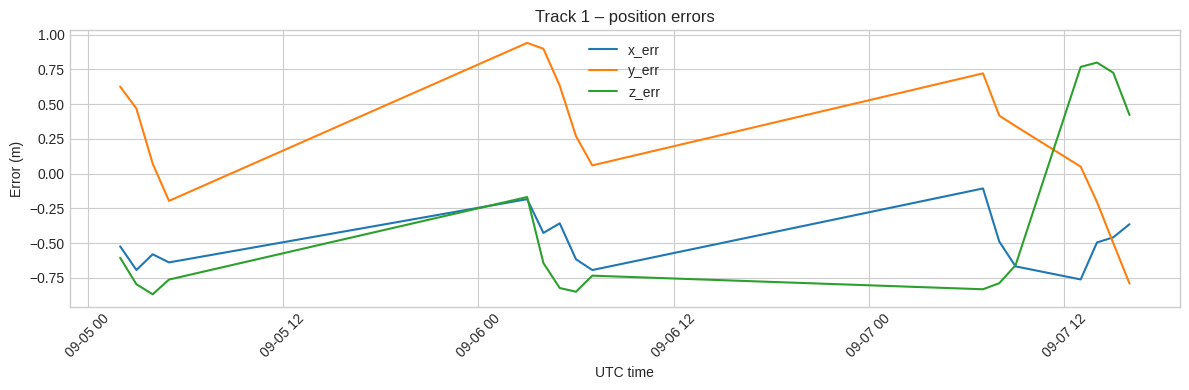

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


# ============================================================
# STEP 1: LOAD, CLEAN, BASIC FEATURES
# ============================================================

def load_meo_data(
    path: str,
    time_col: str = "utc_time",
    dayfirst: bool = False,
) -> pd.DataFrame:
    """
    Load the MEO error dataset, parse UTC time, standardise column names,
    and perform minimal cleaning.

    We keep this step transparent and reversible; nothing here should
    destroy information needed for later scientific analysis.
    """

    df = pd.read_csv("/content/DATA_MEO_Train.csv")

    # 2. Standardise column names used later in the pipeline
    col_map = {
        "x_error (m)": "x_err",
        "y_error  (m)": "y_err",
        "z_error (m)": "z_err",
        "satclockerror (m)": "clk_err",
    }
    df = df.rename(columns=col_map)

    # 3. Parse UTC timestamps; ISRO data is usually precise but we still
    #    allow for parsing errors (coerce -> NaT -> dropped)
    df["dt"] = pd.to_datetime(df[time_col],
                              dayfirst=dayfirst,
                              errors="coerce")

    df = df.dropna(subset=["dt"])

    # 4. Sort chronologically
    df = df.sort_values("dt").reset_index(drop=True)

    # 5. Drop exact duplicates (common when concatenating files)
    df = df.drop_duplicates(
        subset=["dt", "x_err", "y_err", "z_err", "clk_err"],
        keep="first",
    ).reset_index(drop=True)

    # 6. Precompute some basic features that we will use later:
    #    - norm_err: Euclidean magnitude of position error
    df["pos_err_norm"] = np.sqrt(
        df["x_err"]**2 + df["y_err"]**2 + df["z_err"]**2
    )

    print(f"[INFO] Loaded {len(df)} samples from {path}")
    print(df[["dt", "x_err", "y_err", "z_err", "clk_err"]].head())

    return df


# ============================================================
# STEP 1b: ROBUST OUTLIER DETECTION (NOT SATELLITES!)
# ============================================================

def mad_based_outlier_flags(series: pd.Series, z_thresh: float = 3.5) -> pd.Series:
    """
    Robust outlier detection using Median Absolute Deviation (MAD).

    Points with |x - median| / (1.4826 * MAD) > z_thresh are flagged.

    This is more robust than mean/std for heavy-tailed or skewed data,
    which is common in GNSS error processes.
    """
    x = series.values
    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad == 0:
        # All values basically equal; no outliers in this feature
        return pd.Series(False, index=series.index)

    robust_z = np.abs(x - med) / (1.4826 * mad)
    return pd.Series(robust_z > z_thresh, index=series.index)


def flag_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flag potential outliers *before* we attempt to segment into tracks.

    We consider a point suspicious if:
      - its position error magnitude is extreme, OR
      - its one-step jump in error state is extreme.

    We DO NOT call these 'new satellites'; we simply mark them as
    'outlier_candidate' and can choose to exclude them from modelling
    and from track identification.
    """

    # Time difference between consecutive samples
    df["dt_gap_h"] = df["dt"].diff().dt.total_seconds().div(3600.0).fillna(0.0)

    # 3D jump in error state between consecutive epochs
    dx = df["x_err"].diff()
    dy = df["y_err"].diff()
    dz = df["z_err"].diff()
    df["state_jump_m"] = np.sqrt(dx**2 + dy**2 + dz**2).fillna(0.0)

    # Outliers in error magnitude
    flag_mag = mad_based_outlier_flags(df["pos_err_norm"], z_thresh=3.5)
    # Outliers in one-step jump
    flag_jump = mad_based_outlier_flags(df["state_jump_m"], z_thresh=3.5)

    # Combine – “candidate outlier” if either magnitude OR jump is extreme
    df["outlier_candidate"] = flag_mag | flag_jump

    print(f"[INFO] Flagged {df['outlier_candidate'].sum()} / {len(df)} "
          f"samples as candidate outliers (before track segmentation).")

    return df


# ============================================================
# STEP 2: TRACK SEGMENTATION (CANDIDATE SATELLITES)
# ============================================================

def segment_tracks(
    df: pd.DataFrame,
    max_gap_hours: float = 3.0,
    max_jump_zscore: float = 3.0,
    min_track_len: int = 5,
) -> pd.DataFrame:
    """
    Segment the NON-OUTLIER samples into smooth, time-continuous tracks.

    Key idea:
    ---------
    - We define a 'track' as a sequence of points where:
        (1) time gaps are reasonably small,
        (2) error dynamics (jumps) are not extreme.

    - We do NOT automatically treat single noisy points as satellites.
      Short segments (len < min_track_len) are labelled as 'noise',
      not as meaningful tracks.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame already containing:
          - dt
          - dt_gap_h
          - state_jump_m
          - outlier_candidate
    max_gap_hours : float
        Max allowed gap within a track.
    max_jump_zscore : float
        Threshold on z-score of state_jump_m (computed robustly).
    min_track_len : int
        Minimum number of points for a segment to be considered
        a valid track.

    Returns
    -------
    df : pd.DataFrame
        DataFrame with:
          - 'track_raw_id' : initial segmentation ID
          - 'track_id'     : final track ID or -1 for noise/outliers
    """

    # Work on a copy to keep logic clear
    df = df.copy()

    # We'll segment only on *non-outlier* samples
    valid = ~df["outlier_candidate"]
    df_valid = df[valid].copy()

    # --- Compute robust z-scores for state jumps among valid points ---
    jump_series = df_valid["state_jump_m"]
    jump_med = jump_series.median()
    jump_mad = np.median(np.abs(jump_series - jump_med))
    if jump_mad == 0:
        jump_z = (jump_series - jump_med) * 0.0  # all zeros
    else:
        jump_z = np.abs(jump_series - jump_med) / (1.4826 * jump_mad)

    df_valid["jump_z"] = jump_z

    # --- Conditions to start a new raw track ---
    cond_time = df_valid["dt_gap_h"] > max_gap_hours
    cond_jump = df_valid["jump_z"] > max_jump_zscore

    new_seg_flag = (cond_time | cond_jump)

    df_valid["track_raw_id"] = new_seg_flag.cumsum()

    # --- Filter very short segments as noise ---
    track_lengths = df_valid["track_raw_id"].value_counts()

    # map raw_id -> final track_id; short segments get -1 (noise)
    raw_to_final = {}
    tid_counter = 0
    for raw_id, length in track_lengths.items():
        if length >= min_track_len:
            raw_to_final[raw_id] = tid_counter
            tid_counter += 1
        else:
            raw_to_final[raw_id] = -1  # noise

    df_valid["track_id"] = df_valid["track_raw_id"].map(raw_to_final)

    # --- Merge back into original df ---
    df["track_raw_id"] = np.nan
    df["track_id"] = -1  # default: noise or outlier

    df.loc[df_valid.index, "track_raw_id"] = df_valid["track_raw_id"]
    df.loc[df_valid.index, "track_id"] = df_valid["track_id"]

    # Already flagged outliers keep track_id = -1 (not assigned to tracks)
    print(f"[INFO] Identified {len([t for t in raw_to_final.values() if t >= 0])} "
          f"valid tracks with length >= {min_track_len}.")

    return df


# ============================================================
# VISUAL CHECK FOR A TRACK
# ============================================================

def plot_track(df: pd.DataFrame, track_id: int, figsize=(12, 4)):
    """
    Quick visual diagnostic for a single track_id.
    """

    seg = df[df["track_id"] == track_id].copy()
    if seg.empty:
        print(f"[WARN] No samples for track_id={track_id}")
        return

    seg = seg.sort_values("dt")

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg["dt"], seg["x_err"], label="x_err")
    ax.plot(seg["dt"], seg["y_err"], label="y_err")
    ax.plot(seg["dt"], seg["z_err"], label="z_err")
    ax.set_title(f"Track {track_id} – position errors")
    ax.set_xlabel("UTC time")
    ax.set_ylabel("Error (m)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ============================================================
# FULL STEP 1 + STEP 2 PIPELINE
# ============================================================

if __name__ == "__main__":
    path = "MEO_data.xlsx"   # update to your actual path

    # Step 1: load + basic features
    df = load_meo_data(path, time_col="utc_time", dayfirst=False)

    # Step 1b: flag outliers (candidates, not satellites)
    df = flag_outliers(df)

    # Step 2: segment into coherent tracks, treating short segments as noise
    df = segment_tracks(
        df,
        max_gap_hours=3.0,    # can tune with domain knowledge
        max_jump_zscore=3.0,  # robust z-score threshold
        min_track_len=5       # ignore tiny segments
    )

    print(df[["dt", "x_err", "y_err", "z_err",
              "pos_err_norm", "dt_gap_h",
              "state_jump_m", "outlier_candidate",
              "track_id"]].head(25))

    # Optional: visualise first few tracks
    for tid in sorted(df["track_id"].unique()):
        if tid >= 0:
            plot_track(df, track_id=tid)


In [ ]:
# ============================================================
#  MEO GNSS ERROR MODELLING PIPELINE (ONE CELL)
#  ------------------------------------------------------------
#  - Load & clean data
#  - Robust outlier flagging (MAD-based)
#  - Track segmentation (coherent satellite track)
#  - Hourly resampling for a chosen track
#  - STL detrending (trend + daily seasonality)
#  - Optional Fourier-based periodic modelling
#  - Kalman smoothing on residuals
#  - Day-8 forecast
#  - Gaussianity checks (Shapiro–Wilk, histogram, Q–Q plot)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.structural import UnobservedComponents
from scipy.stats import shapiro, probplot

plt.style.use("seaborn-v0_8-whitegrid")


# ---------------------------
# LOADING & BASIC CLEANING
# ---------------------------
def load_meo_data(path: str,
                  time_col: str = "utc_time",
                  dayfirst: bool = False) -> pd.DataFrame:
    """Load MEO GNSS error file, parse time, standardise column names."""

    df = pd.read_csv("/content/DATA_MEO_Train.csv")

    # Normalise column names
    col_map = {
        "x_error (m)": "x_err",
        "y_error  (m)": "y_err",
        "z_error (m)": "z_err",
        "satclockerror (m)": "clk_err",
    }
    df = df.rename(columns=col_map)

    # Parse UTC time
    df["dt"] = pd.to_datetime(df[time_col],
                              dayfirst=dayfirst,
                              errors="coerce")
    df = df.dropna(subset=["dt"])
    df = df.sort_values("dt").reset_index(drop=True)

    # Drop perfect duplicates
    df = df.drop_duplicates(
        subset=["dt", "x_err", "y_err", "z_err", "clk_err"],
        keep="first"
    ).reset_index(drop=True)

    # Position error magnitude
    df["pos_err_norm"] = np.sqrt(
        df["x_err"]**2 + df["y_err"]**2 + df["z_err"]**2
    )

    print(f"[INFO] Loaded {len(df)} samples from {path}")
    return df


# ---------------------------
# OUTLIER FLAGGING (MAD)
# ---------------------------
def mad_based_outlier_flags(series: pd.Series,
                            z_thresh: float = 3.5) -> pd.Series:
    """Median Absolute Deviation based outlier flags."""
    x = series.values
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return pd.Series(False, index=series.index)
    robust_z = np.abs(x - med) / (1.4826 * mad)
    return pd.Series(robust_z > z_thresh, index=series.index)


def flag_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Flag candidate outliers in magnitude and one-step jump."""
    df = df.copy()

    # Time gaps (hours)
    df["dt_gap_h"] = df["dt"].diff().dt.total_seconds().div(3600.0).fillna(0.0)

    # State jump in 3D error space
    dx = df["x_err"].diff()
    dy = df["y_err"].diff()
    dz = df["z_err"].diff()
    df["state_jump_m"] = np.sqrt(dx**2 + dy**2 + dz**2).fillna(0.0)

    flag_mag = mad_based_outlier_flags(df["pos_err_norm"], z_thresh=3.5)
    flag_jump = mad_based_outlier_flags(df["state_jump_m"], z_thresh=3.5)

    df["outlier_candidate"] = flag_mag | flag_jump

    print(f"[INFO] Flagged {df['outlier_candidate'].sum()} / {len(df)} "
          f"samples as candidate outliers.")
    return df


# ---------------------------
# TRACK SEGMENTATION
# ---------------------------
def segment_tracks(df: pd.DataFrame,
                   max_gap_hours: float = 3.0,
                   max_jump_zscore: float = 3.0,
                   min_track_len: int = 5) -> pd.DataFrame:
    """
    Segment non-outlier samples into coherent tracks.
    Very short segments are treated as noise (track_id = -1).
    """
    df = df.copy()
    valid = ~df["outlier_candidate"]
    df_valid = df[valid].copy()

    # Robust z-score for state jumps
    jump = df_valid["state_jump_m"]
    med = jump.median()
    mad = np.median(np.abs(jump - med))
    if mad == 0:
        jump_z = (jump - med) * 0.0
    else:
        jump_z = np.abs(jump - med) / (1.4826 * mad)
    df_valid["jump_z"] = jump_z

    cond_time = df_valid["dt_gap_h"] > max_gap_hours
    cond_jump = df_valid["jump_z"] > max_jump_zscore
    new_seg_flag = cond_time | cond_jump

    df_valid["track_raw_id"] = new_seg_flag.cumsum()

    # Map raw segments to final tracks (short segments -> noise)
    lengths = df_valid["track_raw_id"].value_counts()
    raw_to_final = {}
    tid = 0
    for raw_id, length in lengths.items():
        if length >= min_track_len:
            raw_to_final[raw_id] = tid
            tid += 1
        else:
            raw_to_final[raw_id] = -1

    df_valid["track_id"] = df_valid["track_raw_id"].map(raw_to_final)

    df["track_raw_id"] = np.nan
    df["track_id"] = -1
    df.loc[df_valid.index, "track_raw_id"] = df_valid["track_raw_id"]
    df.loc[df_valid.index, "track_id"] = df_valid["track_id"]

    n_tracks = len([v for v in raw_to_final.values() if v >= 0])
    print(f"[INFO] Identified {n_tracks} valid tracks (len >= {min_track_len}).")
    return df


# ---------------------------
# HOURLY SERIES FOR ONE TRACK
# ---------------------------
def get_hourly_series_for_track(df: pd.DataFrame,
                                track_id: int,
                                col: str = "x_err") -> pd.Series:
    """Extract one track and resample to hourly grid with time interpolation."""
    track = df[df["track_id"] == track_id].copy()
    if track.empty:
        raise ValueError(f"No data for track_id={track_id}")
    track = track.sort_values("dt").set_index("dt")
    series = track[col].asfreq("1H")      # strict hourly grid
    series = series.interpolate("time")   # fill internal gaps
    return series


# ---------------------------
# STL DETRENDING
# ---------------------------
def stl_detrend(series: pd.Series, period: int = 24):
    """Return trend, seasonal and residual components via STL."""
    stl = STL(series, period=period, robust=True)
    res = stl.fit()
    return res.trend, res.seasonal, res.resid, res


# ---------------------------
# FOURIER-BASED PERIODIC MODEL
# ---------------------------
def fourier_design_matrix(n: int, num_harmonics: int = 3, period: int = 24):
    """Design matrix for Fourier series."""
    t = np.arange(n)
    cols = [np.ones(n)]
    for k in range(1, num_harmonics + 1):
        cols.append(np.sin(2 * np.pi * k * t / period))
        cols.append(np.cos(2 * np.pi * k * t / period))
    return np.column_stack(cols)


def fit_fourier_model(series: pd.Series,
                      num_harmonics: int = 3,
                      period: int = 24):
    """Fit Fourier series to series and return periodic component + residual."""
    y = series.values
    X = fourier_design_matrix(len(y), num_harmonics=num_harmonics, period=period)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    fitted = pd.Series(y_hat, index=series.index)
    resid = series - fitted
    return fitted, resid, beta


# ---------------------------
# KALMAN SMOOTHING ON RESIDUALS
# ---------------------------
def kalman_smooth_residual(resid_series: pd.Series):
    """Apply local-level state-space model to residuals (Kalman filter/smoother)."""
    model = UnobservedComponents(resid_series, level="local level")
    res = model.fit(disp=False)
    smoothed = res.level_smoothed
    fitted = res.fittedvalues
    return res, smoothed, fitted


# ---------------------------
# DAY-8 FORECAST
# ---------------------------
def forecast_day8(series: pd.Series,
                  trend: pd.Series,
                  seasonal: pd.Series,
                  kf_res,
                  period: int = 24,
                  steps: int = 24):
    """
    Forecast 'steps' future hourly points (e.g. next 24 hours).
    Combines:
      - linear trend extrapolation,
      - seasonal repetition,
      - residual forecast from Kalman model.
    """
    last_index = series.index[-1]
    future_index = pd.date_range(last_index + pd.Timedelta(hours=1),
                                 periods=steps, freq="1H")

    # Seasonal repetition
    last_season = seasonal.iloc[-period:]
    future_season = (pd.concat([last_season] * ((steps // period) + 1))
                     .iloc[:steps].reset_index(drop=True))
    future_season.index = future_index

    # Linear trend extrapolation using last N points
    N = min(48, len(trend))
    t = np.arange(N)
    y_tr = trend.iloc[-N:].values
    a, b = np.polyfit(t, y_tr, deg=1)
    t_future = np.arange(N, N + steps)
    tr_future_vals = a * t_future + b
    future_trend = pd.Series(tr_future_vals, index=future_index)

    # Residual forecast via Kalman model
    resid_forecast = kf_res.forecast(steps=steps)
    resid_forecast.index = future_index

    # Combine
    future_pred = future_trend + future_season + resid_forecast
    return future_index, future_pred, future_trend, future_season, resid_forecast


# ---------------------------
# GAUSSIANITY CHECKS
# ---------------------------
def gaussianity_diagnostics(residuals: pd.Series, title_suffix=""):
    """Run Shapiro–Wilk test + histogram + Q–Q plot."""
    residuals = residuals.dropna()
    stat, p = shapiro(residuals)
    print(f"[GAUSS{title_suffix}] Shapiro-Wilk stat={stat:.4f}, p={p:.4f}")
    if p > 0.05:
        print("  -> Residuals are consistent with Normal (fail to reject H0 at 5%).")
    else:
        print("  -> Residuals deviate from Normal (reject H0 at 5%).")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(residuals, bins=15, density=True, alpha=0.7, edgecolor="k")
    axes[0].set_title(f"Residuals Histogram {title_suffix}")
    axes[0].set_xlabel("Residual")
    axes[0].set_ylabel("Density")

    probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title(f"Q–Q Plot {title_suffix}")
    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN DEMO PIPELINE (RUN THIS PART)
# ============================================================
if __name__ == "__main__":
    # ---- 1. Load data ----
    path = "MEO_data.xlsx"   # <-- change to your actual path
    df = load_meo_data(path, time_col="utc_time", dayfirst=False)

    # ---- 2. Outlier flagging + track segmentation ----
    df = flag_outliers(df)
    df = segment_tracks(df,
                        max_gap_hours=3.0,
                        max_jump_zscore=3.0,
                        min_track_len=5)

    # choose a valid track (e.g., 0)
    track_id = 0
    x_series = get_hourly_series_for_track(df, track_id=track_id, col="x_err")

    # ---- 3. STL detrending ----
    trend_x, seasonal_x, resid_x, stl_res_x = stl_detrend(x_series, period=24)

    # (optional) Fourier periodic model for comparison
    x_fourier_periodic, x_fourier_resid, beta_fourier = fit_fourier_model(
        x_series, num_harmonics=3, period=24
    )

    # ---- 4. Kalman smoothing on STL residual ----
    kf_res_x, smoothed_x, fitted_resid_x = kalman_smooth_residual(resid_x)

    # ---- 5. Forecast day-8 (next 24 hours) ----
    future_idx_x, x_pred_day8, x_trend_future, x_season_future, x_resid_future = forecast_day8(
        x_series, trend_x, seasonal_x, kf_res_x, period=24, steps=24
    )

    # Visual: last 3 days + forecast
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x_series.iloc[-72:], label="Observed x_err (last 3 days)")
    ax.plot(x_pred_day8, "--o", label="Forecast x_err (day 8)")
    ax.set_title(f"Day-8 forecast for x_err (track {track_id})")
    ax.set_xlabel("UTC time")
    ax.set_ylabel("Error (m)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ---- 6. Residuals and Gaussianity ----
    # model residuals on training period (STL residual minus fitted Kalman component)
    residuals_train_x = resid_x - fitted_resid_x
    gaussianity_diagnostics(residuals_train_x, title_suffix=" (training x_err)")


[INFO] Loaded 46 samples from MEO_data.xlsx
[INFO] Flagged 8 / 46 samples as candidate outliers.
[INFO] Identified 2 valid tracks (len >= 5).


/tmp/ipython-input-948154190.py:170: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  series = track[col].asfreq("1H")      # strict hourly grid
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


AttributeError: 'UnobservedComponentsResults' object has no attribute 'level_smoothed'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FastICA

def decorrelate_xy_best(
    df: pd.DataFrame,
    x_col: str = "x_error_gauss",
    y_col: str = "y_error_gauss",
    prefix: str = "decorr"
) -> pd.DataFrame:
    """
    Remove / minimise correlation between x and y error using the best method
    among:
        - radial / angular factorisation
        - PCA-like 45° rotation (composite error model)
        - standard PCA
        - Independent Component Analysis (ICA)

    The 'best' method is the one that gives the smallest absolute off-diagonal
    correlation between the two transformed components.

    The function:
      - computes all transforms,
      - picks the best,
      - adds two new columns to df,
      - prints the chosen method and its 2x2 correlation matrix.

    Returns
    -------
    df : pd.DataFrame
        Original df with two added columns:
          f"{prefix}_c1" and f"{prefix}_c2"
    """
    x = df[x_col].astype(float).values
    y = df[y_col].astype(float).values
    XY = np.column_stack([x, y])

    methods_results = {}

    # 1) Radial / angular
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    RA = np.column_stack([r, theta])
    corr_RA = np.corrcoef(RA, rowvar=False)
    methods_results["radial_angular"] = (RA, corr_RA)

    # 2) Composite 45° rotation
    e1 = (x + y) / np.sqrt(2.0)
    e2 = (x - y) / np.sqrt(2.0)
    CE = np.column_stack([e1, e2])
    corr_CE = np.corrcoef(CE, rowvar=False)
    methods_results["composite_45deg"] = (CE, corr_CE)

    # 3) PCA on centred data
    XY_centered = XY - XY.mean(axis=0)
    cov_xy = np.cov(XY_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov_xy)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    PC = XY_centered @ eigvecs
    corr_PC = np.corrcoef(PC, rowvar=False)
    methods_results["pca"] = (PC, corr_PC)

    # 4) ICA – fixed whiten argument for new sklearn
    try:
        ica = FastICA(
            n_components=2,
            random_state=42,
            whiten="unit-variance",   # <--- FIX HERE
            max_iter=500
        )
        IC = ica.fit_transform(XY_centered)
        corr_IC = np.corrcoef(IC, rowvar=False)
        methods_results["ica"] = (IC, corr_IC)
    except Exception as e:
        print(f"[WARN] ICA failed ({e}); skipping ICA from candidates.")
        methods_results["ica"] = (None, np.array([[np.inf, np.inf],
                                                  [np.inf, np.inf]]))

    # Choose method with smallest |off-diagonal correlation|
    best_method = None
    best_abs_corr = np.inf
    best_data = None
    best_corr_mat = None

    for name, (data, corr) in methods_results.items():
        if data is None:
            continue
        off_diag = corr[0, 1]
        if abs(off_diag) < best_abs_corr:
            best_abs_corr = abs(off_diag)
            best_method = name
            best_data = data
            best_corr_mat = corr

    c1_name = f"{prefix}_c1"
    c2_name = f"{prefix}_c2"
    df[c1_name] = best_data[:, 0]
    df[c2_name] = best_data[:, 1]

    print(f"\n[DECORRELATION] Best method: {best_method}")
    print(f"Off-diagonal correlation: {best_corr_mat[0,1]:.6f}\n")
    print("Correlation matrix of transformed components:")
    print(pd.DataFrame(best_corr_mat,
                       index=[c1_name, c2_name],
                       columns=[c1_name, c2_name]))

    return df


# -------------------------------------------------------------
# Example usage
# -------------------------------------------------------------
if __name__ == "__main__":
    # Example: load your Gaussianized feature file
    path = "/content/Guassianized_MEO_features.csv"
    df = pd.read_csv(path)

    # Decorrelate x/y Gaussianized errors
    df = decorrelate_xy_best(
        df,
        x_col="x_error_gauss",
        y_col="y_error_gauss",
        prefix="xy_decorr"
    )

    # Now df['xy_decorr_c1'], df['xy_decorr_c2'] are the
    # least-correlated combination of x_error_gauss and y_error_gauss.



[DECORRELATION] Best method: radial_angular
Off-diagonal correlation: 0.005491

Correlation matrix of transformed components:
              xy_decorr_c1  xy_decorr_c2
xy_decorr_c1      1.000000      0.005491
xy_decorr_c2      0.005491      1.000000


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [ ]:
import pandas as pd
df.to_excel("MEO_xy_decorrelated.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("MEO_xy_decorrelated.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FastICA

def decorrelate_xy_best(
    df: pd.DataFrame,
    x_col: str = "x_error_gauss",
    y_col: str = "y_error_gauss",
    prefix: str = "decorr"
) -> pd.DataFrame:
    """
    Remove / minimise correlation between x and y error using the best method
    among:
        - radial / angular factorisation
        - PCA-like 45° rotation (composite error model)
        - standard PCA
        - Independent Component Analysis (ICA)

    The 'best' method is the one that gives the smallest absolute off-diagonal
    correlation between the two transformed components.

    The function:
      - computes all transforms,
      - picks the best,
      - adds two new columns to df,
      - prints the chosen method and its 2x2 correlation matrix.

    Additionally, this version also prints the PCA output explicitly.
    """

    x = df[x_col].astype(float).values
    y = df[y_col].astype(float).values
    XY = np.column_stack([x, y])

    methods_results = {}

    # 1) Radial / angular
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    RA = np.column_stack([r, theta])
    corr_RA = np.corrcoef(RA, rowvar=False)
    methods_results["radial_angular"] = (RA, corr_RA)

    # 2) Composite 45° rotation
    e1 = (x + y) / np.sqrt(2.0)
    e2 = (x - y) / np.sqrt(2.0)
    CE = np.column_stack([e1, e2])
    corr_CE = np.corrcoef(CE, rowvar=False)
    methods_results["composite_45deg"] = (CE, corr_CE)

    # 3) PCA on centred data
    XY_centered = XY - XY.mean(axis=0)
    cov_xy = np.cov(XY_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov_xy)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    PC = XY_centered @ eigvecs
    corr_PC = np.corrcoef(PC, rowvar=False)
    methods_results["pca"] = (PC, corr_PC)

    # ---- NEW: print PCA output explicitly ----
    print("\n[PCA OUTPUT]")
    print("Eigenvalues (descending):", eigvals[idx])
    print("Eigenvectors (columns = principal directions):")
    print(eigvecs)
    print("\nPCA components correlation matrix:")
    print(pd.DataFrame(
        corr_PC,
        index=["PC1", "PC2"],
        columns=["PC1", "PC2"]
    ))
    print("\nFirst 5 PCA component rows:")
    print(pd.DataFrame(PC, columns=["PC1", "PC2"]).head())
    # ------------------------------------------

    # 4) ICA – fixed whiten argument for new sklearn
    try:
        ica = FastICA(
            n_components=2,
            random_state=42,
            whiten="unit-variance",   # <--- FIX HERE
            max_iter=500
        )
        IC = ica.fit_transform(XY_centered)
        corr_IC = np.corrcoef(IC, rowvar=False)
        methods_results["ica"] = (IC, corr_IC)
    except Exception as e:
        print(f"[WARN] ICA failed ({e}); skipping ICA from candidates.")
        methods_results["ica"] = (None, np.array([[np.inf, np.inf],
                                                  [np.inf, np.inf]]))

    # Choose method with smallest |off-diagonal correlation|
    best_method = None
    best_abs_corr = np.inf
    best_data = None
    best_corr_mat = None

    for name, (data, corr) in methods_results.items():
        if data is None:
            continue
        off_diag = corr[0, 1]
        if abs(off_diag) < best_abs_corr:
            best_abs_corr = abs(off_diag)
            best_method = name
            best_data = data
            best_corr_mat = corr

    c1_name = f"{prefix}_c1"
    c2_name = f"{prefix}_c2"
    df[c1_name] = best_data[:, 0]
    df[c2_name] = best_data[:, 1]

    print(f"\n[DECORRELATION] Best method: {best_method}")
    print(f"Off-diagonal correlation: {best_corr_mat[0,1]:.6f}\n")
    print("Correlation matrix of transformed components:")
    print(pd.DataFrame(best_corr_mat,
                       index=[c1_name, c2_name],
                       columns=[c1_name, c2_name]))

    return df


# -------------------------------------------------------------
# Example usage
# -------------------------------------------------------------
if __name__ == "__main__":
    path = "/content/Guassianized_MEO_features.csv"
    df = pd.read_csv(path)

    df = decorrelate_xy_best(
        df,
        x_col="x_error_gauss",
        y_col="y_error_gauss",
        prefix="xy_decorr"
    )



[PCA OUTPUT]
Eigenvalues (descending): [1.99861453e+00 7.21644966e-16]
Eigenvectors (columns = principal directions):
[[ 0.70613454 -0.70807769]
 [ 0.70807769  0.70613454]]

PCA components correlation matrix:
          PC1       PC2
PC1  1.000000  0.925221
PC2  0.925221  1.000000

First 5 PCA component rows:
        PC1           PC2
0  0.964312  2.983362e-16
1  0.964312  2.983362e-16
2  0.263354  2.051510e-16
3  0.263354  2.051510e-16
4  0.263354  2.051510e-16

[DECORRELATION] Best method: radial_angular
Off-diagonal correlation: 0.005491

Correlation matrix of transformed components:
              xy_decorr_c1  xy_decorr_c2
xy_decorr_c1      1.000000      0.005491
xy_decorr_c2      0.005491      1.000000


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# 1. FIT PCA-BASED DECORRELATOR (TRAINING PHASE)
# -------------------------------------------------------------
def fit_xy_pca_decorrelator(
    df: pd.DataFrame,
    x_col: str = "x_error_gauss",
    y_col: str = "y_error_gauss",
    pc_prefix: str = "xy_pc"
):
    """
    Fit a 2D PCA to (x, y) and create uncorrelated components.

    Returns:
      - df with added columns f"{pc_prefix}1" and f"{pc_prefix}2"
      - params dict containing mean and eigenvectors for inverse transform
    """

    X = df[[x_col, y_col]].astype(float).values

    # Center the data (very important for PCA)
    mean_xy = X.mean(axis=0)
    Xc = X - mean_xy

    # Covariance and eigen-decomposition
    cov_xy = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov_xy)

    # Sort eigenvalues / eigenvectors in descending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Principal components (uncorrelated by construction)
    PCs = Xc @ eigvecs      # shape (N, 2)
    pc1 = PCs[:, 0]
    pc2 = PCs[:, 1]

    pc1_name = f"{pc_prefix}1"
    pc2_name = f"{pc_prefix}2"
    df[pc1_name] = pc1
    df[pc2_name] = pc2

    # Sanity check: correlation of PCs (should be ~0)
    corr_pc = np.corrcoef(PCs, rowvar=False)
    print("\n[PCA decorrelation]")
    print("Eigenvalues:", eigvals)
    print("Eigenvectors (columns):\n", eigvecs)
    print("\nCorrelation matrix of (PC1, PC2):")
    print(pd.DataFrame(corr_pc,
                       index=[pc1_name, pc2_name],
                       columns=[pc1_name, pc2_name]))

    # Pack parameters needed for inverse transform
    params = {
        "mean_xy": mean_xy,     # shape (2,)
        "eigvecs": eigvecs,     # shape (2,2)
        "eigvals": eigvals,     # not strictly needed, but useful
        "x_col": x_col,
        "y_col": y_col,
        "pc1_name": pc1_name,
        "pc2_name": pc2_name,
    }

    return df, params


# -------------------------------------------------------------
# 2. APPLY DECORRELATOR TO NEW DATA (SAME PARAMS)
# -------------------------------------------------------------
def apply_xy_pca_decorrelator(
    df: pd.DataFrame,
    params: dict
) -> pd.DataFrame:
    """
    Apply previously fitted PCA rotation to a new dataframe
    (e.g. validation/test segment), using stored params.
    """

    x_col = params["x_col"]
    y_col = params["y_col"]
    pc1_name = params["pc1_name"]
    pc2_name = params["pc2_name"]
    mean_xy = params["mean_xy"]
    eigvecs = params["eigvecs"]

    X = df[[x_col, y_col]].astype(float).values
    Xc = X - mean_xy
    PCs = Xc @ eigvecs
    df[pc1_name] = PCs[:, 0]
    df[pc2_name] = PCs[:, 1]
    return df


# -------------------------------------------------------------
# 3. INVERSE TRANSFORM: (PC1, PC2) -> (x, y)
# -------------------------------------------------------------
def inverse_xy_pca(
    df: pd.DataFrame,
    params: dict,
    out_x_col: str = "x_error_recon",
    out_y_col: str = "y_error_recon"
) -> pd.DataFrame:
    """
    Reconstruct original (x, y) from PCA components.

    This lets you model/forecast PC1 & PC2, then bring the
    prediction back to the original coordinate system.
    """

    pc1_name = params["pc1_name"]
    pc2_name = params["pc2_name"]
    mean_xy = params["mean_xy"]
    eigvecs = params["eigvecs"]

    Z = df[[pc1_name, pc2_name]].values  # PC1, PC2
    # Inverse PCA: X = Z * eigvecs^T + mean
    X_rec = Z @ eigvecs.T + mean_xy

    df[out_x_col] = X_rec[:, 0]
    df[out_y_col] = X_rec[:, 1]

    return df


# -------------------------------------------------------------
# 4. EXAMPLE USAGE (GNSS PIPELINE IN COLAB)
# -------------------------------------------------------------
if __name__ == "__main__":
    # Load your Gaussianized MEO feature file
    path = "/content/Guassianized_MEO_features.csv"
    df = pd.read_csv(path)

    # --- TRAINING PHASE: fit decorrelator on training data ---
    # (Here I use the whole df as "training", but in practice you
    #  would fit only on your training segment.)
    df, decor_params = fit_xy_pca_decorrelator(
        df,
        x_col="x_error_gauss",
        y_col="y_error_gauss",
        pc_prefix="xy_pc"
    )

    # At this point, df["xy_pc1"], df["xy_pc2"] are uncorrelated,
    # and you can feed them into your GNSS error model instead of
    # raw x/y.

    # Example: later, after modelling/forecasting xy_pc1, xy_pc2,
    # you can reconstruct x and y:

    # Suppose df_pred has predicted xy_pc1, xy_pc2 columns:
    # df_pred = some_forecast_df_with_pc1_pc2
    # df_pred = inverse_xy_pca(df_pred, decor_params,
    #                          out_x_col="x_error_pred",
    #                          out_y_col="y_error_pred")



[PCA decorrelation]
Eigenvalues: [1.99861453e+00 7.21644966e-16]
Eigenvectors (columns):
 [[ 0.70613454 -0.70807769]
 [ 0.70807769  0.70613454]]

Correlation matrix of (PC1, PC2):
          xy_pc1    xy_pc2
xy_pc1  1.000000  0.972813
xy_pc2  0.972813  1.000000



[Radial–Angular Transform]
Using x_col='x_error_gauss', y_col='y_error_gauss'
Correlation matrix of (r, theta):
              r_err  theta_err
r_err      1.000000   0.005491
theta_err  0.005491   1.000000

[Reconstruction check]
max |x_original - x_rec| = 8.882e-16
max |y_original - y_rec| = 4.441e-16


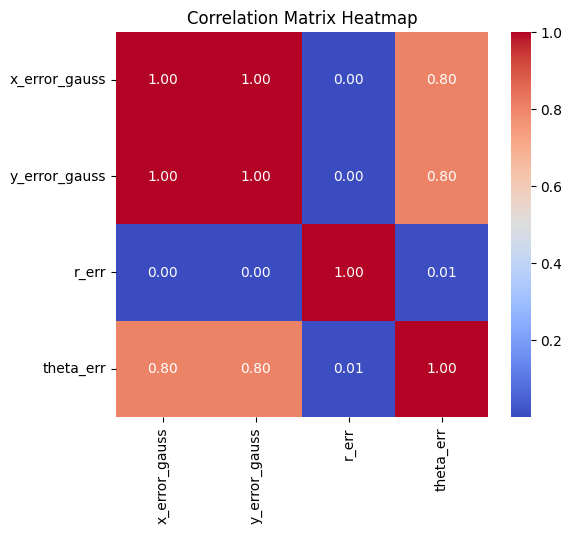

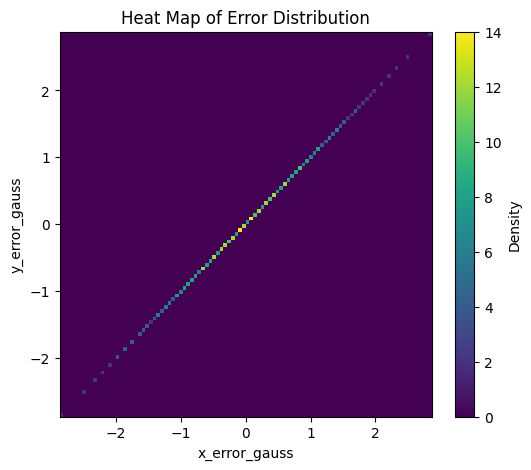

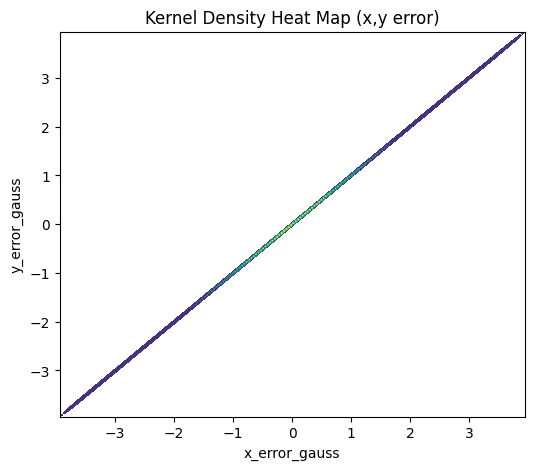

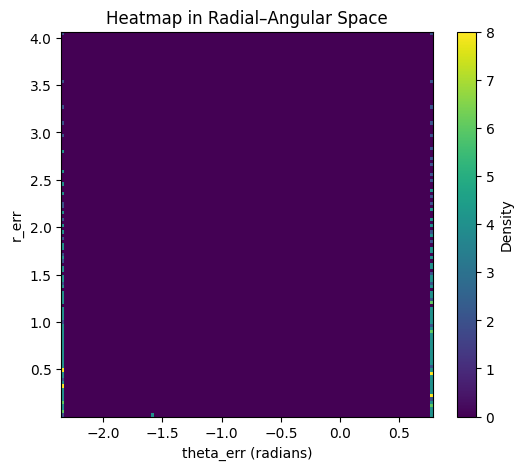

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def to_radial_angular(
    df: pd.DataFrame,
    x_col: str = "x_error_gauss",
    y_col: str = "y_error_gauss",
    r_col: str = "r_err",
    theta_col: str = "theta_err"
) -> pd.DataFrame:

    x = df[x_col].astype(float).values
    y = df[y_col].astype(float).values

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)   # radians

    df[r_col] = r
    df[theta_col] = theta

    corr = np.corrcoef(
        np.column_stack([r, theta]),
        rowvar=False
    )
    print("\n[Radial–Angular Transform]")
    print(f"Using x_col='{x_col}', y_col='{y_col}'")
    print("Correlation matrix of (r, theta):")
    print(pd.DataFrame(
        corr,
        index=[r_col, theta_col],
        columns=[r_col, theta_col]
    ))

    return df

def from_radial_angular(
    df: pd.DataFrame,
    r_col: str = "r_err",
    theta_col: str = "theta_err",
    out_x_col: str = "x_error_rec",
    out_y_col: str = "y_error_rec"
) -> pd.DataFrame:

    r = df[r_col].astype(float).values
    theta = df[theta_col].astype(float).values

    x_rec = r * np.cos(theta)
    y_rec = r * np.sin(theta)

    df[out_x_col] = x_rec
    df[out_y_col] = y_rec

    return df

if __name__ == "__main__":
    path = "/content/Guassianized_MEO_features.csv"
    df = pd.read_csv(path)

    # Original columns
    x_col = "x_error_gauss"
    y_col = "y_error_gauss"

    # Forward transform
    df = to_radial_angular(df, x_col=x_col, y_col=y_col,
                           r_col="r_err", theta_col="theta_err")

    # Inverse transform
    df = from_radial_angular(df,
                             r_col="r_err",
                             theta_col="theta_err",
                             out_x_col="x_error_rec",
                             out_y_col="y_error_rec")

    # Reconstruction check
    max_dx = np.max(np.abs(df[x_col] - df["x_error_rec"]))
    max_dy = np.max(np.abs(df[y_col] - df["y_error_rec"]))

    print("\n[Reconstruction check]")
    print(f"max |x_original - x_rec| = {max_dx:.3e}")
    print(f"max |y_original - y_rec| = {max_dy:.3e}")

    # ==============================
    # 🔥 Correlation Matrix Heatmap
    # ==============================
    corr_matrix = df[["x_error_gauss","y_error_gauss","r_err","theta_err"]].corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix Heatmap")
    plt.show()

    # ==============================
    # Heatmap Plots
    # ==============================

    # Heat map of error distribution
    plt.figure(figsize=(6,5))
    plt.hist2d(df["x_error_gauss"], df["y_error_gauss"], bins=100)
    plt.colorbar(label="Density")
    plt.xlabel("x_error_gauss")
    plt.ylabel("y_error_gauss")
    plt.title("Heat Map of Error Distribution")
    plt.show()

    # KDE Heatmap
    plt.figure(figsize=(6,5))
    sns.kdeplot(
        x=df["x_error_gauss"],
        y=df["y_error_gauss"],
        fill=True,
        cmap="viridis",
        thresh=0
    )
    plt.title("Kernel Density Heat Map (x,y error)")
    plt.show()

    # Radial–Angular Space Heatmap
    plt.figure(figsize=(6,5))
    plt.hist2d(df["theta_err"], df["r_err"], bins=120)
    plt.colorbar(label="Density")
    plt.xlabel("theta_err (radians)")
    plt.ylabel("r_err")
    plt.title("Heatmap in Radial–Angular Space")
    plt.show()


In [ ]:
import pandas as pd
from google.colab import files

df.to_excel("MEO_xy_decorrelated.xlsx", index=False)

files.download("MEO_xy_decorrelated.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[Radial–Angular Transform]
Using x_col='x_error_gauss', y_col='y_error_gauss'
Correlation matrix of (r, theta):
              r_err  theta_err
r_err      1.000000   0.005491
theta_err  0.005491   1.000000


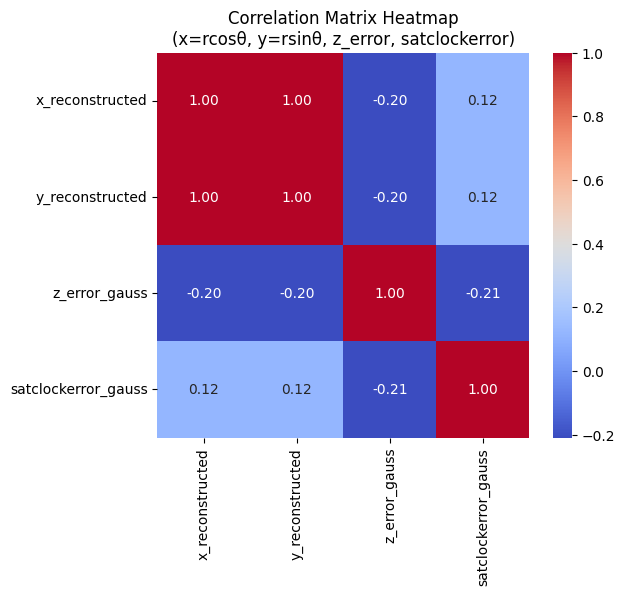

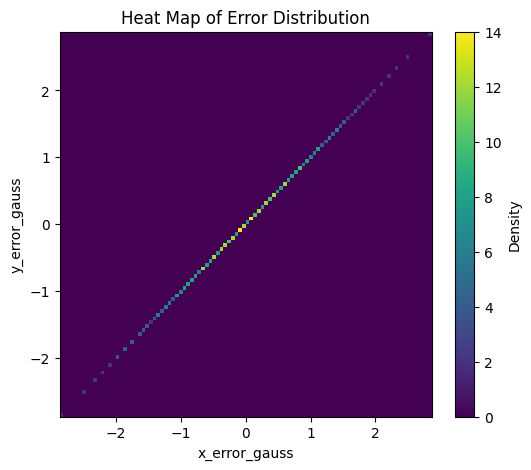

/tmp/ipython-input-137057563.py:98: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


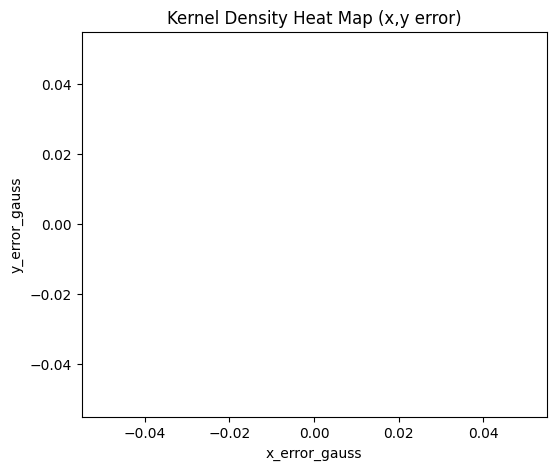

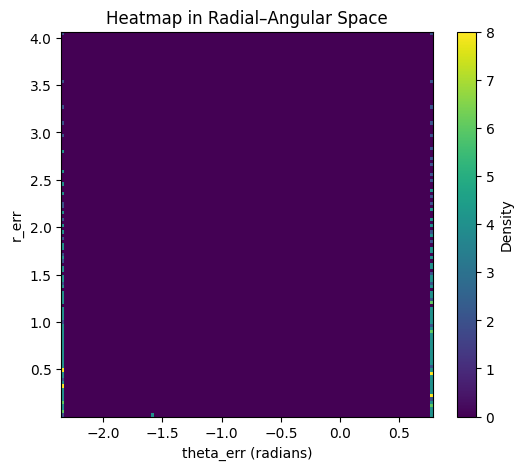

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def to_radial_angular(
    df: pd.DataFrame,
    x_col: str = "x_error_gauss",
    y_col: str = "y_error_gauss",
    r_col: str = "r_err",
    theta_col: str = "theta_err"
) -> pd.DataFrame:

    x = df[x_col].astype(float).values
    y = df[y_col].astype(float).values

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)   # radians

    df[r_col] = r
    df[theta_col] = theta

    corr = np.corrcoef(
        np.column_stack([r, theta]),
        rowvar=False
    )
    print("\n[Radial–Angular Transform]")
    print(f"Using x_col='{x_col}', y_col='{y_col}'")
    print("Correlation matrix of (r, theta):")
    print(pd.DataFrame(
        corr,
        index=[r_col, theta_col],
        columns=[r_col, theta_col]
    ))

    return df

def from_radial_angular(
    df: pd.DataFrame,
    r_col: str = "r_err",
    theta_col: str = "theta_err",
    out_x_col: str = "x_reconstructed",
    out_y_col: str = "y_reconstructed"
) -> pd.DataFrame:

    r = df[r_col].astype(float).values
    theta = df[theta_col].astype(float).values

    x_rec = r * np.cos(theta)
    y_rec = r * np.sin(theta)

    df[out_x_col] = x_rec
    df[out_y_col] = y_rec

    return df

if __name__ == "__main__":
    path = "/content/Guassianized_MEO_features.csv"
    df = pd.read_csv(path)

    x_col = "x_error_gauss"
    y_col = "y_error_gauss"

    # Forward transform
    df = to_radial_angular(df, x_col=x_col, y_col=y_col,
                           r_col="r_err", theta_col="theta_err")

    # Add new columns (x = r cos θ, y = r sin θ)
    df = from_radial_angular(df,
                             r_col="r_err",
                             theta_col="theta_err",
                             out_x_col="x_reconstructed",
                             out_y_col="y_reconstructed")

    # ==============================
    # 🔥 Correlation Matrix Heatmap For 4 Features
    # ==============================
    features = ["x_reconstructed", "y_reconstructed", "z_error_gauss", "satclockerror_gauss"]
    corr_matrix = df[features].corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix Heatmap\n(x=rcosθ, y=rsinθ, z_error, satclockerror)")
    plt.show()

    # ==============================
    # Optional Heatmaps (Keep from before)
    # ==============================
    plt.figure(figsize=(6,5))
    plt.hist2d(df["x_error_gauss"], df["y_error_gauss"], bins=100)
    plt.colorbar(label="Density")
    plt.xlabel("x_error_gauss")
    plt.ylabel("y_error_gauss")
    plt.title("Heat Map of Error Distribution")
    plt.show()

    plt.figure(figsize=(6,5))
    sns.kdeplot(
        x=df["x_error_gauss"],
        y=df["y_error_gauss"],
        fill=True,
        cmap="viridis",
        thresh=0
    )
    plt.title("Kernel Density Heat Map (x,y error)")
    plt.show()

    plt.figure(figsize=(6,5))
    plt.hist2d(df["theta_err"], df["r_err"], bins=120)
    plt.colorbar(label="Density")
    plt.xlabel("theta_err (radians)")
    plt.ylabel("r_err")
    plt.title("Heatmap in Radial–Angular Space")
    plt.show()
